# ĐỒ ÁN MÔN HỌC — NT120: NHẬP MÔN TRÍ TUỆ NHÂN TẠO CHO MẠNG MÁY TÍNH VÀ AN TOÀN THÔNG TIN

## So sánh hiệu quả các mô hình Machine Learning (Decision Tree, Random Forest, XGBoost) trong phát hiện và phân loại tấn công mạng SDN trên bộ dữ liệu InSDN

**Thông tin nhóm**

| Mục | Nội dung |
|---|---|
| Lớp | ... |
| Nhóm số | 03 |
| Giảng viên hướng dẫn | ... |
| Học kỳ | ... |
| Ngày nộp | ... |

**Danh sách thành viên**

| STT | MSSV | Họ và tên | Vai trò / Phần đóng góp chính | Email |
|---|---|---|---|---|
| 1 | 23521404 | Phan Mạnh Tân | Trưởng nhóm; EDA, làm sạch dữ liệu (mục 3–4) | ... |
| 2 | 23521357 | Nguyễn Văn Sơn | Cài đặt, tinh chỉnh Decision Tree & Random Forest (mục 5) | ... |
| 3 | 23521290 | Phạm Minh Quang | Cài đặt XGBoost, đánh giá, kiểm định thống kê & phân tích độ tin cậy (mục 6–7) | ... |

## Hướng dẫn chạy notebook

- **Dữ liệu:** notebook tự tìm thư mục `InSDN_DatasetCSV/` (đặt cạnh notebook, hoặc trong `data/`, hoặc đường dẫn Kaggle). Nếu không tìm thấy, notebook tự tải bộ dữ liệu bằng `kagglehub` (cần kết nối Internet, khoảng 21 MB nén). Không nộp kèm dữ liệu thô.
- **Phiên bản dữ liệu:** bản Kaggle `badcodebuilder/insdn-dataset`, **version 2** (được ghim trong mã nạp dữ liệu). Ô mã mục 3.2 kiểm tra kích thước `(343.889, 85)` và dừng ngay nếu dữ liệu tải về khác bản đã dùng.
- **Thư viện:** `numpy`, `pandas`, `scipy`, `matplotlib`, `seaborn`, `scikit-learn`, `xgboost` (và `kagglehub` nếu cần tự tải dữ liệu). Kết quả in trong notebook được sinh với **pandas 3.0.2, scikit-learn 1.8.0, xgboost 3.2.0** (phiên bản đầy đủ của mọi thư viện được in ở ô mã mục 3.1). Phiên bản khác của scikit-learn/xgboost có thể làm các con số lệch ở chữ số thập phân thứ 3–4 (do thay đổi cài đặt bên trong thuật toán), nên để tái lập đúng từng con số:
  `pip install pandas==3.0.2 scikit-learn==1.8.0 xgboost==3.2.0 numpy scipy matplotlib seaborn kagglehub`
- **Tái lập:** mọi bước ngẫu nhiên dùng `SEED = 42`. Chạy bằng *Kernel → Restart & Run All*. Toàn bộ notebook chạy khoảng 35 phút (đo được 34 phút trên máy 2 nhân CPU, RAM 8 GB, không GPU); phần lớn thời gian nằm ở grid search mục 5.4 (khoảng 20 phút) và kiểm tra độ tin cậy mục 7.2. Các con số về thời gian huấn luyện/suy luận có thể dao động nhẹ giữa các lần chạy và giữa các máy.
- Notebook khám phá dữ liệu chi tiết hơn nằm ở file `eda-insdn-dataset.ipynb` đi kèm; mục 3.3 dưới đây chỉ giữ lại các phân tích ảnh hưởng trực tiếp tới thiết kế thí nghiệm.

## Mục lục

1. Giới thiệu và phát biểu bài toán
2. Khảo sát các giải pháp liên quan
3. Thiết lập môi trường và nạp dữ liệu
4. Tiền xử lý dữ liệu
5. Phương pháp tiếp cận
6. Thực nghiệm và đánh giá kết quả
7. Phân tích và thảo luận
8. Kết luận và hướng phát triển
9. Đóng góp của các thành viên
10. Tài liệu tham khảo
11. Phụ lục
12. Checklist tự đánh giá trước khi nộp
13. Gợi ý chuẩn bị phần trình bày trước lớp

## 1. Giới thiệu và phát biểu bài toán

### 1.1 Bối cảnh và động lực

Mạng định nghĩa bằng phần mềm (Software-Defined Networking — SDN) tách mặt phẳng điều khiển (controller) khỏi mặt phẳng dữ liệu (switch OpenFlow), giúp quản trị mạng linh hoạt và lập trình được. SDN đang được dùng rộng rãi trong trung tâm dữ liệu, mạng 5G và mạng doanh nghiệp. Tuy nhiên, chính kiến trúc tập trung này tạo ra bề mặt tấn công mới: controller là "điểm chết" duy nhất, và các cuộc tấn công DoS/DDoS có thể làm tràn bảng luồng (flow table) của switch hoặc làm quá tải kênh controller–switch. Bên cạnh đó, các tấn công truyền thống (dò quét, brute-force, web attack, botnet, leo thang đặc quyền) vẫn nhắm vào các máy chủ nằm trong mạng SDN.

Controller SDN có sẵn thống kê theo luồng (flow statistics), nên việc gắn thêm một mô-đun phát hiện xâm nhập (IDS) dựa trên học máy lên controller là hướng tiếp cận tự nhiên. Câu hỏi thực tế đặt ra là: *nên chọn mô hình nào* — một cây quyết định đơn giản, dễ giải thích; hay các mô hình tập hợp (ensemble) mạnh hơn nhưng nặng hơn như Random Forest và XGBoost — và sự khác biệt giữa chúng có thực sự đáng kể khi được đánh giá cẩn thận, không bị thổi phồng bởi rò rỉ dữ liệu. Đồ án này trả lời câu hỏi đó trên InSDN [1], một bộ dữ liệu xâm nhập được thu thập trực tiếp trong môi trường SDN.

### 1.2 Phát biểu bài toán

- **Đầu vào:** một bản ghi luồng mạng (network flow) do CICFlowMeter [13] trích xuất, gồm các đặc trưng thống kê về hành vi: thời lượng luồng, số gói và số byte theo hai chiều, độ dài gói (min/max/mean/std), khoảng thời gian giữa các gói (IAT), tốc độ gói/byte, cờ TCP, kích thước cửa sổ TCP ban đầu, thời gian active/idle, và giao thức (TCP/UDP/khác). Các trường định danh (Flow ID, địa chỉ IP, cổng nguồn/đích, Timestamp) **không** được dùng làm đầu vào (lý do ở mục 3.3 và 4.1).
- **Đầu ra:** hai bài toán con trên cùng dữ liệu:
  - **Bài toán A — Phát hiện (detection):** phân loại nhị phân `Normal` / `Attack`.
  - **Bài toán B — Phân loại (classification):** phân loại đa lớp 8 nhãn: `Normal`, `DDoS`, `DoS`, `Probe`, `BFA` (brute-force), `Web-Attack`, `BOTNET`, `U2R`.
- **Dạng bài toán:** học có giám sát, phân loại (classification) trên dữ liệu dạng bảng, nhãn **mất cân bằng nghiêm trọng**.
- **Giả định:**
  - Các luồng là mẫu độc lập, cùng phân phối (i.i.d.) và tập train/test được rút ngẫu nhiên từ cùng một phân phối. Giả định này là cơ sở cho việc ước lượng hiệu năng trên tập test; thí nghiệm (4) ở mục 7.2 cố ý vi phạm nó để đo khả năng tổng quát hóa sang môi trường khác.
  - Mỗi luồng được xét độc lập (không dùng ngữ cảnh chuỗi thời gian giữa các luồng).
  - Nhãn do tác giả bộ dữ liệu gán là đúng.
  - Các đặc trưng luồng có thể được tính tại controller SDN (hoặc một mô-đun thu thập luồng) trước khi đưa vào mô hình.

### 1.3 Mục tiêu cụ thể

1. Cài đặt và so sánh **3 mô hình**: Decision Tree (đường cơ sở), Random Forest và XGBoost, trên **2 bài toán** (nhị phân và 8 lớp), với cùng một quy trình tiền xử lý và cùng một phép chia dữ liệu.
2. Tinh chỉnh siêu tham số cho từng mô hình bằng grid search, tiêu chí là **F1-macro**: chấm điểm trên tập validation (bài toán nhị phân) hoặc bằng 3-fold cross-validation trên train + validation (bài toán 8 lớp). Mô hình cuối được huấn luyện lại trên train + validation.
3. Trên tập test: đạt **F1-macro ≥ 0,99 cho bài toán phát hiện** và **F1-macro ≥ 0,90 cho bài toán 8 lớp** với mô hình tốt nhất; báo cáo thêm Accuracy, Precision/Recall macro, MCC, ROC-AUC, F1 từng lớp và ma trận nhầm lẫn.
4. So sánh **chi phí tính toán**: thời gian huấn luyện và thời gian suy luận trung bình trên mỗi luồng (µs/flow).
5. **Kiểm tra độ tin cậy** của kết quả qua 4 thí nghiệm: overfitting (train/val/test), độ ổn định (5-fold cross-validation), ảnh hưởng của dữ liệu trùng lặp, và khả năng tổng quát hóa sang kịch bản tấn công khác (train trên OVS, test trên Metasploitable-2). Kèm theo là kiểm định thống kê cho các so sánh giữa mô hình.

**Giả thuyết nghiên cứu** (được kiểm định ở mục 7.2 bằng kiểm định McNemar với hiệu chỉnh Holm và khoảng tin cậy bootstrap 95%, mức ý nghĩa $\alpha = 0{,}05$):

| | Giả thuyết | Giả thuyết không $H_0$ | Cách kiểm định |
|---|---|---|---|
| **H1** | Với bài toán phát hiện (nhị phân), cả ba mô hình đạt F1-macro ≥ 0,99 và **không khác nhau có ý nghĩa** | Tỉ lệ lỗi của các mô hình như nhau (H1 được ủng hộ nếu *không bác bỏ* $H_0$ và mọi F1-macro ≥ 0,99) | F1-macro trên test; McNemar từng cặp; **tương đương thực tế** nếu CI bootstrap 95% của mọi $\Delta$F1 nằm trọn trong biên $\pm 0{,}001$ |
| **H2** | Với bài toán 8 lớp trên cùng phân phối, mô hình ensemble (RF, XGBoost) **tốt hơn** Decision Tree | Tỉ lệ lỗi / F1-macro của ensemble và DT như nhau | McNemar trên test; CI bootstrap của $\Delta$F1-macro; 5-fold CV với kiểm định t ghép cặp đã hiệu chỉnh |
| **H3** | Khi triển khai sang môi trường tấn công chưa thấy (OVS → Metasploitable-2), ensemble **tổng quát hóa tốt hơn** Decision Tree | Tỉ lệ lỗi của ensemble và DT như nhau | McNemar trên tập test của thí nghiệm chéo môi trường |

H2 và H3 được đặt ra dựa trên lý thuyết: ensemble giảm phương sai (RF) hoặc độ chệch (XGBoost) so với cây đơn (mục 5.1.1). *Lưu ý:* với H1, việc không bác bỏ $H_0$ tự nó không chứng minh hai mô hình tương đương. Vì vậy chúng tôi đặt trước một **biên tương đương** $\pm 0{,}001$ F1-macro (tức khoảng 25 luồng bị phân loại sai trên 27.679 luồng test — mỗi luồng sai làm F1-macro nhị phân giảm khoảng $4 \cdot 10^{-5}$ — không đáng kể về vận hành): H1 chỉ được ủng hộ khi CI bootstrap của mọi $\Delta$F1 nằm trọn trong biên này. Về hình thức, đây là kiểm định tương đương TOST [15]: tương đương ở mức $\alpha = 0{,}05$ khi CI 90% nằm trọn trong $(-\delta, +\delta)$; chúng tôi yêu cầu điều kiện chặt hơn là cả CI 95% nằm trong biên. Biên $\delta$ được chọn sao cho (i) lớn hơn nhiều độ phân giải của tập test (1 luồng ≈ $4 \cdot 10^{-5}$), để kiểm định không đòi hỏi hai mô hình giống nhau đến từng luồng; và (ii) nhỏ hơn rất nhiều khoảng cách giữa mô hình học máy và đường cơ sở (F1-macro của `Dummy` ≈ 0,40, mục 6.4), để "tương đương" vẫn mang nghĩa thực tế.

### 1.4 Phạm vi và giới hạn

- Chỉ thử nghiệm trên **một bộ dữ liệu** (InSDN), được thu thập trong một phòng lab mô phỏng (Mininet + ONOS, máy ảo tấn công/nạn nhân); chưa kiểm chứng trên lưu lượng SDN thực tế.
- Chỉ so sánh **3 mô hình dựa trên cây**; không so sánh với mạng nơ-ron hay các phương pháp phát hiện bất thường không giám sát.
- **Không triển khai thời gian thực** trên controller SDN; thời gian suy luận chỉ được đo offline theo lô (batch) trên CPU.
- Bài toán xét từng luồng độc lập, sau khi luồng đã kết thúc và được CICFlowMeter tổng hợp.
- Các lớp rất hiếm (`U2R` chỉ có 17 mẫu) khiến kết quả của những lớp này có độ bất định cao; chúng tôi báo cáo nhưng không rút ra kết luận mạnh từ các lớp đó.

## 2. Khảo sát các giải pháp liên quan

**[1] Elsayed, Le-Khac, Jurcut — "InSDN: A Novel SDN Intrusion Dataset" (IEEE Access, 2020).**
(1) Vấn đề: các bộ dữ liệu IDS phổ biến (KDD'99, NSL-KDD, CIC-IDS2017) không được thu thập trong môi trường SDN, nên không phản ánh các tấn công nhắm vào kiến trúc SDN. (2) Hướng tiếp cận: dựng testbed SDN (controller ONOS, switch Open vSwitch, Mininet), tạo lưu lượng bình thường và 7 nhóm tấn công (DoS, DDoS, Probe, BFA, Web-Attack, BOTNET, U2R), trích xuất hơn 80 đặc trưng luồng bằng CICFlowMeter. Sau khi bỏ thông tin socket (IP, cổng), các tác giả đánh giá 8 thuật toán (Decision Tree, Random Forest, AdaBoost, KNN, Naive Bayes, SVM tuyến tính/RBF, MLP) và báo cáo F1-score xấp xỉ 0,999 cho các mô hình tốt nhất. (3) Kế thừa: chúng tôi dùng trực tiếp bộ dữ liệu và nhãn của [1], và cũng loại bỏ các cột định danh. Khác biệt: đồ án bổ sung XGBoost, tinh chỉnh siêu tham số theo F1-macro, **khử trùng lặp** (46% bản ghi là bản sao sau khi bỏ định danh), báo cáo kết quả theo từng lớp hiếm, và thêm **thí nghiệm tổng quát hóa giữa hai môi trường tấn công** (OVS → Metasploitable-2) để kiểm tra kết quả có bị thổi phồng hay không.

**[2] Breiman — "Random Forests" (Machine Learning, 2001) và [3] Chen & Guestrin — "XGBoost: A Scalable Tree Boosting System" (KDD 2016).**
(1) Vấn đề: một cây quyết định đơn lẻ có phương sai cao, dễ overfit. (2) Hướng tiếp cận: Random Forest giảm phương sai bằng cách lấy trung bình nhiều cây huấn luyện trên mẫu bootstrap và tập con đặc trưng ngẫu nhiên (bagging); XGBoost chủ yếu giảm độ chệch (bias) bằng cách xây dựng cây tuần tự, mỗi cây khớp với gradient của hàm mất mát tại dự đoán hiện tại (gradient boosting), dùng xấp xỉ Taylor bậc hai và số hạng chuẩn hóa độ phức tạp của cây. (3) Kế thừa: đây là hai đại diện tiêu biểu cho hai họ ensemble (bagging và boosting), rất mạnh trên dữ liệu dạng bảng như đặc trưng luồng mạng, nên được chọn để so sánh với cây quyết định đơn.

**[4] Engelen, Rimmer, Joosen — "Troubleshooting an Intrusion Detection Dataset: the CICIDS2017 Case Study" (IEEE SPW, 2021) và [5] Arp và cộng sự — "Dos and Don'ts of Machine Learning in Computer Security" (USENIX Security, 2022).**
(1) Vấn đề: nhiều công trình IDS báo cáo độ chính xác gần 100% nhưng kết quả không đáng tin do lỗi dữ liệu và sai lầm phương pháp. (2) Hướng tiếp cận: [4] phân tích các lỗi của công cụ CICFlowMeter và quy trình gán nhãn (luồng bị cắt, trùng lặp, gán nhãn sai); [5] hệ thống hóa các "cạm bẫy" như rò rỉ dữ liệu, đặc trưng giả (spurious correlation — ví dụ IP/port gắn chặt với nhãn trong lab), đánh giá thiếu thực tế. (3) Kế thừa: InSDN cũng được trích xuất bằng CICFlowMeter, nên chúng tôi áp dụng các khuyến nghị này: loại bỏ định danh, khử trùng lặp, dùng độ đo phù hợp với mất cân bằng, và thêm thí nghiệm tổng quát hóa giữa các kịch bản.

## 3. Thiết lập môi trường và nạp dữ liệu

### 3.1 Cài đặt và nạp thư viện

Dùng `pandas`/`numpy` cho xử lý dữ liệu, `matplotlib`/`seaborn` cho trực quan hóa, `scikit-learn` [7] cho Decision Tree, Random Forest, chia dữ liệu và độ đo, `xgboost` [3] cho XGBoost, và `scipy` cho kiểm định thống kê. Seed cố định `SEED = 42` được truyền vào mọi bước ngẫu nhiên (chia tập, bootstrap của Random Forest, lấy mẫu con của XGBoost, cross-validation).

In [1]:
# Thư viện xử lý dữ liệu và tính toán
import os
import time
import platform
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

# Thư viện trực quan hóa
import matplotlib.pyplot as plt
import seaborn as sns

# Thư viện học máy
import sklearn
import xgboost
from sklearn.model_selection import train_test_split, ParameterGrid, StratifiedKFold
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    matthews_corrcoef, roc_auc_score, classification_report, confusion_matrix,
)

# Kiểm định thống kê (mục 7.2)
from itertools import combinations
import scipy
from scipy.stats import binomtest, chi2, t as t_dist

# Chỉ ẩn các cảnh báo đã biết là vô hại (không tắt toàn bộ cảnh báo)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", message=".*Falling back to prediction using DMatrix.*")
warnings.filterwarnings("ignore", message=".*IProgress not found.*")   # cảnh báo thanh tiến trình của kagglehub
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
sns.set_theme(style="whitegrid", context="notebook")

# Cố định seed để kết quả có thể tái lập
SEED = 42
np.random.seed(SEED)
N_JOBS = -1          # dùng toàn bộ CPU cho RF/XGBoost

# Biên tương đương cho H1, đặt TRƯỚC khi xem kết quả test (mục 1.3): |ΔF1-macro| < 0,001
EQ_MARGIN = 0.001

MODEL_NAMES = ["Decision Tree", "Random Forest", "XGBoost"]
MODEL_COLORS = {"Decision Tree": "#8E9AAF", "Random Forest": "#2A9D8F", "XGBoost": "#E76F51"}

print("Python      :", platform.python_version())
print("numpy       :", np.__version__)
print("pandas      :", pd.__version__)
print("scipy       :", scipy.__version__)
print("matplotlib  :", plt.matplotlib.__version__)
print("seaborn     :", sns.__version__)
print("scikit-learn:", sklearn.__version__)
print("xgboost     :", xgboost.__version__)
print("SEED        :", SEED)
print("CPU (nhân)  :", os.cpu_count())
try:
    ram_gb = os.sysconf("SC_PAGE_SIZE") * os.sysconf("SC_PHYS_PAGES") / 1024**3
    print(f"RAM         : {ram_gb:.1f} GB")
except (ValueError, AttributeError, OSError):
    print("RAM         : không đọc được trên hệ điều hành này")


Python      : 3.13.16
numpy       : 2.5.3
pandas      : 3.0.2
scipy       : 1.18.1
matplotlib  : 3.11.2
seaborn     : 0.13.2
scikit-learn: 1.8.0
xgboost     : 3.2.0
SEED        : 42
CPU (nhân)  : 2
RAM         : 7.8 GB


### 3.2 Nguồn dữ liệu

- **Tên bộ dữ liệu:** InSDN — SDN Intrusion Dataset [1], University College Dublin (Ireland).
- **Nguồn tải:** trang chính thức của tác giả (http://aseados.ucd.ie/datasets/SDN/) hoặc bản sao trên Kaggle `badcodebuilder/insdn-dataset` [6] (bản được dùng trong notebook).
- **Cách tạo** [1]: testbed SDN gồm controller ONOS, switch Open vSwitch và các host ảo trong Mininet; máy tấn công Kali Linux; nạn nhân là máy chủ Metasploitable-2 và web server DVWA. Lưu lượng bình thường gồm HTTP(S), DNS, SSH, FTP, email, Telnet, video/mạng xã hội... Lưu lượng tấn công được tạo bằng: hping3 (DDoS); LOIC, HULK, slowhttptest, Tor's Hammer, Nping (DoS); Nmap (Probe); Hydra, Burp Suite (BFA); sqlmap (Web-Attack); ARES (BOTNET); Metasploit (U2R và một số tấn công khác). Gói tin được bắt và chuyển thành bản ghi luồng bằng CICFlowMeter [13].
- **Cấu trúc:** 3 file CSV — `Normal_data.csv` (chỉ lưu lượng bình thường), `OVS.csv` (tấn công nhắm vào máy trong mạng Open vSwitch), `metasploitable-2.csv` (tấn công nhắm vào máy Metasploitable-2). Tổng cộng **343.889 luồng × 84 cột** (83 cột đặc trưng/định danh + `Label`); notebook thêm cột phụ `__source_file` để truy vết file nguồn (không dùng làm đặc trưng).
- **Cấp phép:** bộ dữ liệu công khai cho mục đích nghiên cứu; khi sử dụng cần trích dẫn bài báo [1].

In [2]:
# Tìm thư mục dữ liệu: ưu tiên bản có sẵn trên máy / Kaggle, nếu không có thì tự tải bằng kagglehub
CANDIDATE_DIRS = [
    Path("InSDN_DatasetCSV"),
    Path("data/InSDN_DatasetCSV"),
    Path("/kaggle/input/insdn-dataset/InSDN_DatasetCSV"),
    Path("/kaggle/input/datasets/badcodebuilder/insdn-dataset/InSDN_DatasetCSV"),
]
DATA_DIR = next((p for p in CANDIDATE_DIRS if p.exists()), None)
if DATA_DIR is None:
    import kagglehub  # pip install kagglehub
    DATA_DIR = Path(kagglehub.dataset_download("badcodebuilder/insdn-dataset/versions/2")) / "InSDN_DatasetCSV"

csv_files = sorted(DATA_DIR.glob("*.csv"))
print("DATA_DIR:", DATA_DIR)
print([f.name for f in csv_files])

frames = []
for file in csv_files:
    part = pd.read_csv(file, low_memory=False)
    part.columns = part.columns.str.strip().str.replace(r"\s+", " ", regex=True)
    part["__source_file"] = file.name
    frames.append(part)

df_raw = pd.concat(frames, ignore_index=True, sort=False)
print("Kích thước dữ liệu gốc:", df_raw.shape)
# Dừng sớm nếu dữ liệu khác bản đã dùng trong báo cáo (3 file, 343.889 luồng, 84 cột + __source_file)
assert len(csv_files) == 3 and df_raw.shape == (343889, 85), "Dữ liệu khác phiên bản InSDN đã dùng"

df_raw.head()

DATA_DIR: /root/.cache/kagglehub/datasets/badcodebuilder/insdn-dataset/versions/2/InSDN_DatasetCSV
['Normal_data.csv', 'OVS.csv', 'metasploitable-2.csv']


Kích thước dữ liệu gốc: (343889, 85)


,Flow ID,Src IP,Src Port,Dst IP,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,Fwd Pkt Len Mean,Fwd Pkt Len Std,Bwd Pkt Len Max,Bwd Pkt Len Min,Bwd Pkt Len Mean,Bwd Pkt Len Std,Flow Byts/s,Flow Pkts/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Tot,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Tot,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Len,Bwd Header Len,Fwd Pkts/s,Bwd Pkts/s,Pkt Len Min,Pkt Len Max,Pkt Len Mean,Pkt Len Std,Pkt Len Var,FIN Flag Cnt,SYN Flag Cnt,RST Flag Cnt,PSH Flag Cnt,ACK Flag Cnt,URG Flag Cnt,CWE Flag Count,ECE Flag Cnt,Down/Up Ratio,Pkt Size Avg,Fwd Seg Size Avg,Bwd Seg Size Avg,Fwd Byts/b Avg,Fwd Pkts/b Avg,Fwd Blk Rate Avg,Bwd Byts/b Avg,Bwd Pkts/b Avg,Bwd Blk Rate Avg,Subflow Fwd Pkts,Subflow Fwd Byts,Subflow Bwd Pkts,Subflow Bwd Byts,Init Fwd Win Byts,Init Bwd Win Byts,Fwd Act Data Pkts,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,__source_file
0,185.127.17.56-192.168.20.133-443-53648-6,185.127.17.56,443,192.168.20.133,53648,6,5/2/2020 13:58,245230,44,40,"124,937.0000","1,071.0000",9100,0,"2,839.4773","1,839.5083",517,0,26.7750,109.1880,"513,835.9907",342.5356,"2,954.5783","7,953.2219","64,066.0000",-44.0000,"238,564.0000","5,548.0000","10,446.2958","64,066.0000",2.0000,"245,230.0000","6,287.9487","12,986.4688","79,070.0000",29.0000,0,0,0,0,880,804,179.4234,163.1122,0,9100,"1,482.4471","1,933.2683","3,737,526.3690",0,1,0,0,1,0,0,0,0,"1,500.0952","2,839.4773",26.7750,0,0,0,0,0,0,44,124937,40,1071,-1,65535,41,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,Normal,Normal_data.csv
1,185.127.17.56-192.168.20.133-443-53650-6,192.168.20.133,53650,185.127.17.56,443,6,5/2/2020 13:58,1605449,107,149,"1,071.0000","439,537.0000",517,0,10.0093,67.4967,27300,0,"2,949.9128","3,012.5895","274,445.3421",159.4569,"6,295.8784","56,408.3305","859,760.0000",-102.0000,"1,332,121.0000","12,567.1792","83,434.1416","861,138.0000",2.0000,"1,603,130.0000","10,831.9595","73,926.6524","861,129.0000",1.0000,0,0,0,0,2140,3004,66.6480,92.8089,0,27300,"1,714.4280","2,713.4659","7,362,897.2850",0,1,0,0,0,0,0,0,1,"1,721.1250",10.0093,"2,949.9128",0,0,0,0,0,0,107,1071,149,439537,-1,64240,4,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,Normal,Normal_data.csv
2,192.168.20.133-192.168.20.2-35108-53-6,192.168.20.133,35108,192.168.20.2,53,6,5/2/2020 13:58,53078,5,5,66.0000,758.0000,66,0,13.2000,29.5161,638,0,151.6000,276.8263,"15,524.3227",188.4020,"5,897.5556","15,184.8452","46,232.0000",19.0000,"50,302.0000","12,575.5000","22,521.8773","46,251.0000",67.0000,"52,962.0000","13,240.5000","22,052.0441","46,258.0000",405.0000,0,0,0,0,100,124,94.2010,94.2010,0,638,74.9091,190.8075,"36,407.4909",0,1,0,0,0,0,0,0,1,82.4000,13.2000,151.6000,0,0,0,0,0,0,5,66,5,758,-1,64240,1,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,Normal,Normal_data.csv
3,192.168.20.133-192.168.20.2-35108-53-6,192.168.20.2,53,192.168.20.133,35108,6,5/2/2020 13:58,6975,1,1,0.0000,0.0000,0,0,0.0000,0.0000,0,0,0.0000,0.0000,0.0000,286.7384,"6,975.0000",0.0000,"6,975.0000","6,975.0000",0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0,0,0,0,20,20,143.3692,143.3692,0,0,0.0000,0.0000,0.0000,0,0,0,0,1,0,0,0,1,0.0000,0.0000,0.0000,0,0,0,0,0,0,1,0,1,0,-1,64239,0,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,Normal,Normal_data.csv
4,154.59.122.74-192.168.20.133-443-60900-6,192.168.20.133,60900,154.59.122.74,443,6,5/2/2020 13:58,190141,13,16,780.0000,"11,085.0000",427,0,60.0000,130.0429,2596,0,692.8125,794.1573,"62,401.0603",152.5184,"6,790.7500","12,933.2959","38,521.0000",-54.0000,"86,882.0000","7,240.1667","13,050.8416","38,805.0000",1.0000,"190,141.0000","12,676.0667","15,949.0928","38,521.0000",1.0000,0,0,0,0,260,344,68.3703,84.1481,0,2596,395.5000,661.6917,"437,835.9138",

In [3]:
# Kiểu dữ liệu và thống kê tổng quan
dtype_summary = df_raw.dtypes.astype(str).value_counts().rename("số cột")
display(dtype_summary.to_frame())

print("Các cột dạng object:", df_raw.select_dtypes("object").columns.tolist())

# Nhãn gốc có khoảng trắng thừa (ví dụ 'DDoS ' và 'DDoS') -> hiển thị giá trị thô để thấy vấn đề
print("\nGiá trị nhãn thô:", sorted(df_raw["Label"].unique().tolist()))

df_raw.describe().T.head(15)

,số cột
int64,41
float64,38
str,6


Các cột dạng object: ['Flow ID', 'Src IP', 'Dst IP', 'Timestamp', 'Label', '__source_file']

Giá trị nhãn thô: ['BFA', 'BOTNET', 'DDoS', 'DDoS ', 'DoS', 'Normal', 'Probe', 'U2R', 'Web-Attack']


,count,mean,std,min,25%,50%,75%,max
Src Port,"343,889.0000","21,982.6595","23,669.4641",0.0000,0.0000,443.0000,"43,920.0000","65,518.0000"
Dst Port,"343,889.0000","8,072.4954","16,275.4074",0.0000,0.0000,80.0000,"2,495.0000","65,389.0000"
Protocol,"343,889.0000",4.9618,4.8626,0.0000,0.0000,6.0000,6.0000,17.0000
Flow Duration,"343,889.0000","6,737,170.7659","21,833,544.7379",-154.0000,17.0000,"2,530.0000","12,086.0000","119,999,993.0000"
Tot Fwd Pkts,"343,889.0000",6.1603,"1,554.1690",0.0000,0.0000,0.0000,2.0000,"910,748.0000"
Tot Bwd Pkts,"343,889.0000",6.1190,105.8634,1.0000,2.0000,2.0000,4.0000,"34,094.0000"
TotLen Fwd Pkts,"343,889.0000",731.0557,"69,652.8938",0.0000,0.0000,0.0000,30.0000,"31,600,000.0000"
TotLen Bwd Pkts,"343,889.0000","8,335.0051","342,971.9382",0.0000,0.0000,0.0000,30.0000,"107,000,000.0000"
Fwd Pkt Len Max,"343,889.0000",115.6894,666.5198,0.0000,0.0000,0.0000,30.0000,"64,239.0000"
Fwd Pkt Len Min,"343,889.0000",4.4478,31.2858,0.0000,0.0000,0.0000,0.0000,"3,900.0000"


### 3.3 Khám phá dữ liệu (EDA)

Phần này kiểm tra: chất lượng dữ liệu (thiếu, vô cực, giá trị âm, hằng số), phân bố nhãn, nguy cơ rò rỉ từ các cột định danh, sự khác biệt của đặc trưng giữa các lớp, và mức độ trùng lặp.

In [4]:
# Chuẩn hóa tên nhãn trước khi khám phá (loại bỏ khoảng trắng thừa)
df_raw["Label"] = df_raw["Label"].astype(str).str.strip()

# 1) Giá trị thiếu, vô cực và trùng lặp
numeric_raw = df_raw.select_dtypes(include=np.number)
print("Tổng số giá trị thiếu (NaN):", int(df_raw.isna().sum().sum()))
print("Tổng số giá trị vô cực (inf):", int(np.isinf(numeric_raw.to_numpy()).sum()))
print("Số dòng trùng lặp hoàn toàn (tính cả Flow ID, IP, Timestamp):", int(df_raw.duplicated().sum()))

# 2) Giá trị âm trong các đại lượng lẽ ra không âm
neg = (numeric_raw < 0).sum()
display(neg[neg > 0].rename("số giá trị âm").to_frame())

# 3) Đặc trưng hằng số (chỉ có 1 giá trị)
constant_cols = [c for c in numeric_raw.columns if numeric_raw[c].nunique(dropna=False) <= 1]
print("Đặc trưng hằng số:", len(constant_cols), constant_cols)

Tổng số giá trị thiếu (NaN): 0


Tổng số giá trị vô cực (inf): 0


Số dòng trùng lặp hoàn toàn (tính cả Flow ID, IP, Timestamp): 1


,số giá trị âm
Flow Duration,8
Flow Byts/s,2
Flow Pkts/s,8
Flow IAT Mean,8
Flow IAT Max,8
Flow IAT Min,7799
Fwd IAT Min,1
Bwd IAT Tot,9
Bwd IAT Mean,9
Bwd IAT Max,9


Đặc trưng hằng số: 12 ['Fwd PSH Flags', 'Fwd URG Flags', 'CWE Flag Count', 'ECE Flag Cnt', 'Fwd Byts/b Avg', 'Fwd Pkts/b Avg', 'Fwd Blk Rate Avg', 'Bwd Byts/b Avg', 'Bwd Pkts/b Avg', 'Bwd Blk Rate Avg', 'Init Fwd Win Byts', 'Fwd Seg Size Min']


,số flow,tỉ lệ (%)
Label,,
DDoS,121942,35.4597
Probe,98129,28.5351
Normal,68424,19.8971
DoS,53616,15.5911
BFA,1405,0.4086
Web-Attack,192,0.0558
BOTNET,164,0.0477
U2R,17,0.0049


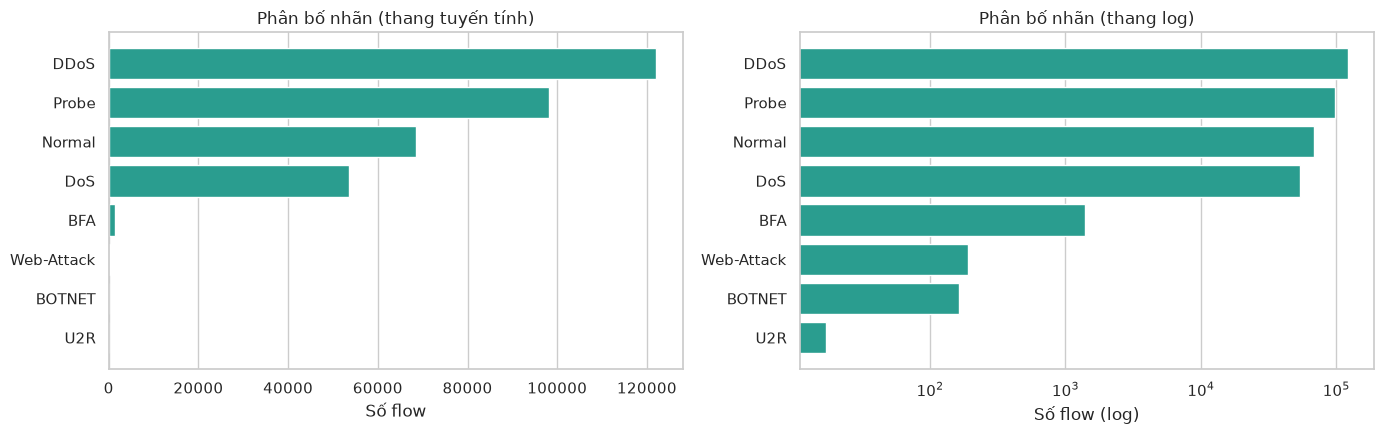

Label,BFA,BOTNET,DDoS,DoS,Normal,Probe,U2R,Web-Attack
__source_file,,,,,,,,
Normal_data.csv,0,0,0,0,68424,0,0,0
OVS.csv,1110,164,48413,52471,0,36372,0,192
metasploitable-2.csv,295,0,73529,1145,0,61757,17,0


In [5]:
# Phân bố nhãn
label_table = pd.DataFrame({
    "số flow": df_raw["Label"].value_counts(),
    "tỉ lệ (%)": df_raw["Label"].value_counts(normalize=True) * 100,
})
display(label_table)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
order = label_table.index[::-1]
axes[0].barh(order, label_table.loc[order, "số flow"], color="#2A9D8F")
axes[0].set_title("Phân bố nhãn (thang tuyến tính)")
axes[0].set_xlabel("Số flow")
axes[1].barh(order, label_table.loc[order, "số flow"], color="#2A9D8F")
axes[1].set_xscale("log")
axes[1].set_title("Phân bố nhãn (thang log)")
axes[1].set_xlabel("Số flow (log)")
for ax in axes:
    ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

# Nhãn theo file nguồn
display(pd.crosstab(df_raw["__source_file"], df_raw["Label"]))

**Nhận xét:**

- Nhãn **mất cân bằng rất mạnh**: bốn lớp lớn DDoS (35,5%), Probe (28,5%), Normal (19,9%), DoS (15,6%) chiếm 99,5% dữ liệu. Bốn lớp còn lại gộp lại chưa tới 0,52%: BFA 1.405, Web-Attack 192, BOTNET 164, **U2R chỉ 17 luồng**. Accuracy vì vậy gần như chỉ phản ánh bốn lớp lớn, nên cần F1-macro, Recall từng lớp và MCC.
- Ở góc nhìn nhị phân, Attack chiếm ~80% dữ liệu gốc, nên một mô hình "luôn đoán Attack" đã đạt Accuracy 80%.
- Nhãn gốc có lỗi định dạng: tồn tại cả `'DDoS'` và `'DDoS '` (thừa khoảng trắng), đã được chuẩn hóa.
- `Normal_data.csv` chỉ chứa Normal; `Web-Attack` và `BOTNET` chỉ có trong `OVS.csv`; `U2R` chỉ có trong `metasploitable-2.csv`. Nhãn và file nguồn gắn khá chặt, nên chúng tôi thêm thí nghiệm tổng quát hóa giữa hai kịch bản (mục 7.2).

In [6]:
# Kiểm tra nguy cơ rò rỉ từ các cột định danh / topo mạng
ID_COLS = ["Flow ID", "Src IP", "Dst IP", "Src Port", "Dst Port", "Timestamp"]
rows = []
for col in ID_COLS:
    per_value = df_raw.groupby(col)["Label"].nunique()
    rows.append({
        "cột": col,
        "số giá trị khác nhau": df_raw[col].nunique(),
        "% giá trị chỉ gắn với 1 nhãn": 100 * (per_value == 1).mean(),
    })
display(pd.DataFrame(rows))

# Giao thức (Protocol) theo nhãn
display(pd.crosstab(df_raw["Protocol"], df_raw["Label"]))

,cột,số giá trị khác nhau,% giá trị chỉ gắn với 1 nhãn
0,Flow ID,234971,99.9702
1,Src IP,122868,99.9951
2,Dst IP,1081,99.0749
3,Src Port,28273,34.6055
4,Dst Port,29695,78.0940
5,Timestamp,1392,100.0000


Label,BFA,BOTNET,DDoS,DoS,Normal,Probe,U2R,Web-Attack
Protocol,,,,,,,,
0,0,0,121439,0,389,28,0,0
6,1404,164,500,53555,34115,98078,16,192
17,1,0,3,61,33920,23,1,0


**Nhận xét:** các cột định danh gần như là "khóa" của nhãn: 99,99% địa chỉ `Src IP`, 99,07% `Dst IP` và 100% giá trị `Timestamp` chỉ xuất hiện với **đúng một nhãn**; 78% giá trị `Dst Port` cũng vậy. Nếu giữ lại, mô hình có thể đạt độ chính xác rất cao chỉ bằng cách nhớ "IP nào là máy tấn công trong lab". Quy tắc đó vô nghĩa khi đem sang mạng khác. Vì vậy cả 6 cột này bị loại khỏi đầu vào.

`Protocol` cũng tương quan mạnh với nhãn: gần như toàn bộ DDoS có `Protocol = 0`, còn UDP (17) gần như chỉ xuất hiện ở Normal. Tuy nhiên đây là đặc tính hành vi thật của lưu lượng (loại gói mà công cụ tấn công sinh ra), không phải định danh của lab, nên được giữ lại.

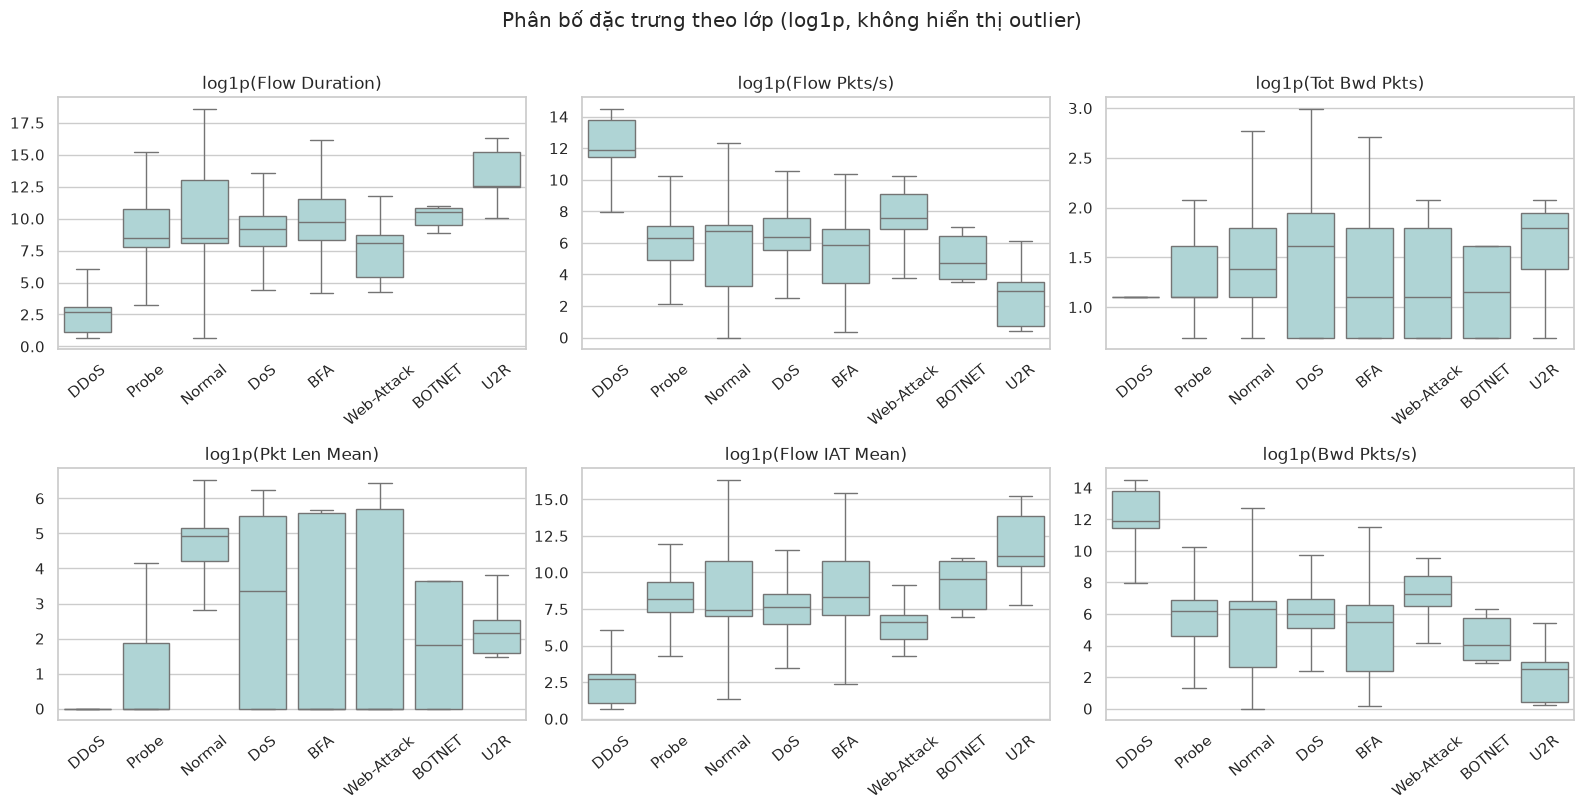

,Flow Duration,Flow Pkts/s,Tot Bwd Pkts,Pkt Len Mean,Flow IAT Mean,Bwd Pkts/s
Label,,,,,,
BFA,"17,398.0000",358.8731,2.0000,0.0000,"4,054.0000",238.3904
BOTNET,"36,435.5000",146.2961,2.5000,18.3889,"22,293.0714",73.1480
DDoS,14.0000,"142,857.1429",2.0000,0.0000,14.0000,"142,857.1429"
DoS,"10,249.0000",598.4739,4.0000,51.8571,"2,023.5714",408.4689
Normal,"4,799.0000",791.7656,3.0000,136.4000,"1,756.6667",515.0745
Probe,"5,019.0000",495.9088,2.0000,0.0000,"3,970.0000",458.5053
U2R,"273,133.0000",18.3061,5.0000,7.5455,"68,283.2500",10.9837
Web-Attack,"3,188.5000","2,004.0087",2.0000,0.0000,721.8333,"1,417.8490"


In [7]:
# So sánh một số đặc trưng hành vi giữa các lớp (lấy mẫu tối đa 3.000 flow/lớp, thang log1p)
key_feats = ["Flow Duration", "Flow Pkts/s", "Tot Bwd Pkts", "Pkt Len Mean", "Flow IAT Mean", "Bwd Pkts/s"]
sample_idx = np.concatenate([
    g.sample(min(len(g), 3000), random_state=SEED).index.to_numpy()
    for _, g in df_raw.groupby("Label")
])
sample = df_raw.loc[sample_idx]
label_order = df_raw["Label"].value_counts().index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.ravel(), key_feats):
    vals = np.log1p(sample[col].clip(lower=0))
    sns.boxplot(x=sample["Label"], y=vals, order=label_order, ax=ax,
                showfliers=False, color="#A8DADC")
    ax.set_title(f"log1p({col})")
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(axis="x", rotation=40)
plt.suptitle("Phân bố đặc trưng theo lớp (log1p, không hiển thị outlier)", y=1.01)
plt.tight_layout()
plt.show()

# Trung vị theo lớp (ít bị ảnh hưởng bởi outlier hơn trung bình)
display(df_raw.groupby("Label")[key_feats].median())

**Nhận xét:**

- Các đặc trưng có **phân bố đuôi dài** (long-tail), trải dài nhiều bậc độ lớn, nên phải dùng thang log mới quan sát được. Đây là một lý do chọn mô hình cây, vốn không bị ảnh hưởng bởi thang đo và outlier.
- **DDoS** tách biệt rõ nhất: luồng cực ngắn (trung vị `Flow Duration` 14 µs), tốc độ gói cực cao (trung vị `Flow Pkts/s` ≈ 142.857), không có payload (`Pkt Len Mean` = 0). Đây là dấu hiệu điển hình của flood.
- **U2R** và **BOTNET** có luồng dài, tốc độ thấp, IAT lớn (phiên điều khiển tương tác); **Normal** có payload lớn nhất (trung vị `Pkt Len Mean` ≈ 136 byte).
- **Probe, BFA, Web-Attack** có phân bố chồng lấn đáng kể (luồng ngắn, 1–2 gói trả về, payload gần 0). Có thể dự đoán các lớp này sẽ hay bị nhầm với nhau, và điều đó được xác nhận ở mục 6.3.

,tổng số flow,flow trùng (đặc trưng + nhãn),% trùng,còn lại sau khử trùng
Label,,,,
DDoS,121942,120422,98.7535,1520
Probe,98129,30989,31.5799,67140
Normal,68424,4310,6.2990,64114
DoS,53616,3306,6.1661,50310
BFA,1405,28,1.9929,1377
Web-Attack,192,9,4.6875,183
BOTNET,164,0,0.0000,164
U2R,17,0,0.0000,17


Tổng: 159,064 / 343,889 dòng (46.3%) là bản sao về mặt đặc trưng


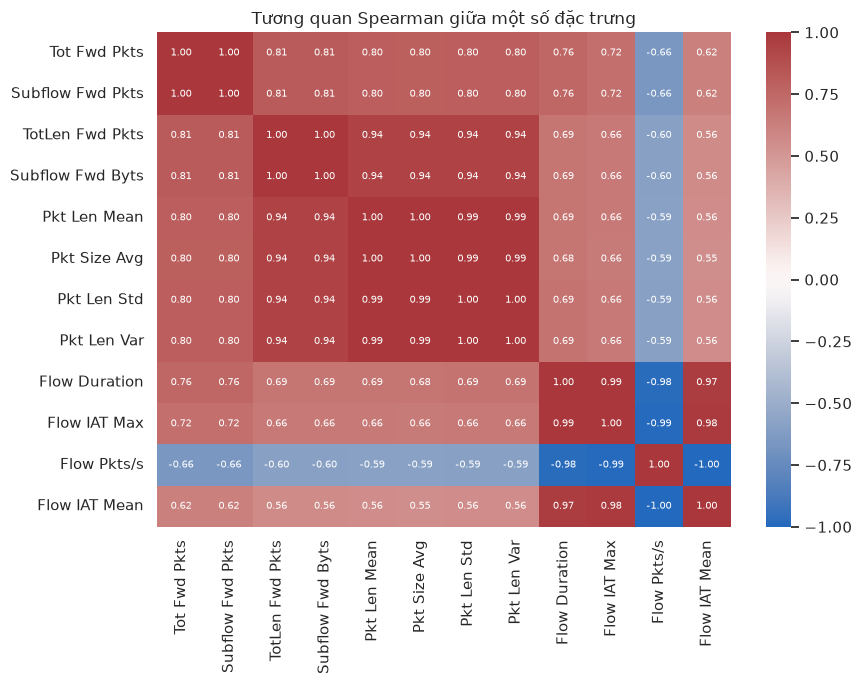

In [8]:
# Trùng lặp SAU KHI bỏ các cột định danh: nhiều flow tấn công giống hệt nhau về hành vi
feature_view = df_raw.drop(columns=ID_COLS + ["__source_file"])
dup_mask = feature_view.duplicated(keep="first")
dup_by_label = pd.DataFrame({
    "tổng số flow": df_raw["Label"].value_counts(),
    "flow trùng (đặc trưng + nhãn)": df_raw.loc[dup_mask, "Label"].value_counts(),
}).fillna(0).astype(int)
dup_by_label["% trùng"] = 100 * dup_by_label["flow trùng (đặc trưng + nhãn)"] / dup_by_label["tổng số flow"]
dup_by_label["còn lại sau khử trùng"] = dup_by_label["tổng số flow"] - dup_by_label["flow trùng (đặc trưng + nhãn)"]
display(dup_by_label.sort_values("tổng số flow", ascending=False))
print(f"Tổng: {dup_mask.sum():,} / {len(df_raw):,} dòng ({100*dup_mask.mean():.1f}%) là bản sao về mặt đặc trưng")

# Tương quan Spearman giữa một số đặc trưng (lấy mẫu 30.000 dòng)
corr_cols = ["Tot Fwd Pkts", "Subflow Fwd Pkts", "TotLen Fwd Pkts", "Subflow Fwd Byts",
             "Pkt Len Mean", "Pkt Size Avg", "Pkt Len Std", "Pkt Len Var",
             "Flow Duration", "Flow IAT Max", "Flow Pkts/s", "Flow IAT Mean"]
corr = df_raw[corr_cols].sample(30000, random_state=SEED).corr(method="spearman")
plt.figure(figsize=(9, 7))
sns.heatmap(corr, cmap="vlag", vmin=-1, vmax=1, annot=True, fmt=".2f", annot_kws={"size": 7})
plt.title("Tương quan Spearman giữa một số đặc trưng")
plt.tight_layout()
plt.show()

**Nhận xét tổng hợp từ EDA**

1. **Chất lượng:** không có giá trị thiếu hay vô cực. Có 12 đặc trưng hằng số (các cờ `Fwd PSH/URG`, `CWE`, `ECE`, toàn bộ nhóm `Bulk rate`, `Init Fwd Win Byts`, `Fwd Seg Size Min`). Có giá trị âm không hợp lệ: 8 luồng có `Flow Duration < 0`, và ~7.800 giá trị `Flow IAT Min` âm do lệch timestamp của CICFlowMeter.
2. **Trùng lặp là vấn đề lớn nhất:** bảng gốc chỉ có 1 dòng trùng hoàn toàn (vì Flow ID/IP/Timestamp khác nhau), nhưng **sau khi bỏ định danh thì 46,3% số dòng là bản sao** về mặt đặc trưng. Riêng **DDoS có 98,8% bản sao**: 121.942 luồng chỉ còn ~1.520 vector khác nhau, vì công cụ flood sinh ra hàng loạt gói giống hệt nhau. Nếu không khử trùng lặp, một nửa tập test sẽ là bản sao y hệt của tập train (xem mục 7.2). Sau khi khử, DDoS trở thành lớp nhỏ.
3. **Tương quan:** nhiều cặp đặc trưng có tương quan Spearman ≈ 1 (`Tot Fwd Pkts` ↔ `Subflow Fwd Pkts`, `Pkt Len Mean` ↔ `Pkt Size Avg`, `Pkt Len Std` ↔ `Pkt Len Var`, `Flow Pkts/s` ↔ `Flow IAT Mean` âm). Một số cặp giống hệt nhau về giá trị nên bị loại. Các cặp tương quan cao nhưng không trùng được giữ lại, vì mô hình cây không bị ảnh hưởng bởi đa cộng tuyến.
4. **Định danh:** IP/Port/Timestamp gắn gần 1-1 với nhãn, nên phải loại để tránh học "topology của lab".
5. **Mất cân bằng:** tỉ lệ lớn nhất/nhỏ nhất ≈ 7.000:1 (DDoS : U2R) trên dữ liệu gốc, và ≈ 3.900:1 (Probe : U2R) sau làm sạch.

## 4. Tiền xử lý dữ liệu

### 4.1 Làm sạch dữ liệu

Các bước (theo thứ tự) và lý do:

| Bước | Xử lý | Lý do |
|---|---|---|
| a | Bỏ `Flow ID`, `Src IP`, `Dst IP`, `Src Port`, `Dst Port`, `Timestamp` | Định danh/topo của phòng lab, gắn gần như 1-1 với nhãn → mô hình sẽ "học thuộc" địa chỉ thay vì hành vi, không tổng quát hóa được |
| b | Bỏ 12 đặc trưng hằng số | Không mang thông tin |
| c | Bỏ các cột giống hệt cột khác (ví dụ `Subflow Fwd Pkts` = `Tot Fwd Pkts`) | Dư thừa, làm phân tán importance |
| d | Bỏ dòng `Flow Duration < 0`; cắt các giá trị IAT/tốc độ âm về 0 | Thời lượng âm là lỗi đồng hồ của CICFlowMeter. `Init Bwd Win Byts = -1` là giá trị quy ước ("không quan sát được") nên giữ nguyên (`Init Fwd Win Byts` bằng -1 ở mọi dòng nên đã bị loại ở bước b) |
| e | Ép đặc trưng số về `float32`, rồi khử trùng lặp theo (đặc trưng + nhãn) | scikit-learn và XGBoost đều làm việc trên `float32`, nên trùng lặp phải được xác định trong đúng không gian mà mô hình nhìn thấy: khi kiểm tra trên bản `float64`, chúng tôi phát hiện 32 vector test khác train ở chữ số thập phân thứ 8 trở đi nhưng trùng y hệt sau khi ép `float32`. Tránh cùng một vector xuất hiện ở cả train và test: khi đó mô hình chỉ cần "tra bảng" cho phần test đó, và cơ cấu lớp bị méo (DDoS trông như lớp lớn nhất). Mức ảnh hưởng thực tế được định lượng ở mục 7.2 |
| f | Bỏ các vector đặc trưng giống nhau nhưng mang nhãn khác nhau | Mẫu mâu thuẫn, không thể phân loại đúng và gây nhiễu |

Không có giá trị thiếu hay vô cực nên không cần điền giá trị (imputation).

In [9]:
log = []
df = df_raw.copy()
log.append(("Dữ liệu gốc", len(df), df.shape[1]))

# (a) Bỏ các cột định danh / topo mạng: tránh mô hình học thuộc IP, cổng, thời điểm của phòng lab
df = df.drop(columns=ID_COLS)
log.append(("Bỏ 6 cột định danh (Flow ID, IP, Port, Timestamp)", len(df), df.shape[1]))

# (b) Bỏ đặc trưng hằng số
df = df.drop(columns=constant_cols)
log.append((f"Bỏ {len(constant_cols)} đặc trưng hằng số", len(df), df.shape[1]))

# (c) Bỏ đặc trưng trùng lặp hoàn toàn về giá trị (ví dụ Subflow Fwd Pkts == Tot Fwd Pkts)
feat_cols = [c for c in df.columns if c not in ("Label", "__source_file")]
dup_cols = df[feat_cols].T.duplicated()
identical_cols = dup_cols[dup_cols].index.tolist()
df = df.drop(columns=identical_cols)
log.append((f"Bỏ {len(identical_cols)} cột giống hệt cột khác", len(df), df.shape[1]))
print("Cột giống hệt cột khác:", identical_cols)

# (d) Giá trị không hợp lệ: thời lượng flow âm là lỗi đồng hồ -> bỏ dòng;
#     các giá trị IAT/tốc độ âm còn lại (lệch timestamp) -> cắt về 0.
#     'Init Bwd Win Byts' = -1 là giá trị quy ước (không quan sát được) nên giữ nguyên.
df = df[df["Flow Duration"] >= 0]
log.append(("Bỏ dòng có Flow Duration < 0", len(df), df.shape[1]))
clip_cols = [c for c in df.columns if c not in ("Label", "__source_file", "Init Bwd Win Byts", "Init Fwd Win Byts")
             and pd.api.types.is_numeric_dtype(df[c])]
n_clipped = int((df[clip_cols] < 0).sum().sum())
df[clip_cols] = df[clip_cols].clip(lower=0)
print("Số giá trị âm được cắt về 0:", n_clipped)

# (e) Khử trùng lặp theo (đặc trưng + nhãn): tránh cùng một flow xuất hiện ở cả train và test.
#     scikit-learn và XGBoost đều ép đầu vào về float32, nên trùng lặp phải được xác định TRONG KHÔNG GIAN
#     float32: nếu khử trên float64, một số vector khác nhau ở chữ số thứ 8 trở đi sẽ trở thành giống hệt nhau
#     khi vào mô hình và rò rỉ giữa train/test. (Ép float32 trước cũng giảm một nửa bộ nhớ.)
feat_cols = [c for c in df.columns if c not in ("Label", "__source_file")]
num_feat_cols = [c for c in feat_cols if c != "Protocol"]
df[num_feat_cols] = df[num_feat_cols].astype("float32")
df = df.drop_duplicates(subset=feat_cols + ["Label"], keep="first")
log.append(("Khử trùng lặp (đặc trưng + nhãn)", len(df), df.shape[1]))

# (f) Bỏ các vector đặc trưng mâu thuẫn (giống hệt nhau nhưng mang nhãn khác nhau)
conflict = df.duplicated(subset=feat_cols, keep=False)
df = df[~conflict].reset_index(drop=True)
log.append(("Bỏ vector đặc trưng mang nhãn mâu thuẫn", len(df), df.shape[1]))

display(pd.DataFrame(log, columns=["bước", "số dòng", "số cột"]))
print("Phân bố nhãn sau làm sạch:")
display(df["Label"].value_counts().to_frame("số flow"))

Cột giống hệt cột khác: ['PSH Flag Cnt', 'URG Flag Cnt', 'Fwd Seg Size Avg', 'Subflow Fwd Pkts', 'Subflow Bwd Pkts']


Số giá trị âm được cắt về 0: 7800


,bước,số dòng,số cột
0,Dữ liệu gốc,343889,85
1,"Bỏ 6 cột định danh (Flow ID, IP, Port, Timestamp)",343889,79
2,Bỏ 12 đặc trưng hằng số,343889,67
3,Bỏ 5 cột giống hệt cột khác,343889,62
4,Bỏ dòng có Flow Duration < 0,343881,62
5,Khử trùng lặp (đặc trưng + nhãn),184681,62
6,Bỏ vector đặc trưng mang nhãn mâu thuẫn,184521,62


Phân bố nhãn sau làm sạch:


,số flow
Label,
Probe,67055
Normal,63973
DoS,50309
DDoS,1520
BFA,1300
Web-Attack,183
BOTNET,164
U2R,17


**Kết quả làm sạch:** từ 343.889 luồng × 85 cột còn **184.521 luồng**, gồm 59 đặc trưng số + `Protocol` (one-hot thành 3 cột ở bước sau). Ngoài 12 đặc trưng hằng số, còn 5 cột bị loại vì giống hệt cột khác: `PSH Flag Cnt`, `URG Flag Cnt`, `Fwd Seg Size Avg`, `Subflow Fwd Pkts`, `Subflow Bwd Pkts`.

Khử trùng lặp loại **159.200 dòng**. Trong đó **138 dòng chỉ trùng nhau sau khi ép `float32`** (khác nhau từ chữ số có nghĩa thứ 8 trở đi, gần như toàn bộ là Normal). Nếu khử trùng lặp trên `float64` như cách làm thông thường, các cặp này vẫn được coi là khác nhau, nhưng đối với mô hình (vốn chỉ thấy `float32`) chúng giống hệt nhau và có thể nằm cả ở train lẫn test. Ô kiểm tra tự động ở mục 4.3 đã phát hiện đúng 32 vector như vậy trong tập test trước khi sửa. Bước bỏ vector mang nhãn mâu thuẫn loại thêm 160 dòng, gần như toàn bộ là cặp **Probe–BFA** (80 dòng Probe + 77 dòng BFA có vector giống hệt nhau; 2 Normal, 1 DoS). Đây là bằng chứng sớm rằng hai lớp này không thể tách hoàn toàn ở mức một luồng (xem mục 6.3).

Phân bố sau làm sạch thay đổi rõ rệt: **DDoS giảm từ 121.942 xuống 1.520 luồng**. Probe, Normal, DoS trở thành ba lớp lớn; U2R vẫn chỉ có 17 luồng.

### 4.2 Biến đổi đặc trưng

- **Biến phân loại:** `Protocol` (0, 6 = TCP, 17 = UDP) là mã định danh, không có ý nghĩa thứ tự → mã hóa one-hot. `OneHotEncoder` được `fit` **chỉ trên tập train**, rồi áp dụng cho validation/test (`handle_unknown="ignore"`).
- **Chuẩn hóa:** không dùng `StandardScaler`. Cả ba mô hình đều là mô hình cây, chia nút theo điều kiện $x_j \le t$. Phép chia chỉ phụ thuộc vào **thứ tự** các giá trị của $x_j$, nên với mọi phép biến đổi đơn điệu tăng $\phi$ (co giãn tuyến tính, log...), tập các cách chia dữ liệu huấn luyện $\{x: x_j \le t\} = \{x: \phi(x_j) \le \phi(t)\}$ là như nhau. Với XGBoost `hist`, các ngưỡng là phân vị, cũng bất biến với biến đổi đơn điệu. Vì vậy chuẩn hóa không cải thiện mô hình mà chỉ thêm một bước có nguy cơ rò rỉ.
- **Nhãn:** `y_bin` (0 = Normal, 1 = Attack) cho bài toán A; `LabelEncoder` ánh xạ 8 nhãn sang 0..7 cho bài toán B (XGBoost yêu cầu nhãn số nguyên liên tục).
- Không tạo thêm đặc trưng mới: bộ đặc trưng CICFlowMeter đã rất giàu thông tin (xem mục 7.1).

In [10]:
FEATURES = [c for c in df.columns if c not in ("Label", "__source_file")]
CAT_COLS = ["Protocol"]                       # giao thức: 0 / 6 (TCP) / 17 (UDP) -> biến phân loại
NUM_COLS = [c for c in FEATURES if c not in CAT_COLS]
print(f"Số đặc trưng đầu vào: {len(FEATURES)} ({len(NUM_COLS)} số + {len(CAT_COLS)} phân loại)")

# Hai biến mục tiêu
# - Bài toán A (phát hiện): nhị phân Normal (0) / Attack (1)
# - Bài toán B (phân loại): 8 lớp
y_bin_all = (df["Label"] != "Normal").astype(int).to_numpy()
label_encoder = LabelEncoder().fit(df["Label"])
CLASS_NAMES = list(label_encoder.classes_)
y_multi_all = label_encoder.transform(df["Label"])
print("Các lớp:", dict(enumerate(CLASS_NAMES)))
# Chỉ số 7 lớp còn lại khi bỏ U2R (dùng cho độ đo bổ sung "F1-macro trừ U2R")
KEEP7 = [i for i, c in enumerate(CLASS_NAMES) if c != "U2R"]


class ProtocolEncoder:
    """One-hot cho cột Protocol; học danh sách giá trị trên tập train, áp dụng lại cho val/test."""
    def fit(self, X):
        self.enc = OneHotEncoder(handle_unknown="ignore", sparse_output=False).fit(X[CAT_COLS])
        self.out_cols = [f"Protocol_{int(v)}" for v in self.enc.categories_[0]]
        return self

    def transform(self, X):
        oh = pd.DataFrame(self.enc.transform(X[CAT_COLS]), columns=self.out_cols, index=X.index)
        return pd.concat([X[NUM_COLS].astype("float32"), oh.astype("float32")], axis=1)

# Ghi chú: cả ba mô hình đều dựa trên cây quyết định (chia theo ngưỡng), nên KHÔNG cần chuẩn hóa
# StandardScaler — phép biến đổi đơn điệu không làm thay đổi cách chia của cây.

Số đặc trưng đầu vào: 60 (59 số + 1 phân loại)
Các lớp: {0: 'BFA', 1: 'BOTNET', 2: 'DDoS', 3: 'DoS', 4: 'Normal', 5: 'Probe', 6: 'U2R', 7: 'Web-Attack'}


### 4.3 Chia tập huấn luyện, kiểm định và kiểm tra

Chia **70% train / 15% validation / 15% test**, **phân tầng theo nhãn 8 lớp** (stratified), để các lớp hiếm có mặt ở cả ba tập. Hai bài toán dùng **chung một phép chia** nên kết quả so sánh được với nhau. Validation chỉ dùng để chọn siêu tham số; sau đó mô hình cuối được huấn luyện lại trên **train + validation (85%)**. Tập test chỉ được dùng một lần ở mục 6.3. Ngay sau khi chia, một ô kiểm tra tự động (`assert`) xác nhận các điều kiện chống rò rỉ: không còn cột định danh, ba tập rời nhau, không có NaN/vô cực/giá trị âm ngoài quy ước, và **không có vector đặc trưng nào của tập test xuất hiện y hệt trong train/validation**. Nếu một điều kiện sai, notebook dừng ngay tại đó thay vì cho ra con số sai.

In [11]:
# Chia 70% train / 15% validation / 15% test, phân tầng theo nhãn 8 lớp
idx_all = np.arange(len(df))
idx_train, idx_temp = train_test_split(idx_all, test_size=0.30, random_state=SEED, stratify=y_multi_all)
idx_val, idx_test = train_test_split(idx_temp, test_size=0.50, random_state=SEED, stratify=y_multi_all[idx_temp])

prep = ProtocolEncoder().fit(df.iloc[idx_train])           # fit CHỈ trên train
X_train = prep.transform(df.iloc[idx_train])
X_val = prep.transform(df.iloc[idx_val])
X_test = prep.transform(df.iloc[idx_test])

Y = {
    "binary": {"train": y_bin_all[idx_train], "val": y_bin_all[idx_val], "test": y_bin_all[idx_test]},
    "multi": {"train": y_multi_all[idx_train], "val": y_multi_all[idx_val], "test": y_multi_all[idx_test]},
}

split_table = pd.DataFrame({
    name: pd.Series(label_encoder.inverse_transform(Y["multi"][name])).value_counts()
    for name in ["train", "val", "test"]
}).loc[df["Label"].value_counts().index]
split_table.loc["TỔNG"] = split_table.sum()
display(split_table)
print("Kích thước ma trận đặc trưng:", X_train.shape, X_val.shape, X_test.shape)

,train,val,test
Label,,,
Probe,46938,10058,10059
Normal,44781,9596,9596
DoS,35216,7546,7547
DDoS,1064,228,228
BFA,910,195,195
Web-Attack,128,27,28
BOTNET,115,25,24
U2R,12,3,2
TỔNG,129164,27678,27679


Kích thước ma trận đặc trưng: (129164, 62) (27678, 62) (27679, 62)


In [12]:
# Kiểm tra tự động (fail-fast) trước khi huấn luyện: nếu một điều kiện sai, notebook dừng tại đây
def row_hash(X):
    """Băm 64-bit từng dòng (dùng để so khớp vector đặc trưng giữa các tập; xác suất trùng băm ~1e-19/cặp)."""
    return pd.util.hash_pandas_object(X, index=False).to_numpy()

X_all = pd.concat([X_train, X_val, X_test])
assert not set(ID_COLS) & set(X_all.columns), "còn cột định danh trong đầu vào"
assert len(np.union1d(np.union1d(idx_train, idx_val), idx_test)) == len(df) == len(X_all), "ba tập phải rời nhau"
assert np.isfinite(X_all.to_numpy()).all(), "có NaN/inf"
assert not (X_all.drop(columns="Init Bwd Win Byts") < 0).any().any(), "còn giá trị âm ngoài quy ước"
overlap = np.isin(row_hash(X_test), row_hash(pd.concat([X_train, X_val])))
assert not overlap.any(), f"{overlap.sum()} vector test trùng y hệt train/val"
del X_all
print("OK: không còn định danh; ba tập rời nhau; không NaN/inf/âm; 0 vector test trùng train/val")

OK: không còn định danh; ba tập rời nhau; không NaN/inf/âm; 0 vector test trùng train/val


**Nhận xét:** nhờ chia phân tầng, tỉ lệ mỗi lớp ở ba tập gần như bằng nhau. Tuy vậy, lớp U2R chỉ có **12 / 3 / 2** mẫu ở train / val / test. Chỉ cần một mẫu U2R đúng hay sai là F1 của lớp này nhảy giữa 0, 0,67 và 1, kéo theo F1-macro 8 lớp dao động ~0,04–0,12. Vì vậy chúng tôi (i) tinh chỉnh bài toán 8 lớp bằng cross-validation thay vì một tập validation duy nhất (mục 5.4), và (ii) báo cáo thêm **F1-macro không tính U2R** và kết quả 5-fold CV (mục 7.2) để so sánh mô hình một cách ổn định hơn.

### 4.4 Xử lý mất cân bằng nhãn

Chúng tôi dùng **trọng số lớp (class weights)** thay vì oversampling (SMOTE) vì: (i) các lớp hiếm quá nhỏ (U2R chỉ ~12 mẫu train) nên sinh mẫu tổng hợp dễ tạo ra điểm không thực tế; (ii) trọng số không làm thay đổi dữ liệu và không có nguy cơ rò rỉ nếu chỉ tính trên train. Thay vì áp dụng cứng, **dùng/không dùng trọng số được xem là một siêu tham số** và được chọn theo F1-macro ở bước tinh chỉnh (mục 5.4). Ngoài ra, chúng tôi đánh giá bằng F1-macro, Recall-macro và MCC thay vì chỉ Accuracy (mục 6.2).

In [13]:
# Trọng số lớp 'balanced': w_c = n_samples / (n_classes * n_c), tính CHỈ trên tập train
w_multi = compute_sample_weight("balanced", Y["multi"]["train"])
weight_table = (
    pd.DataFrame({"Label": label_encoder.inverse_transform(Y["multi"]["train"]), "w": w_multi})
    .groupby("Label")["w"].first().sort_values()
    .to_frame("trọng số mỗi mẫu")
)
display(weight_table)

# Trọng số sẽ được xem như MỘT SIÊU THAM SỐ (có / không) trong bước tinh chỉnh ở mục 5.4:
#  - Decision Tree / Random Forest: class_weight = None | 'balanced' | 'balanced_subsample'
#  - XGBoost: sample_weight = None | compute_sample_weight('balanced', y_train)

,trọng số mỗi mẫu
Label,
Probe,0.3440
Normal,0.3605
DoS,0.4585
DDoS,15.1743
BFA,17.7423
Web-Attack,126.1367
BOTNET,140.3957
U2R,"1,345.4583"


## 5. Phương pháp tiếp cận

### 5.1 Giải thuật hoặc mô hình được lựa chọn

| Mô hình | Ý tưởng | Lý do lựa chọn | Vai trò |
|---|---|---|---|
| **Decision Tree** (CART) | Chia không gian đặc trưng đệ quy theo ngưỡng, tối đa hóa độ giảm Gini impurity | Nhanh, dễ giải thích (có thể chuyển thành luật if-then để cài trên controller/switch), không cần chuẩn hóa | **Đường cơ sở (baseline)** |
| **Random Forest** [2] | Bagging: nhiều cây độc lập trên mẫu bootstrap + tập con đặc trưng ngẫu nhiên; dự đoán bằng **trung bình xác suất** của các cây (soft voting, cách cài đặt của scikit-learn) | Giảm phương sai/overfitting của cây đơn, bền với nhiễu, huấn luyện song song | Ensemble họ bagging |
| **XGBoost** [3] | Gradient boosting bậc hai: cây được thêm tuần tự để giảm hàm mất mát; chuẩn hóa L2 trên giá trị lá ($\lambda$), phạt số lá ($\gamma$), shrinkage ($\eta$), lấy mẫu con dòng/cột | Thường cho kết quả tốt nhất trên dữ liệu bảng, hỗ trợ trọng số mẫu, cài đặt `hist` nhanh | Ensemble họ boosting |

Cả ba đều phù hợp với đặc điểm dữ liệu: dữ liệu dạng bảng, ~60 đặc trưng số có phân bố rất lệch (long-tail), giá trị trải từ 0 tới ~$10^8$, nhiều đặc trưng tương quan mạnh — những điều mà mô hình cây xử lý tốt mà không cần biến đổi. Kích thước dữ liệu (~185 nghìn luồng) đủ nhỏ để huấn luyện trên CPU trong vài giây đến vài chục giây. Ngoài ra chúng tôi thêm `DummyClassifier` (luôn dự đoán lớp phổ biến nhất) làm mốc tham chiếu thấp nhất.

#### 5.1.1 Cơ sở lý thuyết

Ký hiệu: tập huấn luyện $\{(\mathbf{x}_i, y_i)\}_{i=1}^{n}$, $\mathbf{x}_i \in \mathbb{R}^{p}$ ($p = 62$), $y_i \in \{1,\dots,K\}$ ($K = 2$ hoặc $8$).

**(a) Decision Tree (CART).** Mỗi nút $S$ được chia thành $S_L = \{\mathbf{x} \in S : x_j \le t\}$ và $S_R = S \setminus S_L$. Cặp $(j, t)$ được chọn để cực đại độ giảm Gini impurity:

$$G(S) = 1 - \sum_{k=1}^{K} p_k(S)^2, \qquad \Delta G(j,t) = G(S) - \frac{|S_L|}{|S|}\,G(S_L) - \frac{|S_R|}{|S|}\,G(S_R),$$

trong đó $p_k(S)$ là tỉ lệ (có trọng số) mẫu lớp $k$ trong nút, và $|\cdot|$ là tổng trọng số mẫu trong nút (bằng số mẫu khi không dùng trọng số). Một nút ngừng chia khi nó thuần nhất, khi đạt `max_depth`, hoặc khi mọi phép chia đều tạo ra lá có ít hơn `min_samples_leaf` mẫu. Dự đoán: $\hat{P}(y = k \mid \mathbf{x}) = p_k(\text{lá chứa } \mathbf{x})$, $\hat{y} = \arg\max_k \hat{P}(y=k \mid \mathbf{x})$. Cây sâu có độ chệch thấp nhưng **phương sai cao**: thay đổi nhỏ trong dữ liệu có thể làm thay đổi cả cấu trúc cây.

**(b) Random Forest.** Huấn luyện $B$ cây ($B = 150$). Cây thứ $b$ học trên một mẫu bootstrap (rút $n$ mẫu có hoàn lại), và tại mỗi nút chỉ xét một tập con ngẫu nhiên gồm $m = \lfloor\sqrt{p}\rfloor = 7$ đặc trưng. Dự đoán là trung bình xác suất:

$$\hat{P}_{\text{RF}}(y = k \mid \mathbf{x}) = \frac{1}{B}\sum_{b=1}^{B} \hat{P}_b(y = k \mid \mathbf{x}).$$

Nếu mỗi cây có phương sai $\sigma^2$ và hệ số tương quan giữa hai cây là $\rho$, phương sai của trung bình là $\rho\sigma^2 + \frac{1-\rho}{B}\sigma^2$. Bootstrap và việc chọn ngẫu nhiên đặc trưng làm **giảm $\rho$**, nhờ đó giảm phương sai so với một cây đơn mà không tăng độ chệch nhiều.

**(c) XGBoost.** Mô hình cộng dồn $\hat{y}_i^{(t)} = \hat{y}_i^{(t-1)} + \eta\, f_t(\mathbf{x}_i)$ (η = `learning_rate`, $\hat{y}^{(0)}$ là giá trị khởi tạo). Cây $f_t$ được xây để cực tiểu hàm mục tiêu có chuẩn hóa dưới đây, sau đó được co lại theo hệ số η trước khi cộng vào mô hình:

$$\mathcal{L}^{(t)} = \sum_{i=1}^{n} s_i\, \ell\big(y_i, \hat{y}_i^{(t-1)} + f_t(\mathbf{x}_i)\big) + \Omega(f_t), \qquad \Omega(f) = \gamma T + \tfrac{1}{2}\lambda \sum_{j=1}^{T} \omega_j^2 ,$$

với $T$ là số lá, $\omega_j$ là giá trị lá, $s_i$ là trọng số mẫu ($s_i = 1$ nếu không dùng trọng số lớp). Tham số mặc định: $\lambda = 1$, $\gamma = 0$, chuẩn hóa L1 $\alpha = 0$. Khai triển Taylor bậc hai quanh $\hat{y}^{(t-1)}$, với $g_i = \partial \ell / \partial \hat{y}$ và $h_i = \partial^2 \ell / \partial \hat{y}^2$, cho giá trị lá tối ưu và độ lợi của một phép chia:

$$\omega_j^{*} = -\frac{G_j}{H_j + \lambda}, \quad G_j = \sum_{i \in I_j} s_i g_i,\; H_j = \sum_{i \in I_j} s_i h_i; \qquad \text{Gain} = \frac{1}{2}\left[\frac{G_L^2}{H_L+\lambda} + \frac{G_R^2}{H_R+\lambda} - \frac{(G_L+G_R)^2}{H_L+H_R+\lambda}\right] - \gamma .$$

- Bài toán nhị phân dùng log-loss $\ell = -[y \log p + (1-y)\log(1-p)]$ với $p = \sigma(\hat{y})$, cho $g = p - y$ và $h = p(1-p)$.
- Bài toán 8 lớp dùng softmax $p_k = e^{\hat{y}_k} / \sum_{k'} e^{\hat{y}_{k'}}$, mỗi vòng xây $K$ cây (một cây cho mỗi lớp), gradient $g_{ik} = p_{ik} - \mathbb{1}[y_i = k]$; XGBoost chỉ dùng phần đường chéo của ma trận Hessian, $h_{ik} \propto p_{ik}(1 - p_{ik})$, để mỗi cây của lớp $k$ được tối ưu độc lập theo công thức $\omega_j^*$ ở trên. Hệ quả: với 8 lớp, mỗi vòng boosting tốn gấp 8 lần một vòng nhị phân, giải thích vì sao thời gian huấn luyện/suy luận của XGBoost 8 lớp cao hơn hẳn bản nhị phân (mục 6.3).
- `tree_method="hist"` gom mỗi đặc trưng vào tối đa 256 khoảng theo phân vị trước khi tìm ngưỡng.
- `subsample = 0.9` và `colsample_bytree = 0.8` lấy mẫu con dòng/cột cho mỗi cây, giúp giảm overfitting.

Mỗi cây mới sửa phần sai số còn lại của các cây trước, nên boosting chủ yếu **giảm độ chệch**; $\eta$, $\lambda$ và lấy mẫu con kiểm soát phương sai.

**(d) Trọng số lớp.** Với tùy chọn `balanced`, mỗi mẫu lớp $c$ nhận trọng số

$$w_c = \frac{n}{K \, n_c}, \qquad \text{nên} \quad \sum_{i:\, y_i = c} w_c = \frac{n}{K} \;\; \text{với mọi } c,$$

tức là mọi lớp đóng góp tổng trọng số như nhau vào Gini (DT/RF) hoặc vào $G_j, H_j$ (XGBoost, qua $s_i = w_{y_i}$). `balanced_subsample` của RF tính lại $w_c$ trên từng mẫu bootstrap. Đổi lại, lớp hiếm được "phóng đại": mỗi mẫu U2R nặng gấp ~3.900 lần một mẫu Probe, có thể làm tăng dự đoán nhầm sang lớp hiếm (giảm Precision). Vì vậy dùng hay không dùng trọng số được chọn bằng dữ liệu (mục 5.4) chứ không áp đặt.

### 5.2 Pipeline tổng thể

```text
 3 file CSV InSDN (343.889 luồng)
        │
        ▼
 [4.1] Làm sạch: bỏ định danh (IP/Port/Timestamp) → bỏ đặc trưng hằng số & cột trùng
        → xử lý giá trị âm → ép float32 & khử trùng lặp → bỏ mẫu mâu thuẫn nhãn
        │
        ▼
 [4.3] Chia phân tầng 70 / 15 / 15  ──►  train │ validation │ test   (+ assert chống rò rỉ)
        │
        ▼
 [4.2] One-hot Protocol (fit trên train)      [4.4] Trọng số lớp (tính trên train)
        │
        ├──► Bài toán A: Normal vs Attack (nhị phân)
        └──► Bài toán B: 8 lớp
                 │
                 ▼
 [5.3–5.4] Decision Tree │ Random Forest │ XGBoost
           grid search, tiêu chí F1-macro (nhị phân: validation; 8 lớp: 3-fold CV)
                 │
                 ▼
 [6] Huấn luyện lại trên train + val, đánh giá MỘT LẦN trên test: Accuracy, P/R/F1 macro, MCC, ROC-AUC, F1 từng lớp,
     ma trận nhầm lẫn, thời gian huấn luyện & suy luận
                 │
                 ▼
 [7] Feature importance, phân tích lỗi, kiểm tra độ tin cậy
     (overfitting, 5-fold CV, ảnh hưởng trùng lặp, tổng quát hóa OVS → Metasploitable-2,
      kiểm định McNemar + bootstrap cho giả thuyết H1–H3)
```

### 5.3 Cài đặt và huấn luyện mô hình

Các hàm dưới đây dùng chung cho mọi thí nghiệm: `make_model` khởi tạo mô hình với seed cố định, `fit_model` huấn luyện và đo thời gian, `evaluate` tính toàn bộ độ đo và thời gian suy luận. Trước khi tinh chỉnh, cả ba mô hình được huấn luyện với siêu tham số ban đầu:

- **Decision Tree:** mặc định của scikit-learn (Gini, cây phát triển tối đa, `min_samples_leaf=1`).
- **Random Forest:** `n_estimators=100`, còn lại mặc định (`max_features="sqrt"`, bootstrap).
- **XGBoost:** `n_estimators=200`, `max_depth=6`, `learning_rate=0.1`, `tree_method="hist"`.

In [14]:
def make_model(name, task, seed=SEED, **params):
    """Khởi tạo mô hình với seed cố định. Tham số 'balanced' (bool) chỉ dùng cho XGBoost."""
    params = dict(params)
    params.pop("balanced", None)
    if name == "Decision Tree":
        return DecisionTreeClassifier(random_state=seed, **params)
    if name == "Random Forest":
        return RandomForestClassifier(random_state=seed, n_jobs=N_JOBS, **params)
    if name == "XGBoost":
        extra = {"objective": "binary:logistic", "eval_metric": "logloss"} if task == "binary" \
            else {"objective": "multi:softprob", "eval_metric": "mlogloss"}
        return XGBClassifier(random_state=seed, n_jobs=N_JOBS, tree_method="hist", **extra, **params)
    raise ValueError(name)


def fit_model(name, task, X, y, seed=SEED, **params):
    model = make_model(name, task, seed=seed, **params)
    kw = {}
    if name == "XGBoost" and params.get("balanced", False):
        kw["sample_weight"] = compute_sample_weight("balanced", y)
    t0 = time.perf_counter()
    model.fit(X, y, **kw)
    return model, time.perf_counter() - t0


def evaluate(model, X, y, task):
    t0 = time.perf_counter()
    proba = model.predict_proba(X)
    infer = time.perf_counter() - t0
    pred = proba.argmax(axis=1)
    if task == "binary":
        auc = roc_auc_score(y, proba[:, 1])
    else:
        auc = roc_auc_score(y, proba, multi_class="ovr", average="macro", labels=np.arange(len(CLASS_NAMES)))
    out = {
        "Accuracy": accuracy_score(y, pred),
        "Precision (macro)": precision_score(y, pred, average="macro", zero_division=0),
        "Recall (macro)": recall_score(y, pred, average="macro", zero_division=0),
        "F1 (macro)": f1_score(y, pred, average="macro", zero_division=0),
        "F1 (weighted)": f1_score(y, pred, average="weighted", zero_division=0),
        "MCC": matthews_corrcoef(y, pred),
        "ROC-AUC": auc,
        "Suy luận (µs/flow)": 1e6 * infer / len(y),
    }
    if task == "multi":
        # F1-macro không tính U2R: lớp này chỉ có 2 mẫu trong test nên 1 mẫu đúng/sai làm F1-macro dao động ~0,06
        out["F1 (macro, trừ U2R)"] = f1_score(y, pred, labels=KEEP7, average="macro", zero_division=0)
    return out, pred, proba


# Siêu tham số BAN ĐẦU (mặc định hợp lý, chưa tinh chỉnh)
DEFAULT_PARAMS = {
    "Decision Tree": {},                                             # cây phát triển tối đa
    "Random Forest": {"n_estimators": 100},
    "XGBoost": {"n_estimators": 200, "max_depth": 6, "learning_rate": 0.1},
}

rows = []
for task in ["binary", "multi"]:
    for name in MODEL_NAMES:
        m, t = fit_model(name, task, X_train, Y[task]["train"], **DEFAULT_PARAMS[name])
        res, _, _ = evaluate(m, X_val, Y[task]["val"], task)
        rows.append({"bài toán": task, "mô hình": name, "train (s)": t, **res})
default_val = pd.DataFrame(rows)
display(default_val[["bài toán", "mô hình", "train (s)", "Accuracy", "F1 (macro)", "Recall (macro)", "MCC"]])

,bài toán,mô hình,train (s),Accuracy,F1 (macro),Recall (macro),MCC
0,binary,Decision Tree,3.8098,0.9997,0.9996,0.9996,0.9993
1,binary,Random Forest,12.0978,0.9999,0.9998,0.9998,0.9997
2,binary,XGBoost,3.3488,0.9999,0.9999,0.9999,0.9998
3,multi,Decision Tree,3.5052,0.9983,0.9122,0.9054,0.9975
4,multi,Random Forest,12.6469,0.9984,0.9025,0.8998,0.9976
5,multi,XGBoost,20.5722,0.9988,0.9177,0.9037,0.9983


**Nhận xét (siêu tham số ban đầu, đo trên validation):** ở bài toán nhị phân, cả ba mô hình đạt F1-macro ≥ 0,9996 ngay khi chưa tinh chỉnh; bài toán phát hiện Normal/Attack gần như "đã bão hòa". Ở bài toán 8 lớp, Accuracy của cả ba đều ~0,998–0,999 nhưng F1-macro chỉ nằm trong khoảng 0,90–0,92 (XGBoost 0,918, Decision Tree 0,912, Random Forest 0,903). Chênh lệch giữa Accuracy và F1-macro đến từ các lớp hiếm (validation chỉ có 3 mẫu U2R và 25 mẫu BOTNET). Điều này cho thấy vì sao không dùng Accuracy làm tiêu chí chính, và vì sao bài toán 8 lớp được tinh chỉnh bằng cross-validation thay vì một tập validation duy nhất (mục 5.4).

### 5.4 Tinh chỉnh siêu tham số

Phương pháp: **grid search** trên không gian tìm kiếm dưới đây (28 cấu hình cho mỗi bài toán), tiêu chí chọn là **F1-macro**. Tập test không được dùng ở bước này.

- **Bài toán nhị phân:** mỗi cấu hình được huấn luyện trên train và chấm điểm trên validation, vì các lớp đều đủ lớn.
- **Bài toán 8 lớp:** tập validation chỉ có 3 mẫu U2R và 25 mẫu BOTNET, nên điểm trên một tập validation rất nhiễu. Chúng tôi dùng **3-fold stratified cross-validation trên (train + validation)** và lấy F1-macro trung bình, giúp giảm phương sai khi chọn cấu hình.

| Mô hình | Siêu tham số | Giá trị thử |
|---|---|---|
| Decision Tree | `max_depth` / `min_samples_leaf` / `class_weight` | {10, 20, None} / {1, 5} / {None, balanced} |
| Random Forest | `max_depth` / `min_samples_leaf` / `class_weight` (`n_estimators=150`, `max_features="sqrt"`) | {20, None} / {1, 3} / {None, balanced_subsample} |
| XGBoost | `max_depth` / `learning_rate` / trọng số lớp (`n_estimators=300`, `subsample=0.9`, `colsample_bytree=0.8`) | {6, 10} / {0.1, 0.3} / {không, balanced} |

Lưới tìm kiếm được giữ nhỏ có chủ ý để notebook chạy trong thời gian hợp lý trên CPU (khoảng 20 phút cho bước này trên máy 2 nhân).

In [15]:
# Không gian tìm kiếm (grid search) — chọn cấu hình có F1-macro cao nhất
# (nhị phân: chấm trên tập validation; 8 lớp: trung bình 3-fold CV trên train + val)
SEARCH_SPACE = {
    "Decision Tree": {
        "max_depth": [10, 20, None],
        "min_samples_leaf": [1, 5],
        "class_weight": [None, "balanced"],
    },
    "Random Forest": {
        "n_estimators": [150],
        "max_depth": [20, None],
        "min_samples_leaf": [1, 3],
        "max_features": ["sqrt"],
        "class_weight": [None, "balanced_subsample"],
    },
    "XGBoost": {
        "n_estimators": [300],
        "max_depth": [6, 10],
        "learning_rate": [0.1, 0.3],
        "subsample": [0.9],
        "colsample_bytree": [0.8],
        "balanced": [False, True],
    },
}

# - Bài toán nhị phân: các lớp đều lớn -> chấm điểm trên tập validation cố định.
# - Bài toán 8 lớp: validation chỉ có 3 mẫu U2R, 25 BOTNET... nên điểm trên một tập validation rất nhiễu.
#   Vì vậy dùng 3-fold stratified CV trên (train + val) và lấy F1-macro trung bình làm tiêu chí.
X_trval = pd.concat([X_train, X_val])
y_trval_multi = np.concatenate([Y["multi"]["train"], Y["multi"]["val"]])
for _t in ["binary", "multi"]:
    Y[_t]["trval"] = np.concatenate([Y[_t]["train"], Y[_t]["val"]])
tune_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)


def score_config(name, task, params):
    if task == "binary":
        m, t = fit_model(name, task, X_train, Y[task]["train"], **params)
        return f1_score(Y[task]["val"], m.predict(X_val), average="macro"), t
    scores, times = [], []
    for tr, va in tune_cv.split(X_trval, y_trval_multi):
        m, t = fit_model(name, task, X_trval.iloc[tr], y_trval_multi[tr], **params)
        scores.append(f1_score(y_trval_multi[va], m.predict(X_trval.iloc[va]), average="macro"))
        times.append(t)
    return float(np.mean(scores)), float(np.mean(times))


tuning_rows, BEST_PARAMS = [], {"binary": {}, "multi": {}}
t_start = time.perf_counter()
for task in ["binary", "multi"]:
    for name in MODEL_NAMES:
        best = (-1, None)
        for params in ParameterGrid(SEARCH_SPACE[name]):
            score, t = score_config(name, task, params)
            tuning_rows.append({"bài toán": task, "mô hình": name, "tham số": str(params),
                                "F1-macro (chọn mô hình)": score, "train (s)": t})
            if score > best[0]:
                best = (score, params)
        BEST_PARAMS[task][name] = best[1]
        print(f"[{time.perf_counter() - t_start:5.0f}s] {task:6s} {name:13s} -> F1-macro={best[0]:.4f}")
print(f"Tổng thời gian tinh chỉnh: {time.perf_counter() - t_start:.0f} s")

tuning_df = pd.DataFrame(tuning_rows)
best_table = (tuning_df.sort_values("F1-macro (chọn mô hình)", ascending=False)
              .groupby(["bài toán", "mô hình"], sort=False).head(1)
              .sort_values(["bài toán", "mô hình"]))
pd.set_option("display.max_colwidth", 200)
display(best_table[["bài toán", "mô hình", "F1-macro (chọn mô hình)", "train (s)", "tham số"]])

[   42s] binary Decision Tree -> F1-macro=0.9996


[  191s] binary Random Forest -> F1-macro=0.9999


[  224s] binary XGBoost       -> F1-macro=1.0000


[  315s] multi  Decision Tree -> F1-macro=0.9402


[  693s] multi  Random Forest -> F1-macro=0.9265


[ 1223s] multi  XGBoost       -> F1-macro=0.9524
Tổng thời gian tinh chỉnh: 1223 s


,bài toán,mô hình,F1-macro (chọn mô hình),train (s),tham số
4,binary,Decision Tree,0.9996,3.6383,"{'class_weight': None, 'max_depth': None, 'min_samples_leaf': 1}"
13,binary,Random Forest,0.9999,18.2755,"{'class_weight': None, 'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'n_estimators': 150}"
27,binary,XGBoost,1.0000,3.5185,"{'balanced': True, 'colsample_bytree': 0.8, 'learning_rate': 0.3, 'max_depth': 10, 'n_estimators': 300, 'subsample': 0.9}"
38,multi,Decision Tree,0.9402,2.3508,"{'class_weight': 'balanced', 'max_depth': None, 'min_samples_leaf': 1}"
45,multi,Random Forest,0.9265,16.2953,"{'class_weight': 'balanced_subsample', 'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'n_estimators': 150}"
48,multi,XGBoost,0.9524,21.2817,"{'balanced': False, 'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 300, 'subsample': 0.9}"


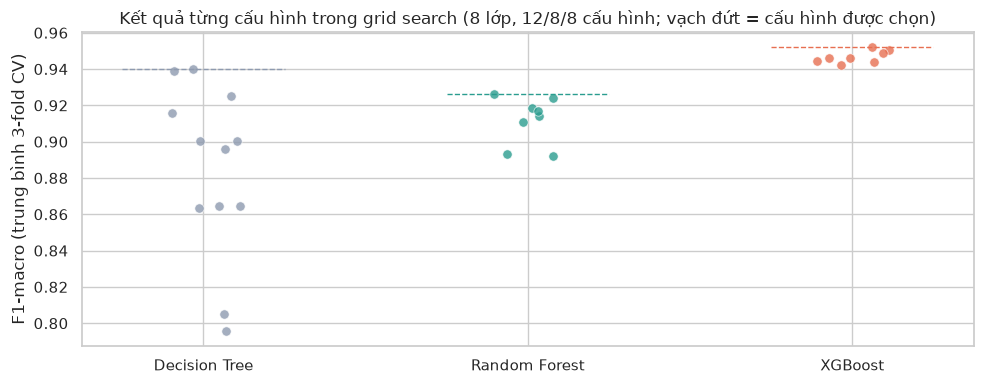

In [16]:
# Độ nhạy của F1-macro (trung bình 3-fold CV) với các cấu hình trong lưới tìm kiếm — bài toán 8 lớp
rng_jitter = np.random.default_rng(SEED)          # nhiễu ngang chỉ để các điểm không chồng lên nhau
fig, ax = plt.subplots(figsize=(10, 4))
sub = tuning_df[tuning_df["bài toán"] == "multi"]
for i, name in enumerate(MODEL_NAMES):
    s = sub[sub["mô hình"] == name]["F1-macro (chọn mô hình)"]
    ax.scatter(np.full(len(s), i) + rng_jitter.uniform(-0.12, 0.12, len(s)), s,
               color=MODEL_COLORS[name], s=45, alpha=0.8, edgecolor="white", linewidth=0.5)
    ax.hlines(s.max(), i - 0.25, i + 0.25, color=MODEL_COLORS[name], linestyle="--", linewidth=1)
ax.set_xticks(range(3), MODEL_NAMES)
ax.set_ylabel("F1-macro (trung bình 3-fold CV)")
ax.set_title("Kết quả từng cấu hình trong grid search (8 lớp, 12/8/8 cấu hình; vạch đứt = cấu hình được chọn)")
plt.tight_layout()
plt.show()

**Cấu hình được chọn:**

| Bài toán | Mô hình | Cấu hình tốt nhất | F1-macro (chọn mô hình) |
|---|---|---|---|
| Nhị phân | Decision Tree | `max_depth=None`, `min_samples_leaf=1`, không trọng số | 0,9996 |
| Nhị phân | Random Forest | `max_depth=20`, `min_samples_leaf=3`, không trọng số | 0,9999 |
| Nhị phân | XGBoost | `max_depth=10`, `learning_rate=0.3`, có trọng số lớp | ≈ 1,0000 |
| 8 lớp | Decision Tree | `max_depth=None`, `min_samples_leaf=1`, `class_weight="balanced"` | 0,9402 (CV 3-fold) |
| 8 lớp | Random Forest | `max_depth=20`, `min_samples_leaf=3`, `class_weight="balanced_subsample"` | 0,9265 (CV 3-fold) |
| 8 lớp | XGBoost | `max_depth=6`, `learning_rate=0.1`, **không** trọng số lớp | 0,9524 (CV 3-fold) |

**Nhận xét:**

- **Nhị phân:** mọi cấu hình của cả ba mô hình đều cho F1-macro trong khoảng 0,9990–1,0000. Chênh lệch giữa cấu hình tốt nhất và tệ nhất ≤ 0,0006, tức chỉ vài luồng trên 27.678 luồng validation, nên tinh chỉnh hầu như không tạo khác biệt.
- **8 lớp — trọng số lớp tác động ngược chiều tùy mô hình**, và đây là siêu tham số ảnh hưởng mạnh nhất:
  - *Decision Tree:* `class_weight="balanced"` cho hai cấu hình **tốt nhất** khi cây sâu (`max_depth` = None/20, lá 1: 0,940 và 0,939), nhưng cho hai cấu hình **tệ nhất** khi `max_depth=10` (0,805 và 0,796). Cây nông không đủ nút để cô lập các mẫu hiếm đã được phóng đại trọng số (mỗi mẫu U2R nặng ~1.346, gấp ~3.900 lần một mẫu Probe), nên các lá lẫn lộn bị gán sang lớp hiếm và báo nhầm hàng loạt. Cây sâu có lá gần như thuần nhất, nên trọng số chỉ ảnh hưởng tới vài phép chia gần lá.
  - *Random Forest:* `balanced_subsample` đứng đầu ở cả 4 cấu hình (0,917–0,927 so với 0,892–0,914 khi không trọng số).
  - *XGBoost:* ngược lại, ba cấu hình **không** trọng số đứng đầu (0,949–0,952), các cấu hình có trọng số đạt 0,944–0,946. Khoảng cách chỉ ~0,006, nhỏ hơn nhiều độ lệch chuẩn giữa các fold (~0,03, mục 7.2), nên lựa chọn này mang nhiều yếu tố ngẫu nhiên. Mục 7.3 cho thấy hệ quả: chỉ cần dữ liệu khác 0,08%, lựa chọn trọng số lớp của cả ba mô hình đã đảo ngược.
- `min_samples_leaf = 5` luôn làm giảm F1-macro của Decision Tree (0,796–0,900), phù hợp với việc lá lớn dễ "nuốt" các lớp chỉ có vài chục mẫu. Với Random Forest, `min_samples_leaf = 3` tốt nhất khi có trọng số nhưng tệ nhất khi không có trọng số: trọng số bù lại phần lớp hiếm bị lá lớn "nuốt".
- Biểu đồ phân tán cho thấy **XGBoost ổn định nhất** giữa các cấu hình (biên độ ~0,01: 0,942–0,952), Random Forest ở giữa (~0,035), còn **Decision Tree nhạy nhất** (~0,14: 0,796–0,940). Hiệu năng của cây đơn phụ thuộc mạnh vào việc chọn đúng siêu tham số; boosting có shrinkage và chuẩn hóa thì ít phụ thuộc hơn.

## 6. Thực nghiệm và đánh giá kết quả

### 6.1 Thiết lập thực nghiệm

| Hạng mục | Giá trị |
|---|---|
| Môi trường | Python 3.13, pandas 3.0.2, scikit-learn 1.8.0, xgboost 3.2.0 (phiên bản chính xác của mọi thư viện được in ở ô mã mục 3.1); dữ liệu InSDN bản Kaggle version 2 |
| Phần cứng | CPU 2 nhân, RAM ~8 GB, không dùng GPU (số nhân và dung lượng RAM được in ra ở ô mã mục 3.1). Thời gian tuyệt đối thay đổi theo máy; nên so sánh **tỉ lệ** giữa các mô hình |
| Seed | `SEED = 42` cho chia dữ liệu, mô hình, tinh chỉnh và bootstrap; `SEED + 1` cho các fold của 5-fold CV ở mục 7.2 |
| Dữ liệu sau làm sạch | 184.521 luồng, 62 cột đầu vào (59 số + 3 one-hot `Protocol`) |
| Train / Validation / Test | 129.164 / 27.678 / 27.679 luồng (70 / 15 / 15%, phân tầng theo 8 lớp). Mô hình cuối huấn luyện trên train + validation = 156.842 luồng |
| Bài toán | A: nhị phân Normal (34,7%) / Attack (65,3%); B: 8 lớp |
| Đo thời gian | `time.perf_counter`; huấn luyện = một lần `fit` trên train + val; suy luận = `predict_proba` trên toàn bộ test (theo lô), lấy **trung vị của 5 lần chạy** rồi chia cho số luồng. Suy luận được đo ở hai chế độ: đa luồng (`n_jobs=-1`, RF/XGBoost dùng cả 2 nhân) và **1 luồng CPU** (`n_jobs=1`) để so sánh công bằng với Decision Tree, vốn luôn chạy đơn luồng |

### 6.2 Độ đo đánh giá

Với lớp $k$: $TP_k, FP_k, FN_k$ lần lượt là số mẫu dự đoán đúng là $k$, dự đoán nhầm thành $k$, và mẫu lớp $k$ bị bỏ sót.

$$P_k = \frac{TP_k}{TP_k + FP_k}, \quad R_k = \frac{TP_k}{TP_k + FN_k}, \quad F1_k = \frac{2 P_k R_k}{P_k + R_k}, \quad \text{F1}_{\text{macro}} = \frac{1}{K}\sum_{k=1}^{K} F1_k, \quad \text{F1}_{\text{weighted}} = \sum_{k=1}^{K} \frac{n_k}{n} F1_k .$$

**MCC đa lớp** (dạng tổng quát của Gorodkin [11], cài đặt trong scikit-learn), với ma trận nhầm lẫn $C$ ($C_{ij}$ = số mẫu thực tế $i$ được dự đoán là $j$), $t_k = \sum_j C_{kj}$, $\hat{p}_k = \sum_i C_{ik}$, $c = \sum_k C_{kk}$, $s = \sum_{i,j} C_{ij}$:

$$\text{MCC} = \frac{c \cdot s - \sum_k \hat{p}_k t_k}{\sqrt{\left(s^2 - \sum_k \hat{p}_k^2\right)\left(s^2 - \sum_k t_k^2\right)}} \in [-1, 1].$$

**Nhị phân (Attack = lớp dương):** $\text{FPR} = \frac{FP}{FP + TN}$ (báo động giả trên Normal), $\text{FNR} = \frac{FN}{FN + TP}$ (tấn công bị bỏ lọt). Trong vận hành, lưu lượng Normal áp đảo, nên FPR nhỏ vẫn sinh nhiều cảnh báo giả tuyệt đối (ngụy biện tỉ lệ cơ sở — *base-rate fallacy* [5]): ví dụ controller xử lý 1.000 luồng Normal/giây với FPR = 0,03% sẽ sinh ~0,3 cảnh báo giả/giây, tức ~26.000 cảnh báo/ngày. Vì vậy FPR được báo cáo riêng thay vì gộp vào Accuracy. **ROC-AUC** là xác suất một mẫu dương ngẫu nhiên được chấm điểm cao hơn một mẫu âm ngẫu nhiên. Với 8 lớp dùng One-vs-Rest macro: $\frac{1}{K}\sum_k \text{AUC}(k \text{ vs. phần còn lại})$.

| Độ đo | Vì sao dùng |
|---|---|
| **F1-macro** (tiêu chí chính) | Mỗi lớp có trọng số như nhau, nên lớp hiếm (BOTNET, Web-Attack, U2R) ảnh hưởng ngang lớp lớn |
| Precision / Recall (macro) | IDS: Recall thấp = bỏ lọt tấn công; Precision thấp = nhiều báo động giả |
| **MCC** | Dùng toàn bộ ma trận nhầm lẫn, bền với mất cân bằng |
| ROC-AUC | Đánh giá khả năng xếp hạng, không phụ thuộc ngưỡng. *Lưu ý:* cây đơn cho xác suất gần như chỉ 0 hoặc 1, nên AUC của Decision Tree thấp hơn mà không nhất thiết do phân loại kém |
| FPR / FNR | Hai chi phí vận hành trực tiếp của một IDS |
| Accuracy, F1-weighted | Báo cáo để đối chiếu với các công trình khác |
| Thời gian huấn luyện / suy luận | IDS trên controller cần phản hồi nhanh |

**Vì sao chỉ dùng Accuracy dễ gây hiểu nhầm:** sau làm sạch, bốn lớp BFA, Web-Attack, BOTNET, U2R chỉ chiếm ~0,9% số luồng. Một mô hình bỏ qua hoàn toàn bốn lớp này vẫn đạt Accuracy ~99% nhưng F1-macro chỉ ~0,5. Tương tự, mô hình luôn đoán lớp phổ biến nhất (`Dummy`, mục 6.4) đạt Accuracy 0,65 ở bài toán nhị phân mà MCC = 0.

**Kiểm định thống kê** (mục 7.2, thí nghiệm 5):

- **McNemar** [14], theo khuyến nghị của Dietterich [8] cho so sánh hai bộ phân loại trên cùng tập test, so sánh hai mô hình A, B trên cùng một tập test. Đặt $b$ = số mẫu A đúng và B sai, $c$ = số mẫu A sai và B đúng. $H_0$: hai mô hình có cùng tỉ lệ lỗi, tức $P(\text{A đúng, B sai}) = P(\text{A sai, B đúng})$. Thống kê $\chi^2 = \frac{(|b - c| - 1)^2}{b + c}$ (1 bậc tự do, hiệu chỉnh liên tục). Khi $b + c < 25$ dùng kiểm định nhị thức chính xác $X \sim \text{Bin}(b+c, \tfrac{1}{2})$. Với bài toán 8 lớp, McNemar so sánh tính đúng/sai của dự đoán.
- **Hiệu chỉnh Holm–Bonferroni** [9] cho 3 phép so sánh từng cặp trong mỗi thiết lập: sắp p-value tăng dần $p_{(1)} \le \dots \le p_{(m)}$, $p^{\text{adj}}_{(i)} = \max_{j \le i} \min\big(1, (m - j + 1)\, p_{(j)}\big)$.
- **Bootstrap phân tầng có ghép cặp** [10]: rút lại tập test có hoàn lại $B = 1000$ lần, **bên trong từng lớp** (giữ nguyên số mẫu mỗi lớp, nên U2R luôn có đủ 2 mẫu và F1-macro luôn tính trên cùng 8 lớp), dùng **cùng** chỉ số mẫu cho cả ba mô hình. Nếu rút ngẫu nhiên không phân tầng, nhiều lần rút sẽ không có mẫu U2R nào và F1-macro bị tính trên 7 lớp, làm phân phối bootstrap bị méo (hai đỉnh). CI phân tầng phản ánh biến thiên *với cơ cấu lớp của tập test cố định*. Khoảng tin cậy 95% theo phân vị 2,5% – 97,5% được tính cho F1-macro và cho chênh lệch $\Delta F1 = F1_A - F1_B$. Nếu CI của $\Delta$ không chứa 0 thì chênh lệch có ý nghĩa ở mức ~5%.
- **Kiểm định tương đương TOST** [15] cho H1. McNemar và CI của $\Delta$ chỉ trả lời "hai mô hình có khác nhau không"; không bác bỏ được $H_0$ không có nghĩa là tương đương. TOST đảo vai trò: với biên $\delta = 0{,}001$ đặt trước (`EQ_MARGIN`), hai giả thuyết không một phía là $H_0^{-}: \Delta \le -\delta$ và $H_0^{+}: \Delta \ge +\delta$. Kết luận "tương đương" ở mức $\alpha$ khi bác bỏ **cả hai**, tương đương với việc CI $(1 - 2\alpha)$ của $\Delta$ nằm trọn trong $(-\delta, +\delta)$. Chúng tôi báo cáo CI 90% (TOST đúng mức $\alpha = 0{,}05$) và CI 95% (chặt hơn, tương ứng $\alpha = 0{,}025$ mỗi phía). Đây là câu hỏi thực tế khi chọn mô hình triển khai: "có đủ giống để dùng mô hình rẻ hơn thay thế không?".
- **Kiểm định t ghép cặp đã hiệu chỉnh** (corrected resampled t-test, Nadeau & Bengio [12]) cho điểm 5-fold CV: với $d_i$ là chênh lệch F1-macro của hai mô hình ở fold $i$, $t = \bar{d} \,/\, \sqrt{\left(\tfrac{1}{k} + \tfrac{n_{\text{test}}}{n_{\text{train}}}\right) s_d^2}$, $k-1$ bậc tự do. Số hạng $n_{\text{test}}/n_{\text{train}}$ bù cho việc các tập train giữa các fold chồng lấn nhau (t-test thông thường sẽ quá lạc quan).

### 6.3 Kết quả định lượng

Mỗi mô hình được huấn luyện lại trên **train + validation** với cấu hình tốt nhất từ mục 5.4, rồi đánh giá **một lần duy nhất** trên tập test.

In [17]:
# Huấn luyện lại mô hình với cấu hình tốt nhất trên TRAIN + VALIDATION (85% dữ liệu),
# rồi đánh giá MỘT LẦN trên tập test. Validation đã làm xong nhiệm vụ chọn siêu tham số (mục 5.4),
# nên gộp vào để mô hình cuối có thêm dữ liệu (đặc biệt cho các lớp hiếm: U2R 12 -> 15 mẫu).

def time_inference(model, X, reps=5, n_jobs=None):
    """Trung vị thời gian predict_proba (µs/flow) qua nhiều lần chạy; n_jobs=1 để đo trên một luồng CPU."""
    old = model.get_params().get("n_jobs", None)
    if n_jobs is not None and "n_jobs" in model.get_params():
        model.set_params(n_jobs=n_jobs)
    model.predict_proba(X.iloc[:1000])                     # khởi động (warm-up)
    times = []
    for _ in range(reps):
        t0 = time.perf_counter()
        model.predict_proba(X)
        times.append(time.perf_counter() - t0)
    if n_jobs is not None and "n_jobs" in model.get_params():
        model.set_params(n_jobs=old)
    return 1e6 * float(np.median(times)) / len(X)

FINAL = {"binary": {}, "multi": {}}
rows = []
for task in ["binary", "multi"]:
    for name in MODEL_NAMES:
        m, t = fit_model(name, task, X_trval, Y[task]["trval"], **BEST_PARAMS[task][name])
        res, pred, proba = evaluate(m, X_test, Y[task]["test"], task)
        res["Suy luận (µs/flow)"] = time_inference(m, X_test)              # đa luồng (n_jobs=-1), trung vị 5 lần
        res["Suy luận 1 luồng (µs/flow)"] = time_inference(m, X_test, n_jobs=1)
        FINAL[task][name] = {"model": m, "pred": pred, "proba": proba, "train_time": t}
        rows.append({"bài toán": task, "mô hình": name, **res, "Huấn luyện (s)": t})

results = pd.DataFrame(rows)
print("=== Bài toán A — Phát hiện tấn công (nhị phân Normal / Attack), tập TEST ===")
display(results[results["bài toán"] == "binary"].drop(columns=["bài toán", "F1 (macro, trừ U2R)"]).set_index("mô hình"))
print("=== Bài toán B — Phân loại 8 lớp, tập TEST ===")
display(results[results["bài toán"] == "multi"].drop(columns="bài toán").set_index("mô hình"))
# Ghi chú: thời gian huấn luyện là một lần đo; thời gian suy luận là trung vị của 5 lần chạy theo lô trên toàn bộ tập test.


=== Bài toán A — Phát hiện tấn công (nhị phân Normal / Attack), tập TEST ===


,Accuracy,Precision (macro),Recall (macro),F1 (macro),F1 (weighted),MCC,ROC-AUC,Suy luận (µs/flow),Suy luận 1 luồng (µs/flow),Huấn luyện (s)
mô hình,,,,,,,,,,
Decision Tree,0.9997,0.9997,0.9996,0.9996,0.9997,0.9993,0.9996,0.1305,0.1133,4.8442
Random Forest,0.9997,0.9998,0.9997,0.9997,0.9997,0.9994,1.0000,5.5071,8.2814,22.1695
XGBoost,0.9999,0.9999,0.9999,0.9999,0.9999,0.9998,1.0000,1.8814,3.6437,3.9105


=== Bài toán B — Phân loại 8 lớp, tập TEST ===


,Accuracy,Precision (macro),Recall (macro),F1 (macro),F1 (weighted),MCC,ROC-AUC,Suy luận (µs/flow),Suy luận 1 luồng (µs/flow),Huấn luyện (s),"F1 (macro, trừ U2R)"
mô hình,,,,,,,,,,,
Decision Tree,0.9983,0.9858,0.9829,0.9840,0.9983,0.9975,0.9913,0.1541,0.1247,3.6748,0.9818
Random Forest,0.9972,0.9060,0.9891,0.9416,0.9973,0.9959,0.9999,7.3052,13.0429,24.6251,0.9619
XGBoost,0.9988,0.9968,0.9858,0.9911,0.9988,0.9982,0.9999,14.8450,27.1976,31.7760,0.9898


**Bài toán A — Phát hiện (nhị phân):** cả ba mô hình đều gần như hoàn hảo, F1-macro 0,9996–0,9999 và MCC ≥ 0,9993. Trên 27.679 luồng test, XGBoost chỉ sai 2 luồng (1 báo động giả, 1 bỏ lọt), Random Forest sai 7 (5 / 2), Decision Tree sai 9 (6 / 3). **Mục tiêu F1-macro ≥ 0,99 đạt được với cả ba mô hình**, và mọi chênh lệch giữa chúng (≤ 0,0003) nằm trong biên tương đương ±0,001 đặt ra ở mục 1.3.

**Bài toán B — Phân loại 8 lớp:** Accuracy của cả ba đều ~0,997–0,999, nhưng F1-macro khác nhau rõ: **XGBoost 0,9911 > Decision Tree 0,9840 > Random Forest 0,9416**. Cả ba vượt mục tiêu 0,90 về ước lượng điểm, và theo CI bootstrap (mục 7.2) cả ba cận dưới đều trên 0,90 (XGB 0,987; DT 0,975; RF chỉ vừa vượt với 0,908). Lần này U2R **không** phải yếu tố quyết định: cả ba mô hình nhận đúng 2/2 mẫu U2R (riêng RF báo nhầm thêm 1 luồng thành U2R, F1-U2R = 0,8). Khi bỏ U2R, thứ hạng giữ nguyên: **XGBoost 0,9898 > Decision Tree 0,9818 > Random Forest 0,9619**. Xét tổng số lỗi: XGBoost 33, Decision Tree 46, Random Forest 77.

F1-macro thấp của Random Forest đến từ **Precision của các lớp hiếm**: BFA 0,83, Web-Attack 0,80, U2R 0,67, trong khi Recall của chúng lại cao (0,92–1,0). Đây là dấu hiệu điển hình của trọng số lớp `balanced_subsample`: mô hình được khuyến khích đoán lớp hiếm, nên kéo nhiều luồng Probe sang BFA (36) và Web-Attack (5). Accuracy (0,997) hoàn toàn che khuất vấn đề này, còn F1-macro thì phơi bày nó. Mục 7.2 kiểm tra các chênh lệch có ý nghĩa thống kê hay không.

**Chi phí tính toán** (lần chạy này, CPU 2 nhân; thời gian huấn luyện là một lần đo, thời gian suy luận là trung vị 5 lần):

| | Huấn luyện (s) | Suy luận đa luồng (µs/luồng) | Suy luận 1 luồng CPU (µs/luồng) |
|---|---|---|---|
| **8 lớp** — Decision Tree | 3,7 | 0,15 | 0,12 |
| **8 lớp** — Random Forest (150 cây, sâu ≤ 20) | 24,6 | 7,3 | 13,0 |
| **8 lớp** — XGBoost (300 vòng × 8 lớp = 2.400 cây, sâu 6) | 31,8 | 14,8 | 27,2 |
| **Nhị phân** — Decision Tree | 4,8 | 0,13 | 0,11 |
| **Nhị phân** — Random Forest (150 cây, sâu ≤ 20) | 22,2 | 5,5 | 8,3 |
| **Nhị phân** — XGBoost (300 cây sâu 10) | 3,9 | 1,9 | 3,6 |

- **8 lớp:** Decision Tree huấn luyện nhanh hơn các ensemble khoảng 7–9 lần; suy luận nhanh hơn khoảng 105 lần (RF) và 220 lần (XGBoost) khi so trên cùng 1 luồng CPU (khoảng 50 và 100 lần nếu cho ensemble dùng cả 2 nhân). Chi phí của XGBoost 8 lớp cao vì mỗi vòng boosting xây 8 cây (một cây cho mỗi lớp, mục 5.1.1).
- **Nhị phân:** XGBoost chỉ cần 300 cây nên huấn luyện còn nhanh hơn Decision Tree (3,9 s so với 4,8 s); suy luận chậm hơn khoảng 30 lần (RF: khoảng 75 lần) trên 1 luồng.
- Ngay cả trường hợp chậm nhất (XGBoost 8 lớp, 1 luồng CPU) vẫn xử lý được khoảng **37.000 luồng/giây** (khoảng 67.000 khi dùng 2 nhân), đủ cho IDS theo luồng.

In [18]:
# Báo cáo chi tiết từng lớp (bài toán 8 lớp)
for name in MODEL_NAMES:
    print(f"==================== {name} ====================")
    print(classification_report(Y["multi"]["test"], FINAL["multi"][name]["pred"],
                                target_names=CLASS_NAMES, digits=4, zero_division=0))

==================== Decision Tree ====================
              precision    recall  f1-score   support

         BFA     0.9568    0.9077    0.9316       195
      BOTNET     1.0000    0.9583    0.9787        24
        DDoS     1.0000    1.0000    1.0000       228
         DoS     0.9985    0.9992    0.9989      7547
      Normal     0.9999    0.9994    0.9996      9596
       Probe     0.9976    0.9985    0.9981     10059
         U2R     1.0000    1.0000    1.0000         2
  Web-Attack     0.9333    1.0000    0.9655        28

    accuracy                         0.9983     27679
   macro avg     0.9858    0.9829    0.9840     27679
weighted avg     0.9983    0.9983    0.9983     27679

==================== Random Forest ====================
              precision    recall  f1-score   support

         BFA     0.8333    0.9231    0.8759       195
      BOTNET     0.9600    1.0000    0.9796        24
        DDoS     0.9913    0.9956    0.9934       228
         DoS     0.9

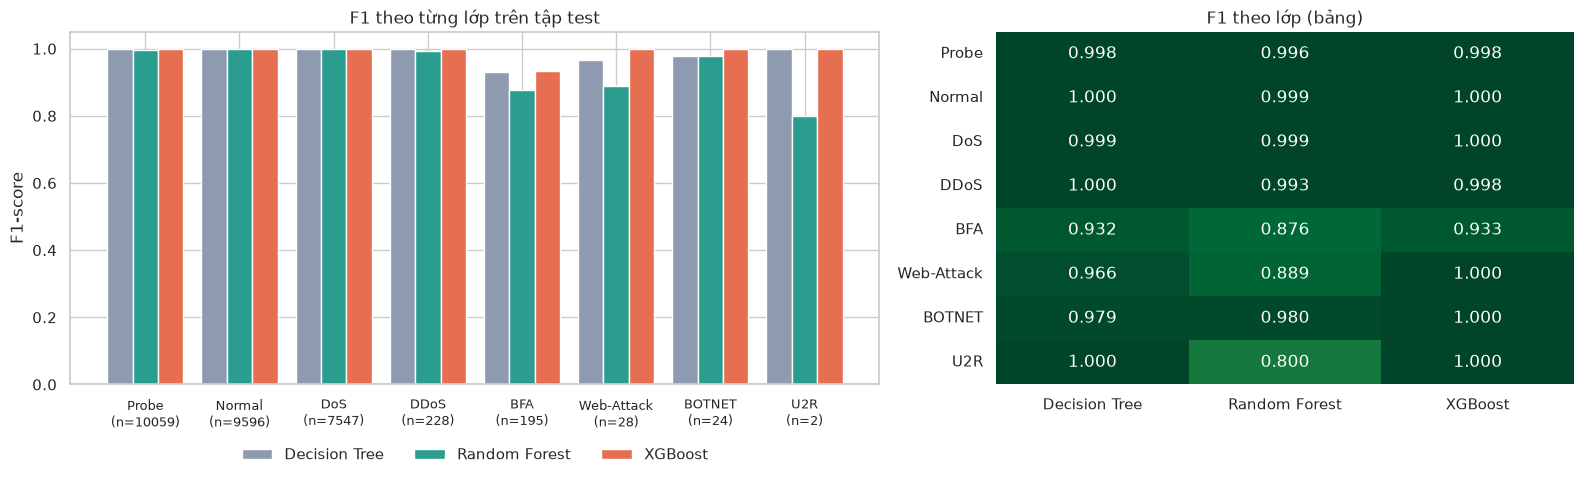

In [19]:
# F1 từng lớp của ba mô hình (bài toán 8 lớp)
per_class = pd.DataFrame({
    name: f1_score(Y["multi"]["test"], FINAL["multi"][name]["pred"], average=None,
                   labels=np.arange(len(CLASS_NAMES)), zero_division=0)
    for name in MODEL_NAMES
}, index=CLASS_NAMES)
support = pd.Series(np.bincount(Y["multi"]["test"], minlength=len(CLASS_NAMES)), index=CLASS_NAMES)
per_class = per_class.loc[support.sort_values(ascending=False).index]

fig, axes = plt.subplots(1, 2, figsize=(16, 5), gridspec_kw={"width_ratios": [1.4, 1]})
x = np.arange(len(per_class))
for i, name in enumerate(MODEL_NAMES):
    axes[0].bar(x + (i - 1) * 0.27, per_class[name], width=0.27, label=name, color=MODEL_COLORS[name])
axes[0].set_xticks(x, [f"{c}\n(n={support[c]})" for c in per_class.index], fontsize=9)
axes[0].set_ylim(0, 1.05)
axes[0].set_ylabel("F1-score")
axes[0].set_title("F1 theo từng lớp trên tập test")
axes[0].legend(loc="upper center", bbox_to_anchor=(0.5, -0.14), ncol=3, frameon=False)

sns.heatmap(per_class, annot=True, fmt=".3f", cmap="YlGn", vmin=0, vmax=1, ax=axes[1], cbar=False)
axes[1].set_title("F1 theo lớp (bảng)")
plt.tight_layout()
plt.show()

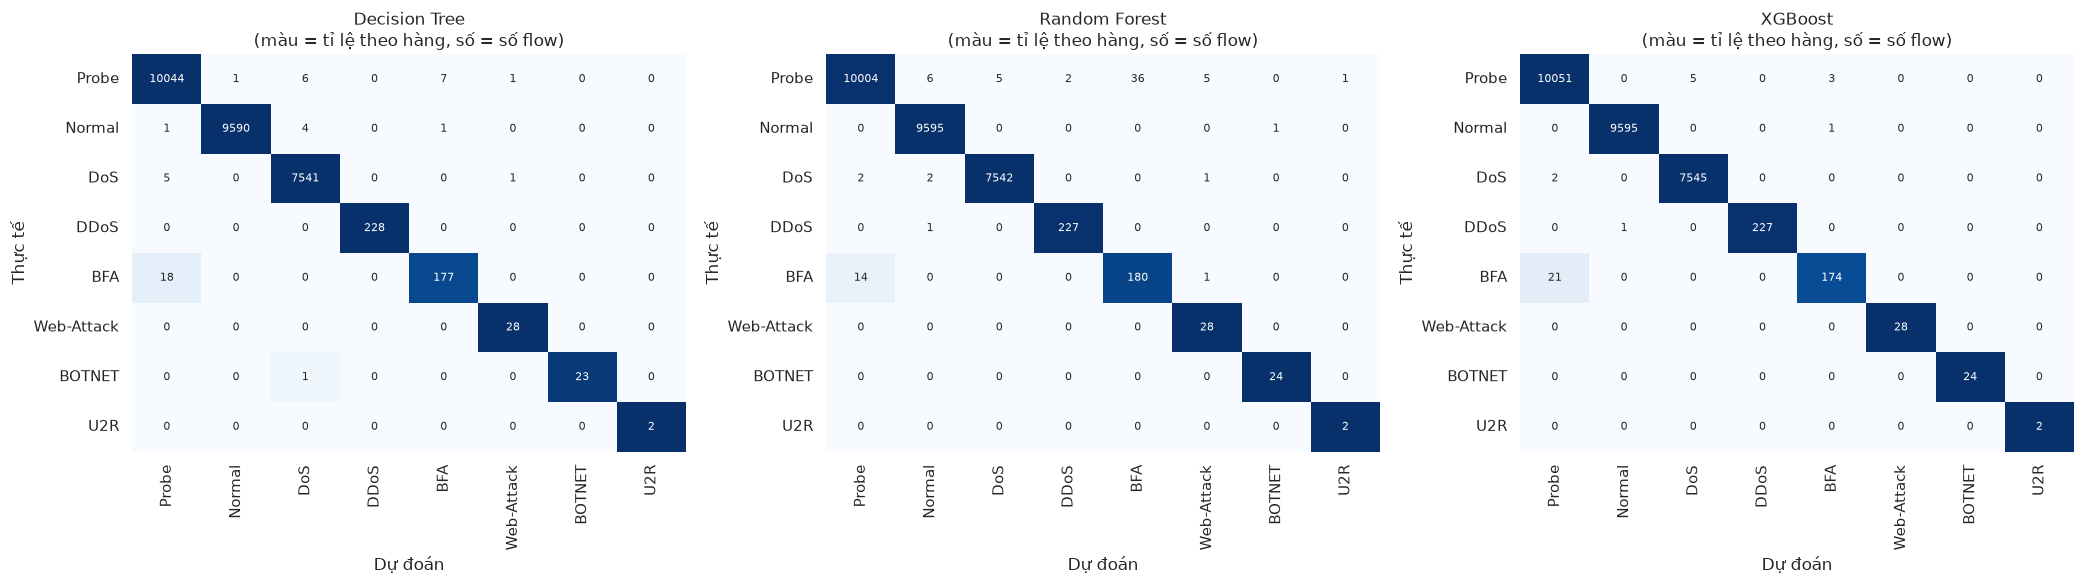

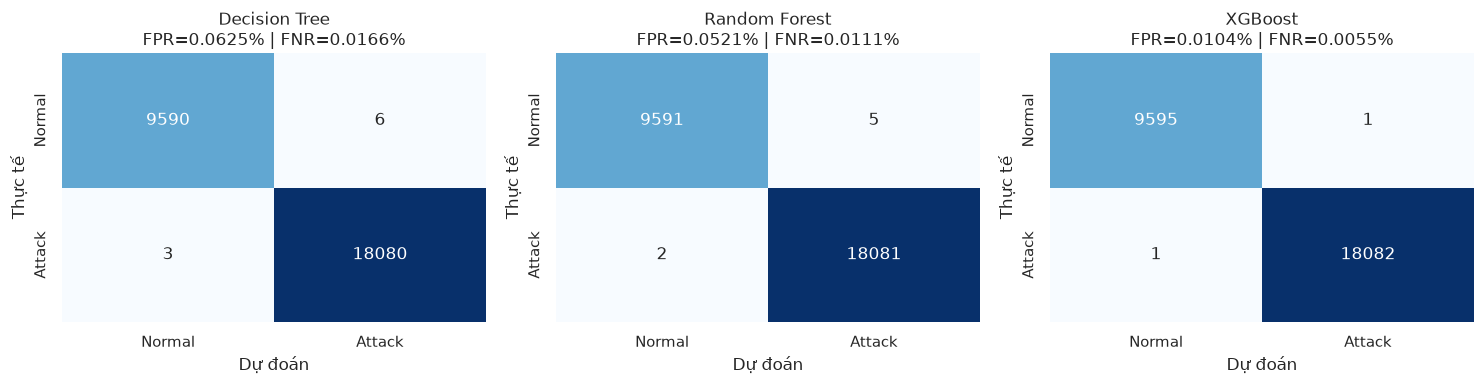

In [20]:
# Ma trận nhầm lẫn — bài toán 8 lớp (chuẩn hóa theo hàng = recall từng lớp)
order_idx = [CLASS_NAMES.index(c) for c in per_class.index]
fig, axes = plt.subplots(1, 3, figsize=(21, 6))
for ax, name in zip(axes, MODEL_NAMES):
    cm = confusion_matrix(Y["multi"]["test"], FINAL["multi"][name]["pred"], labels=order_idx)
    cm_norm = cm / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=cm, fmt="d", cmap="Blues", vmin=0, vmax=1, cbar=False, ax=ax,
                xticklabels=per_class.index, yticklabels=per_class.index, annot_kws={"size": 8})
    ax.set_title(f"{name}\n(màu = tỉ lệ theo hàng, số = số flow)")
    ax.set_xlabel("Dự đoán")
    ax.set_ylabel("Thực tế")
plt.tight_layout()
plt.show()

# Ma trận nhầm lẫn — bài toán nhị phân
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, name in zip(axes, MODEL_NAMES):
    cm = confusion_matrix(Y["binary"]["test"], FINAL["binary"][name]["pred"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["Normal", "Attack"], yticklabels=["Normal", "Attack"])
    fpr = cm[0, 1] / cm[0].sum()
    fnr = cm[1, 0] / cm[1].sum()
    ax.set_title(f"{name}\nFPR={fpr:.4%} | FNR={fnr:.4%}")
    ax.set_xlabel("Dự đoán")
    ax.set_ylabel("Thực tế")
plt.tight_layout()
plt.show()

**Nhận xét từ báo cáo từng lớp và ma trận nhầm lẫn:**

- **Normal, DoS, Probe, DDoS:** F1 ≥ 0,99 với cả ba mô hình. Nhầm lẫn giữa Normal và các lớp tấn công chỉ ở mức vài luồng trên ~9.600.
- **BFA ↔ Probe là nguồn lỗi lớn nhất:** số luồng BFA→Probe là 18 (Decision Tree), 14 (Random Forest) và 21 (XGBoost); Probe→BFA là 7, **36** và 3. Cặp này chiếm khoảng 54%, 65% và 73% tổng số lỗi của từng mô hình. BFA (dò mật khẩu SSH/FTP/đăng nhập web) và Probe (quét cổng) đều sinh các luồng TCP ngắn, 1–2 gói trả về, không có payload, nên gần như không phân biệt được ở mức một luồng (khớp với nhận xét EDA và với 157 vector Probe/BFA mâu thuẫn nhãn ở mục 4.1).
- **Hướng của lỗi BFA ↔ Probe do trọng số lớp quyết định, không do thuật toán.** XGBoost (không trọng số) nghiêng về đoán Probe: Recall BFA 0,89 nhưng Precision 0,98. Random Forest (`balanced_subsample`) nghiêng ngược lại: Recall BFA 0,92 nhưng 36 luồng Probe bị gán thành BFA (Precision 0,83). Decision Tree cũng dùng `balanced` nhưng ít bị ảnh hưởng (Probe→BFA chỉ 7), vì cây phát triển tối đa có lá gần như thuần nhất: khi lá chỉ chứa một lớp, nhân trọng số không làm đổi lớp có xác suất lớn nhất. Đây là đánh đổi Precision/Recall điển hình của class weights.
- **Web-Attack, BOTNET:** F1 từ 0,89 đến 1,0 dù chỉ có 24–28 mẫu test. Random Forest thấp nhất ở Web-Attack (0,89) vì báo nhầm 7 luồng thành Web-Attack.
- **U2R (2 mẫu):** cả ba mô hình nhận ra cả 2 mẫu; Random Forest báo nhầm thêm 1 luồng thành U2R. Với 2 mẫu, không thể kết luận gì có ý nghĩa thống kê cho lớp này.
- **Nhị phân:** FPR (báo động giả) 0,01–0,06%, FNR (bỏ lọt) 0,006–0,017%.

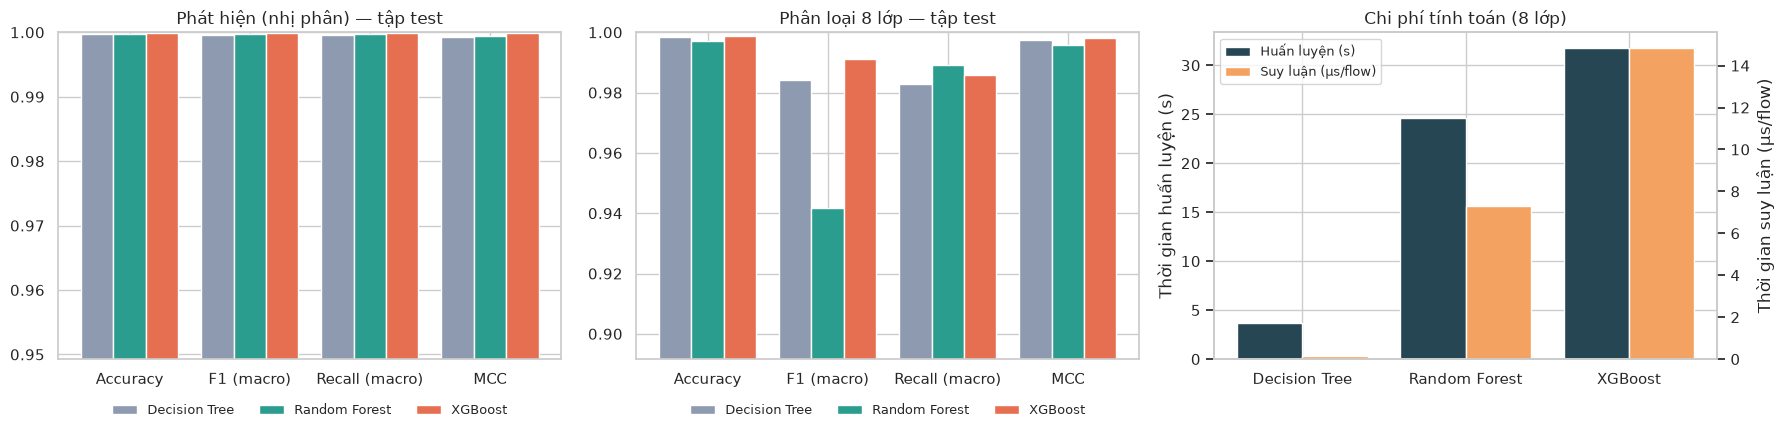

In [21]:
# Biểu đồ tổng hợp: chất lượng và chi phí tính toán
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
for ax, task, title in [(axes[0], "binary", "Phát hiện (nhị phân)"), (axes[1], "multi", "Phân loại 8 lớp")]:
    sub = results[results["bài toán"] == task].set_index("mô hình")
    metrics = ["Accuracy", "F1 (macro)", "Recall (macro)", "MCC"]
    x = np.arange(len(metrics))
    for i, name in enumerate(MODEL_NAMES):
        vals = sub.loc[name, metrics].to_numpy(dtype=float)
        ax.bar(x + (i - 1) * 0.27, vals, width=0.27, color=MODEL_COLORS[name], label=name)
    ax.set_xticks(x, metrics)
    lo = float(sub[metrics].min().min())
    ax.set_ylim(max(0, lo - 0.05), 1.0)
    ax.set_title(f"{title} — tập test")
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=3, fontsize=9, frameon=False)

sub = results[results["bài toán"] == "multi"].set_index("mô hình")
ax = axes[2]
ax.bar(np.arange(3) - 0.2, sub["Huấn luyện (s)"], width=0.4, color="#264653", label="Huấn luyện (s)")
ax2 = ax.twinx()
ax2.bar(np.arange(3) + 0.2, sub["Suy luận (µs/flow)"], width=0.4, color="#F4A261", label="Suy luận (µs/flow)")
ax.set_xticks(range(3), MODEL_NAMES)
ax.set_ylabel("Thời gian huấn luyện (s)")
ax2.set_ylabel("Thời gian suy luận (µs/flow)")
ax2.grid(False)
ax.set_title("Chi phí tính toán (8 lớp)")
h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

**Nhận xét:** ở bài toán nhị phân, ba cột gần như bằng nhau trên mọi độ đo. Ở bài toán 8 lớp, Accuracy và MCC gần như không phân biệt được ba mô hình (0,996–0,999), trong khi F1-macro tách Random Forest (0,94) ra khỏi hai mô hình còn lại vì nó báo nhầm nhiều sang lớp hiếm. Đây là minh họa trực quan cho lập luận ở mục 6.2: Accuracy che khuất hoàn toàn chất lượng trên lớp hiếm. Về chi phí, Decision Tree huấn luyện nhanh hơn các ensemble khoảng 7–9 lần (bài toán 8 lớp) và suy luận nhanh hơn khoảng 100–220 lần trên cùng 1 luồng CPU.

### 6.4 So sánh với đường cơ sở

Hai mốc tham chiếu: (i) `DummyClassifier` luôn dự đoán lớp phổ biến nhất trong train; (ii) Decision Tree với tham số mặc định — đường cơ sở "học máy đơn giản nhất".

In [22]:
# Đường cơ sở: luôn dự đoán lớp phổ biến nhất (DummyClassifier) và Decision Tree mặc định.
# Cùng dữ liệu huấn luyện với các mô hình chính (train + val).
rows, DT0 = [], {}
for task in ["binary", "multi"]:
    dummy = DummyClassifier(strategy="most_frequent").fit(X_trval, Y[task]["trval"])
    res, _, _ = evaluate(dummy, X_test, Y[task]["test"], task)
    rows.append({"bài toán": task, "mô hình": "Dummy (lớp phổ biến nhất)", **res})
    dt0, _ = fit_model("Decision Tree", task, X_trval, Y[task]["trval"])
    res, DT0[task], _ = evaluate(dt0, X_test, Y[task]["test"], task)
    rows.append({"bài toán": task, "mô hình": "Decision Tree mặc định (baseline)", **res})
    for name in MODEL_NAMES:
        r = results[(results["bài toán"] == task) & (results["mô hình"] == name)].iloc[0].to_dict()
        r["mô hình"] = f"{name} (đã tinh chỉnh)"
        rows.append({k: v for k, v in r.items() if k != "Huấn luyện (s)"})

baseline_df = pd.DataFrame(rows)
cols = ["bài toán", "mô hình", "Accuracy", "F1 (macro)", "F1 (macro, trừ U2R)", "Recall (macro)", "MCC", "ROC-AUC"]
display(baseline_df[cols].set_index(["bài toán", "mô hình"]))

# Bằng chứng: các mẫu U2R trong tập test được mỗi mô hình dự đoán thành gì
u2r = np.where(Y["multi"]["test"] == CLASS_NAMES.index("U2R"))[0]
u2r_pred = {"Decision Tree mặc định": DT0["multi"][u2r]}
u2r_pred.update({f"{n} (đã tinh chỉnh)": FINAL["multi"][n]["pred"][u2r] for n in MODEL_NAMES})
display(pd.DataFrame({k: label_encoder.inverse_transform(v) for k, v in u2r_pred.items()},
                     index=[f"U2R #{i+1}" for i in range(len(u2r))]).T)


Accuracy  F1 (macro)  \
bài toán mô hình                                                   
binary   Dummy (lớp phổ biến nhất)            0.6533      0.3952   
         Decision Tree mặc định (baseline)    0.9997      0.9996   
         Decision Tree (đã tinh chỉnh)        0.9997      0.9996   
         Random Forest (đã tinh chỉnh)        0.9997      0.9997   
         XGBoost (đã tinh chỉnh)              0.9999      0.9999   
multi    Dummy (lớp phổ biến nhất)            0.3634      0.0666   
         Decision Tree mặc định (baseline)    0.9984      0.9865   
         Decision Tree (đã tinh chỉnh)        0.9983      0.9840   
         Random Forest (đã tinh chỉnh)        0.9972      0.9416   
         XGBoost (đã tinh chỉnh)              0.9988      0.9911   

                                            F1 (macro, trừ U2R)  \
bài toán mô hình                                                  
binary   Dummy (lớp phổ biến nhất)                          NaN   
         Decision Tree mặc định (baseline)                  NaN   
         Decision Tree (đã tinh chỉnh)                      NaN   
         Random Forest (đã tinh chỉnh)                      NaN   
         XGBoost (đã tinh chỉnh)                            NaN   
multi    Dummy (lớp phổ biến nhất)                       0.0762   
         Decision Tree mặc định (baseline)               0.9846   
         Decision Tree (đã tinh chỉnh)                   0.9818   
         Random Forest (đã tinh chỉnh)                   0.9619   
         XGBoost (đã tinh chỉnh)                         0.9898   

                                            Recall (macro)    MCC  ROC-AUC  
bài toán mô hình                                                            
binary   Dummy (lớp phổ biến nhất)                  0.5000 0.0000   0.5000  
         Decision Tree mặc định (baseline)          0.9996 0.9993   0.9996  
         Decision Tree (đã tinh chỉnh)              0.9996 0.9993   0.9996  
         Random Forest (đã tinh chỉnh)              0.9997 0.9994   1.0000  
         XGBoost (đã tinh chỉnh)                    0.9999 0.9998   1.0000  
multi    Dummy (lớp phổ biến nhất)                  0.1250 0.0000   0.5000  
         Decision Tree mặc định (baseline)          0.9882 0.9977   0.9940  
         Decision Tree (đã tinh chỉnh)              0.9829 0.9975   0.9913  
         Random Forest (đã tinh chỉnh)              0.9891 0.9959   0.9999  
         XGBoost (đã tinh chỉnh)                    0.9858 0.9982   0.9999

,U2R #1,U2R #2
Decision Tree mặc định,U2R,U2R
Decision Tree (đã tinh chỉnh),U2R,U2R
Random Forest (đã tinh chỉnh),U2R,U2R
XGBoost (đã tinh chỉnh),U2R,U2R


**Nhận xét:**

- `Dummy` đạt Accuracy 0,65 (nhị phân) và 0,36 (8 lớp) nhưng MCC = 0 và F1-macro rất thấp (0,40 và 0,07). Đây là mốc cho thấy mọi mô hình học máy ở trên đều học được tín hiệu thật, không phải đoán theo tần suất.
- **Decision Tree mặc định** (cây phát triển tối đa, không trọng số) đạt F1-macro 8 lớp 0,9865 (43 lỗi), **nhỉnh hơn** cây đã tinh chỉnh (0,9840, 46 lỗi). Cấu hình `balanced` thắng trong CV 3-fold (0,940 so với 0,916) nhưng thua 3 luồng trên test, một chênh lệch nằm trong nhiễu. Cả hai cây đều nhận đúng 2/2 mẫu U2R. Như vậy với Decision Tree, lợi ích của tinh chỉnh nhỏ hơn độ nhiễu của chính bước chọn mô hình.
- So với đường cơ sở học máy đơn giản (DT mặc định): **XGBoost đã tinh chỉnh tốt hơn** (0,9911, 33 lỗi), còn **Random Forest đã tinh chỉnh kém hơn** (0,9416, 77 lỗi). Ensemble không tự động tốt hơn cây đơn; kết quả phụ thuộc mạnh vào cấu hình, đặc biệt là trọng số lớp (mục 5.4, 6.3). Mục 7.2 kiểm tra các chênh lệch này bằng kiểm định thống kê và 5-fold CV.

## 7. Phân tích và thảo luận

### 7.1 Phân tích kết quả

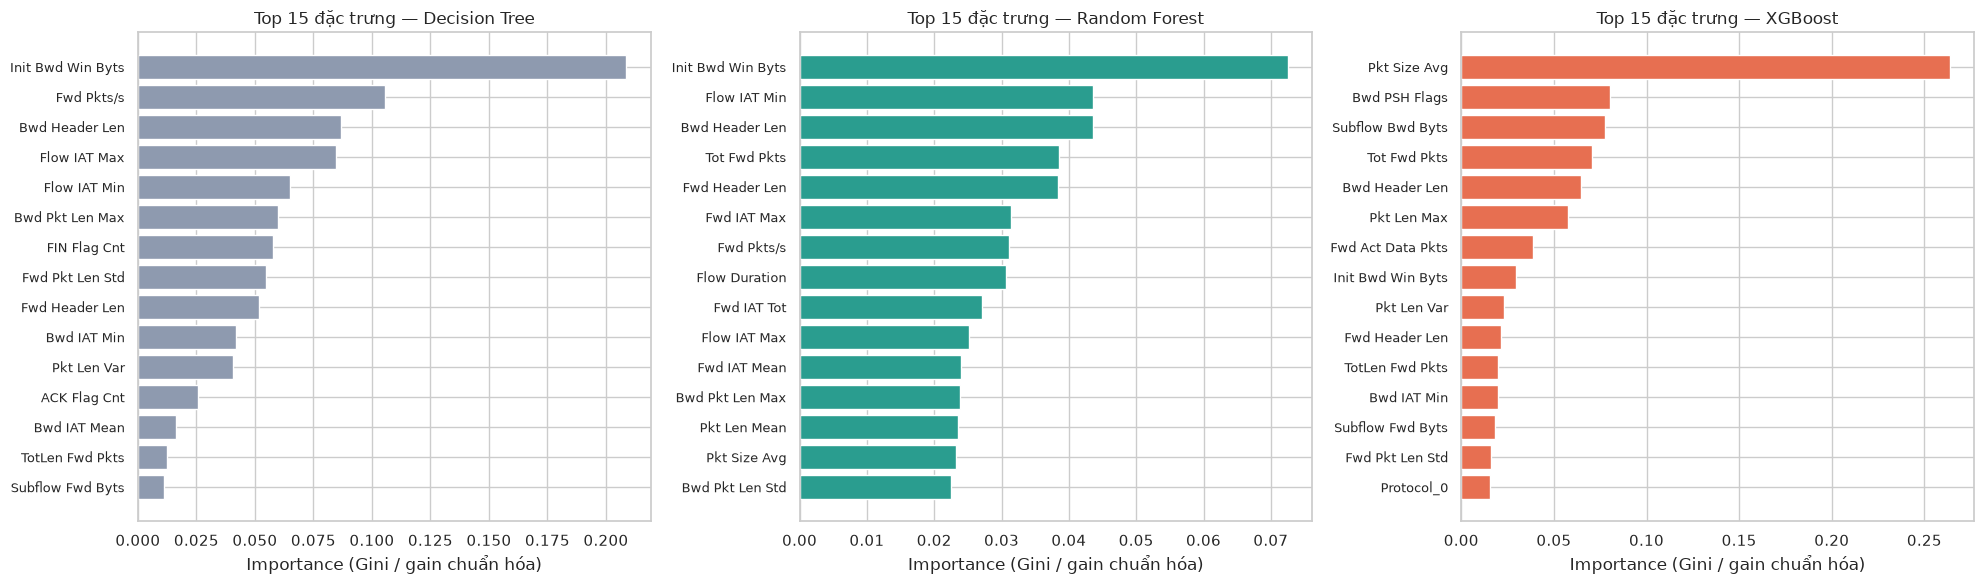

Đặc trưng nằm trong top-10 của cả 3 mô hình: ['Bwd Header Len', 'Fwd Header Len', 'Init Bwd Win Byts']


In [23]:
# Mức độ quan trọng của đặc trưng (bài toán 8 lớp)
imp = pd.DataFrame({
    "Decision Tree": FINAL["multi"]["Decision Tree"]["model"].feature_importances_,
    "Random Forest": FINAL["multi"]["Random Forest"]["model"].feature_importances_,
    "XGBoost": FINAL["multi"]["XGBoost"]["model"].feature_importances_,
}, index=X_train.columns)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, name in zip(axes, MODEL_NAMES):
    top = imp[name].sort_values(ascending=True).tail(15)
    ax.barh(top.index, top.values, color=MODEL_COLORS[name])
    ax.set_title(f"Top 15 đặc trưng — {name}")
    ax.set_xlabel("Importance (Gini / gain chuẩn hóa)")
    ax.tick_params(axis="y", labelsize=9)
plt.tight_layout()
plt.show()

# Mức độ đồng thuận: các đặc trưng nằm trong top-10 của cả ba mô hình
top10 = {n: set(imp[n].nlargest(10).index) for n in MODEL_NAMES}
print("Đặc trưng nằm trong top-10 của cả 3 mô hình:", sorted(set.intersection(*top10.values())))

In [24]:
# Các cặp nhầm lẫn phổ biến nhất (thực tế -> dự đoán), bài toán 8 lớp
rows = []
for name in MODEL_NAMES:
    cm = confusion_matrix(Y["multi"]["test"], FINAL["multi"][name]["pred"], labels=np.arange(len(CLASS_NAMES)))
    np.fill_diagonal(cm, 0)
    for i, j in zip(*np.unravel_index(np.argsort(cm, axis=None)[::-1][:5], cm.shape)):
        if cm[i, j] > 0:
            rows.append({"mô hình": name, "thực tế": CLASS_NAMES[i], "dự đoán": CLASS_NAMES[j], "số flow": int(cm[i, j])})
display(pd.DataFrame(rows))

# Tổng số lỗi mỗi mô hình
print({n: int((FINAL["multi"][n]["pred"] != Y["multi"]["test"]).sum()) for n in MODEL_NAMES},
      "lỗi trên", len(Y["multi"]["test"]), "flow test")

,mô hình,thực tế,dự đoán,số flow
0,Decision Tree,BFA,Probe,18
1,Decision Tree,Probe,BFA,7
2,Decision Tree,Probe,DoS,6
3,Decision Tree,DoS,Probe,5
4,Decision Tree,Normal,DoS,4
5,Random Forest,Probe,BFA,36
6,Random Forest,BFA,Probe,14
7,Random Forest,Probe,Normal,6
8,Random Forest,Probe,Web-Attack,5
9,Random Forest,Probe,DoS,5


{'Decision Tree': 46, 'Random Forest': 77, 'XGBoost': 33} lỗi trên 27679 flow test


**Phân tích:**

1. **Mô hình hoạt động tốt ở đâu?** Mọi mô hình đều gần như hoàn hảo trong việc tách Normal khỏi Attack và nhận diện các tấn công dạng khối lượng lớn (DoS, DDoS; F1 ≥ 0,99). Các tấn công này để lại "dấu vân tay" rõ trên đặc trưng luồng, đặc biệt DDoS: thời lượng cực ngắn, tốc độ gói cực cao, không payload, giao thức đặc thù.
2. **Kém ở đâu?** (a) Cặp **BFA ↔ Probe**: 24–50 lỗi trên 27.679 luồng, chiếm khoảng 54–73% tổng số lỗi tùy mô hình, do hai loại tấn công trông giống nhau ở mức một luồng (kết nối TCP ngắn, ít gói, không payload). Ngay trong dữ liệu đã có 157 dòng (80 Probe + 77 BFA) mà vector đặc trưng trùng nhau nhưng nhãn khác nhau (mục 4.1). Phân biệt chúng cần ngữ cảnh *nhiều luồng* (ví dụ cùng một IP gửi hàng trăm lần tới cùng cổng 22 là brute-force, tới nhiều cổng khác nhau là quét cổng), thứ mà mô hình theo từng luồng không có. (b) **Lớp hiếm khi dùng trọng số lớp:** Random Forest báo nhầm sang BFA/Web-Attack/U2R (mục 6.3). (c) **U2R**: quá ít mẫu (17 luồng) để học và để đánh giá.
3. **Đặc trưng quan trọng:** ba đặc trưng `Init Bwd Win Byts`, `Bwd Header Len`, `Fwd Header Len` nằm trong top-10 của **cả ba** mô hình. Chúng thuộc nhóm header/TCP: kích thước cửa sổ TCP ban đầu của phía trả lời và tổng độ dài header phản ánh trực tiếp luồng có hoàn tất bắt tay và mang dữ liệu thật hay chỉ là gói thăm dò/điều khiển. Cách phân bố importance rất khác nhau giữa ba mô hình:
   - **Decision Tree** dồn khoảng 40% importance vào 3 đặc trưng (`Init Bwd Win Byts` ~0,21, `Fwd Pkts/s` ~0,11, `Bwd Header Len` ~0,09): một bộ luật tương đối gọn, dễ giải thích nhưng "mong manh".
   - **Random Forest** trải đều importance ra hàng chục đặc trưng (đặc trưng lớn nhất chỉ ~7%), nhờ cơ chế chọn ngẫu nhiên tập con đặc trưng ở mỗi nút.
   - **XGBoost** (importance theo gain) tập trung vào nhóm độ dài gói: `Pkt Size Avg` (~0,26), sau đó là `Bwd PSH Flags` và `Subflow Bwd Byts` (~0,08 mỗi đặc trưng).
   - Ngoài nhóm header/TCP chung, các mô hình đi theo những "con đường" khác nhau trên cùng một tập đặc trưng tương quan mạnh. Do đó không nên diễn giải importance của một mô hình đơn lẻ như "đặc trưng quan trọng nhất của tấn công".
   - *Lưu ý về phương pháp:* importance ở đây là MDI (tổng độ giảm Gini, với DT/RF) và gain (với XGBoost), đều tính trên **dữ liệu huấn luyện**. Các độ đo này có thiên lệch đã biết: ưu tiên đặc trưng liên tục có nhiều giá trị khác nhau, và chia nhỏ importance giữa các đặc trưng tương quan mạnh. Vì vậy chúng chỉ nên dùng để mô tả mô hình, không phải để kết luận nhân quả. Permutation importance trên tập test hoặc SHAP là lựa chọn chặt chẽ hơn (mục 8.2).
4. **Không có đặc trưng định danh nào** (IP/Port/Timestamp) trong danh sách, vì đã bị loại có chủ đích. Kết quả phản ánh hành vi luồng chứ không phải topo mạng của phòng lab.

### 7.2 Kiểm tra độ tin cậy của kết quả

Năm kiểm tra: (1) overfitting — so sánh train/val/test; (2) độ ổn định — 5-fold cross-validation; (3) rò rỉ do trùng lặp — chạy lại trên dữ liệu không khử trùng; (4) tổng quát hóa — train trên tấn công ghi nhận ở OVS, test trên tấn công ghi nhận ở Metasploitable-2; (5) kiểm định thống kê McNemar và bootstrap cho các giả thuyết H1–H3.

In [25]:
# (1) Overfitting: so sánh F1-macro trên dữ liệu huấn luyện (train + val) và trên tập test
rows = []
for task in ["binary", "multi"]:
    for name in MODEL_NAMES:
        m = FINAL[task][name]["model"]
        row = {"bài toán": task, "mô hình": name,
               "F1-macro huấn luyện (train+val)": f1_score(Y[task]["trval"], m.predict(X_trval), average="macro"),
               "F1-macro test": f1_score(Y[task]["test"], FINAL[task][name]["pred"], average="macro")}
        row["chênh huấn luyện - test"] = row["F1-macro huấn luyện (train+val)"] - row["F1-macro test"]
        if task == "multi":
            f_tr = f1_score(Y[task]["trval"], m.predict(X_trval), labels=KEEP7, average="macro")
            f_te = f1_score(Y[task]["test"], FINAL[task][name]["pred"], labels=KEEP7, average="macro")
            row["chênh huấn luyện - test (trừ U2R)"] = f_tr - f_te
        rows.append(row)
display(pd.DataFrame(rows).set_index(["bài toán", "mô hình"]))


F1-macro huấn luyện (train+val)  F1-macro test  \
bài toán mô hình                                                         
binary   Decision Tree                           1.0000         0.9996   
         Random Forest                           0.9999         0.9997   
         XGBoost                                 1.0000         0.9999   
multi    Decision Tree                           1.0000         0.9840   
         Random Forest                           0.9726         0.9416   
         XGBoost                                 0.9962         0.9911   

                        chênh huấn luyện - test  \
bài toán mô hình                                  
binary   Decision Tree                   0.0004   
         Random Forest                   0.0001   
         XGBoost                         0.0001   
multi    Decision Tree                   0.0160   
         Random Forest                   0.0310   
         XGBoost                         0.0051   

                        chênh huấn luyện - test (trừ U2R)  
bài toán mô hình                                           
binary   Decision Tree                                NaN  
         Random Forest                                NaN  
         XGBoost                                      NaN  
multi    Decision Tree                             0.0182  
         Random Forest                             0.0115  
         XGBoost                                   0.0058

In [26]:
# (2) Độ ổn định: 5-fold stratified cross-validation trên (train + val) với cấu hình tốt nhất, bài toán 8 lớp
#     (dùng seed chia fold khác với lúc tinh chỉnh). Gộp dự đoán out-of-fold để mọi mẫu hiếm (15 U2R, 140 BOTNET...)
#     đều được đánh giá đúng một lần.
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED + 1)

cv_rows, oof, cv_scores = [], {}, {}
for name in MODEL_NAMES:
    scores, scores7 = [], []
    oof[name] = np.empty_like(y_trval_multi)
    for tr, te in skf.split(X_trval, y_trval_multi):
        m, _ = fit_model(name, "multi", X_trval.iloc[tr], y_trval_multi[tr], **BEST_PARAMS["multi"][name])
        p = m.predict(X_trval.iloc[te])
        oof[name][te] = p
        scores.append(f1_score(y_trval_multi[te], p, average="macro"))
        scores7.append(f1_score(y_trval_multi[te], p, labels=KEEP7, average="macro"))
    cv_scores[name] = {"8 lớp": np.array(scores), "trừ U2R": np.array(scores7)}
    cv_rows.append({"mô hình": name, "F1-macro TB": np.mean(scores), "độ lệch chuẩn": np.std(scores, ddof=1),
                    "min": np.min(scores), "max": np.max(scores),
                    "F1-macro TB (trừ U2R)": np.mean(scores7), "độ lệch chuẩn (trừ U2R)": np.std(scores7, ddof=1)})
cv_df = pd.DataFrame(cv_rows).set_index("mô hình")
display(cv_df)

# F1 từng lớp tính trên toàn bộ dự đoán out-of-fold (157 nghìn luồng)
oof_f1 = pd.DataFrame({n: f1_score(y_trval_multi, oof[n], average=None) for n in MODEL_NAMES}, index=CLASS_NAMES)
oof_f1["số mẫu"] = np.bincount(y_trval_multi)
display(oof_f1.sort_values("số mẫu", ascending=False))
# Kiểm định GHÉP CẶP trên điểm từng fold (các mô hình dùng cùng 5 fold):
# corrected resampled t-test (Nadeau & Bengio, 2003) — hiệu chỉnh phương sai vì các tập train giữa các fold chồng lấn:
#   t = mean(d) / sqrt((1/k + n_test/n_train) * var(d)),  bậc tự do k - 1
def holm(pvals):
    # Hiệu chỉnh Holm-Bonferroni cho nhiều phép so sánh
    pvals = np.asarray(pvals, dtype=float)
    order = np.argsort(pvals)
    adj, running = np.empty(len(pvals)), 0.0
    for rank, i in enumerate(order):
        running = max(running, min(1.0, (len(pvals) - rank) * pvals[i]))
        adj[i] = running
    return adj

assert np.allclose(holm([0.01, 0.04, 0.03]), [0.03, 0.06, 0.06])   # ví dụ tính tay: 3·0,01; max(2·0,03; 1·0,04)

k_folds, ratio = 5, (1 / 4)          # n_test / n_train = 1/4 với 5-fold
paired_rows = []
for metric in ["8 lớp", "trừ U2R"]:
    block = []
    for a, b_ in combinations(MODEL_NAMES, 2):
        d = cv_scores[a][metric] - cv_scores[b_][metric]
        se = np.sqrt((1 / k_folds + ratio) * d.var(ddof=1))
        t_stat = d.mean() / se if se > 0 else 0.0
        p = 2 * t_dist.sf(abs(t_stat), df=k_folds - 1)
        block.append({"F1-macro": metric, "so sánh (A − B)": f"{a} − {b_}", "Δ TB": d.mean(),
                      "số fold A > B": int((d > 0).sum()), "t": t_stat, "p-value": p})
    for r, p_adj in zip(block, holm([r["p-value"] for r in block])):
        r["p (Holm)"] = p_adj
        r["có ý nghĩa (α=0,05)"] = "có" if p_adj < 0.05 else "không"
    paired_rows += block
display(pd.DataFrame(paired_rows).set_index(["F1-macro", "so sánh (A − B)"]))


,F1-macro TB,độ lệch chuẩn,min,max,F1-macro TB (trừ U2R),độ lệch chuẩn (trừ U2R)
mô hình,,,,,,
Decision Tree,0.9544,0.0313,0.9106,0.9874,0.9802,0.0041
Random Forest,0.9363,0.0369,0.8859,0.9745,0.9615,0.0077
XGBoost,0.9619,0.0291,0.9273,0.9928,0.9898,0.0023


,Decision Tree,Random Forest,XGBoost,số mẫu
Probe,0.9975,0.9963,0.9984,56996
Normal,0.9995,0.9995,0.9998,54377
DoS,0.9989,0.9990,0.9993,42762
DDoS,0.9961,0.9919,0.9969,1292
BFA,0.8993,0.8585,0.9409,1105
Web-Attack,0.9775,0.9015,0.9968,155
BOTNET,0.9929,0.9823,0.9964,140
U2R,0.7857,0.7586,0.7857,15


Δ TB  số fold A > B       t  \
F1-macro so sánh (A − B)                                                
8 lớp    Decision Tree − Random Forest  0.0180              3  0.8529   
         Decision Tree − XGBoost       -0.0075              1 -0.2986   
         Random Forest − XGBoost       -0.0256              1 -0.9490   
trừ U2R  Decision Tree − Random Forest  0.0187              5  2.5342   
         Decision Tree − XGBoost       -0.0095              0 -4.1096   
         Random Forest − XGBoost       -0.0283              0 -4.8831   

                                        p-value  p (Holm) có ý nghĩa (α=0,05)  
F1-macro so sánh (A − B)                                                       
8 lớp    Decision Tree − Random Forest   0.4418    1.0000               không  
         Decision Tree − XGBoost         0.7801    1.0000               không  
         Random Forest − XGBoost         0.3963    1.0000               không  
trừ U2R  Decision Tree − Random Forest   0.0644    0.0644               không  
         Decision Tree − XGBoost         0.0147    0.0295                  có  
         Random Forest − XGBoost         0.0081    0.0244                  có

In [27]:
# (3) Ảnh hưởng của dữ liệu trùng lặp: lặp lại thí nghiệm trên dữ liệu KHÔNG khử trùng lặp.
#     Chia 85% train / 15% test — cùng tỉ lệ dữ liệu huấn luyện với thí nghiệm chính (train + val = 85%).
df_dup = df_raw.drop(columns=ID_COLS + constant_cols + identical_cols)
df_dup = df_dup[df_dup["Flow Duration"] >= 0].reset_index(drop=True)
df_dup[clip_cols] = df_dup[clip_cols].clip(lower=0)
y_dup = label_encoder.transform(df_dup["Label"])
i_tr, i_te = train_test_split(np.arange(len(df_dup)), test_size=0.15, random_state=SEED, stratify=y_dup)
prep_dup = ProtocolEncoder().fit(df_dup.iloc[i_tr])
Xd_tr, Xd_te = prep_dup.transform(df_dup.iloc[i_tr]), prep_dup.transform(df_dup.iloc[i_te])

# Flow test có bản sao y hệt (đặc trưng + nhãn) trong train
# (so khớp bằng băm 64-bit từng dòng, nhanh và nhẹ hơn nhiều so với tập tuple Python)
seen = np.isin(row_hash(Xd_te.assign(_y=y_dup[i_te])), row_hash(Xd_tr.assign(_y=y_dup[i_tr])))
print(f"Không khử trùng: {seen.mean():.1%} flow trong tập test đã xuất hiện y hệt trong tập train")
display(pd.DataFrame({"flow test": pd.Series(label_encoder.inverse_transform(y_dup[i_te])).value_counts(),
                      "% đã thấy trong train": pd.Series(seen).groupby(label_encoder.inverse_transform(y_dup[i_te])).mean() * 100}))

rows = []
for name in MODEL_NAMES:
    m, _ = fit_model(name, "multi", Xd_tr, y_dup[i_tr], **BEST_PARAMS["multi"][name])
    p = m.predict(Xd_te)
    yt = y_dup[i_te]
    rows.append({"mô hình": name,
                 "Accuracy (toàn bộ test)": accuracy_score(yt, p),
                 "Accuracy (flow ĐÃ thấy)": accuracy_score(yt[seen], p[seen]),
                 "Accuracy (flow CHƯA thấy)": accuracy_score(yt[~seen], p[~seen]),
                 "F1-macro (toàn bộ test)": f1_score(yt, p, average="macro"),
                 "F1-macro (flow CHƯA thấy)": f1_score(yt[~seen], p[~seen], average="macro"),
                 "F1-macro thí nghiệm chính (đã khử trùng)": results[(results["bài toán"] == "multi") &
                                                                    (results["mô hình"] == name)]["F1 (macro)"].iloc[0]})
display(pd.DataFrame(rows).set_index("mô hình"))


Không khử trùng: 49.5% flow trong tập test đã xuất hiện y hệt trong tập train


,flow test,% đã thấy trong train
BFA,211,4.2654
BOTNET,25,0.0000
DDoS,18292,99.2456
DoS,8042,8.3561
Normal,10262,7.9906
Probe,14720,40.0068
U2R,2,0.0000
Web-Attack,29,0.0000


,Accuracy (toàn bộ test),Accuracy (flow ĐÃ thấy),Accuracy (flow CHƯA thấy),F1-macro (toàn bộ test),F1-macro (flow CHƯA thấy),F1-macro thí nghiệm chính (đã khử trùng)
mô hình,,,,,,
Decision Tree,0.9982,0.9998,0.9967,0.9038,0.9036,0.9840
Random Forest,0.9965,0.9981,0.9949,0.9059,0.9130,0.9416
XGBoost,0.9991,1.0000,0.9982,0.9609,0.9606,0.9911


In [28]:
# (4) Khả năng tổng quát hóa sang kịch bản tấn công khác (bài toán phát hiện nhị phân)
#     Train: Normal (70%) + tấn công ghi nhận trên OVS.csv
#     Test : Normal (30% còn lại) + tấn công ghi nhận trên metasploitable-2.csv (mô hình chưa từng thấy môi trường này)
is_normal = df["Label"] == "Normal"
normal_idx = np.where(is_normal)[0]
n_tr, n_te = train_test_split(normal_idx, test_size=0.30, random_state=SEED)
ovs_idx = np.where(~is_normal & (df["__source_file"] == "OVS.csv"))[0]
meta_idx = np.where(~is_normal & (df["__source_file"] == "metasploitable-2.csv"))[0]
cs_tr, cs_te = np.concatenate([n_tr, ovs_idx]), np.concatenate([n_te, meta_idx])

prep_cs = ProtocolEncoder().fit(df.iloc[cs_tr])
Xc_tr, Xc_te = prep_cs.transform(df.iloc[cs_tr]), prep_cs.transform(df.iloc[cs_te])
yc_tr, yc_te = y_bin_all[cs_tr], y_bin_all[cs_te]
print("Train:", pd.Series(df["Label"].iloc[cs_tr]).value_counts().to_dict())
print("Test :", pd.Series(df["Label"].iloc[cs_te]).value_counts().to_dict())

rows, CS_PRED = [], {}
for name in MODEL_NAMES:
    m, _ = fit_model(name, "binary", Xc_tr, yc_tr, **BEST_PARAMS["binary"][name])
    res, pred, _ = evaluate(m, Xc_te, yc_te, "binary")
    CS_PRED[name] = pred
    test_labels = df["Label"].iloc[cs_te].to_numpy()
    det = {f"Detection rate {c}": (pred[test_labels == c] == 1).mean()
           for c in ["DDoS", "DoS", "Probe", "BFA", "U2R"] if (test_labels == c).any()}
    rows.append({"mô hình": name, "F1 (macro)": res["F1 (macro)"], "Recall Attack": recall_score(yc_te, pred),
                 "FPR Normal": (pred[yc_te == 0] == 1).mean(), **det})
cross_df = pd.DataFrame(rows).set_index("mô hình")
display(cross_df)
# Độ ổn định của kết quả chéo môi trường: lặp lại với 5 seed khác nhau
# (mỗi seed đổi cả cách chia Normal 70/30 lẫn seed ngẫu nhiên của mô hình)
rep_rows = []
for seed in [0, 1, 2, 3, 4]:
    n_tr_s, n_te_s = train_test_split(normal_idx, test_size=0.30, random_state=seed)
    tr_s, te_s = np.concatenate([n_tr_s, ovs_idx]), np.concatenate([n_te_s, meta_idx])
    prep_s = ProtocolEncoder().fit(df.iloc[tr_s])
    Xs_tr, Xs_te = prep_s.transform(df.iloc[tr_s]), prep_s.transform(df.iloc[te_s])
    for name in MODEL_NAMES:
        m, _ = fit_model(name, "binary", Xs_tr, y_bin_all[tr_s], seed=seed, **BEST_PARAMS["binary"][name])
        p = m.predict(Xs_te)
        rep_rows.append({"seed": seed, "mô hình": name, "F1 (macro)": f1_score(y_bin_all[te_s], p, average="macro"),
                         "Recall Attack": recall_score(y_bin_all[te_s], p)})
rep_df = pd.DataFrame(rep_rows)
display(rep_df.groupby("mô hình")[["F1 (macro)", "Recall Attack"]].agg(["mean", "std", "min", "max"]))
display(rep_df.pivot(index="seed", columns="mô hình", values="F1 (macro)").round(4))


Train: {'DoS': 49445, 'Normal': 44781, 'Probe': 21542, 'BFA': 1084, 'Web-Attack': 183, 'BOTNET': 164, 'DDoS': 94}
Test : {'Probe': 45513, 'Normal': 19192, 'DDoS': 1426, 'DoS': 864, 'BFA': 216, 'U2R': 17}


,F1 (macro),Recall Attack,FPR Normal,Detection rate DDoS,Detection rate DoS,Detection rate Probe,Detection rate BFA,Detection rate U2R
mô hình,,,,,,,,
Decision Tree,0.9775,0.9742,0.0009,0.9853,0.7708,0.9777,0.9907,0.9412
Random Forest,0.9908,0.9895,0.0004,0.8394,0.7396,0.9990,0.9954,0.8824
XGBoost,0.9966,0.9962,0.0002,0.9902,0.8079,0.9999,1.0000,0.9412


F1 (macro)                      Recall Attack                \
                    mean    std    min    max          mean    std    min   
mô hình                                                                     
Decision Tree     0.9702 0.0258 0.9259 0.9932        0.9650 0.0316 0.9106   
Random Forest     0.9781 0.0251 0.9344 0.9948        0.9742 0.0304 0.9211   
XGBoost           0.9964 0.0004 0.9958 0.9969        0.9959 0.0005 0.9953   

                      
                 max  
mô hình               
Decision Tree 0.9926  
Random Forest 0.9942  
XGBoost       0.9965

mô hình,Decision Tree,Random Forest,XGBoost
seed,,,
0,0.9802,0.9344,0.9958
1,0.9772,0.9916,0.9969
2,0.9745,0.9948,0.9962
3,0.9259,0.9798,0.9965
4,0.9932,0.9900,0.9966


In [29]:
# (5) Kiểm định thống kê: các chênh lệch giữa mô hình có ý nghĩa hay chỉ do ngẫu nhiên?
def mcnemar(y, pred_a, pred_b):
    # b: A đúng & B sai ; c: A sai & B đúng. Exact binomial nếu b + c < 25, ngược lại chi2 có hiệu chỉnh liên tục
    ok_a, ok_b = pred_a == y, pred_b == y
    b, c = int(np.sum(ok_a & ~ok_b)), int(np.sum(~ok_a & ok_b))
    if b + c == 0:
        return b, c, 1.0
    if b + c < 25:
        return b, c, binomtest(min(b, c), b + c, 0.5).pvalue
    stat = (abs(b - c) - 1) ** 2 / (b + c)
    return b, c, float(chi2.sf(stat, df=1))

# Kiểm tra nhanh: A sai 5 mẫu mà B đúng, không có trường hợp ngược lại -> exact p = 2·0,5^5 = 0,0625
assert mcnemar(np.zeros(5), np.ones(5), np.zeros(5)) == (0, 5, 0.0625)

# holm(...) đã được định nghĩa ở ô (2) phía trên

settings = {
    "A. Nhị phân (test)": (Y["binary"]["test"], {n: FINAL["binary"][n]["pred"] for n in MODEL_NAMES}),
    "B. 8 lớp (test)": (Y["multi"]["test"], {n: FINAL["multi"][n]["pred"] for n in MODEL_NAMES}),
    "C. OVS -> Metasploitable-2": (yc_te, CS_PRED),
}
rows = []
for setting, (y, preds) in settings.items():
    block = []
    for a, b_ in combinations(MODEL_NAMES, 2):
        b, c, p = mcnemar(y, preds[a], preds[b_])
        block.append({"thiết lập": setting, "so sánh": f"{a} vs {b_}", "số lỗi A": int((preds[a] != y).sum()),
                      "số lỗi B": int((preds[b_] != y).sum()), "b (A đúng, B sai)": b, "c (A sai, B đúng)": c,
                      "p-value": p})
    for r, p_adj in zip(block, holm(np.array([r["p-value"] for r in block]))):
        r["p (Holm)"] = p_adj
        r["có ý nghĩa (α=0,05)"] = "có" if p_adj < 0.05 else "không"
    rows += block
mcnemar_df = pd.DataFrame(rows).set_index(["thiết lập", "so sánh"])
pd.set_option("display.float_format", lambda v: f"{v:,.4g}")
display(mcnemar_df)

# Bootstrap PHÂN TẦNG có ghép cặp (B = 1000): rút lại có hoàn lại BÊN TRONG từng lớp (theo nhãn 8 lớp),
# nên mọi lần rút đều giữ đúng số mẫu mỗi lớp (U2R luôn có 2 mẫu) và F1-macro luôn tính trên cùng tập lớp.
# Cùng chỉ số mẫu được dùng cho cả ba mô hình (ghép cặp).
rng = np.random.default_rng(SEED)
B = 1000
strata = [np.where(Y["multi"]["test"] == k)[0] for k in range(len(CLASS_NAMES))]
metrics = {
    "A. Nhị phân — F1-macro": ("binary", [0, 1]),
    "B. 8 lớp — F1-macro": ("multi", list(range(len(CLASS_NAMES)))),
    "B. 8 lớp — F1-macro (trừ U2R)": ("multi", KEEP7),
}
boot_rows = []
for label, (task, labels) in metrics.items():
    y = Y[task]["test"]
    preds = {n: FINAL[task][n]["pred"] for n in MODEL_NAMES}
    samples = {n: np.empty(B) for n in MODEL_NAMES}
    for i in range(B):
        idx = np.concatenate([rng.choice(g, size=len(g), replace=True) for g in strata])
        for n in MODEL_NAMES:
            samples[n][i] = f1_score(y[idx], preds[n][idx], labels=labels, average="macro", zero_division=0)
    for n in MODEL_NAMES:
        point = f1_score(y, preds[n], labels=labels, average="macro", zero_division=0)
        boot_rows.append({"độ đo": label, "mô hình / chênh lệch": n, "ước lượng": point,
                          "CI 2,5%": np.percentile(samples[n], 2.5), "CI 97,5%": np.percentile(samples[n], 97.5)})
    for a, b_ in [("Random Forest", "Decision Tree"), ("XGBoost", "Decision Tree"), ("XGBoost", "Random Forest")]:
        d = samples[a] - samples[b_]
        lo, hi = np.percentile(d, [2.5, 97.5])
        row = {"độ đo": label, "mô hình / chênh lệch": f"Δ {a} − {b_}",
               "ước lượng": f1_score(y, preds[a], labels=labels, average="macro", zero_division=0)
                            - f1_score(y, preds[b_], labels=labels, average="macro", zero_division=0),
               "CI 2,5%": lo, "CI 97,5%": hi,
               "CI chứa 0?": "có" if lo <= 0 <= hi else "không"}
        if task == "binary":   # TOST cho H1: tương đương nếu CI nằm trọn trong (−δ, +δ)
            lo90, hi90 = np.percentile(d, [5, 95])
            row["TOST: CI 90% ⊂ ±δ?"] = "có" if -EQ_MARGIN < lo90 and hi90 < EQ_MARGIN else "không"
            row["CI 95% ⊂ ±δ?"] = "có" if -EQ_MARGIN < lo and hi < EQ_MARGIN else "không"
        boot_rows.append(row)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
display(pd.DataFrame(boot_rows).set_index(["độ đo", "mô hình / chênh lệch"]).fillna(""))

số lỗi A  số lỗi B  \
thiết lập                  so sánh                                              
A. Nhị phân (test)         Decision Tree vs Random Forest         9         7   
                           Decision Tree vs XGBoost               9         2   
                           Random Forest vs XGBoost               7         2   
B. 8 lớp (test)            Decision Tree vs Random Forest        46        77   
                           Decision Tree vs XGBoost              46        33   
                           Random Forest vs XGBoost              77        33   
C. OVS -> Metasploitable-2 Decision Tree vs Random Forest      1255       509   
                           Decision Tree vs XGBoost            1255       188   
                           Random Forest vs XGBoost             509       188   

                                                           b (A đúng, B sai)  \
thiết lập                  so sánh                                             
A. Nhị phân (test)         Decision Tree vs Random Forest                  4   
                           Decision Tree vs XGBoost                        0   
                           Random Forest vs XGBoost                        0   
B. 8 lớp (test)            Decision Tree vs Random Forest                 51   
                           Decision Tree vs XGBoost                        8   
                           Random Forest vs XGBoost                        9   
C. OVS -> Metasploitable-2 Decision Tree vs Random Forest                370   
                           Decision Tree vs XGBoost                      139   
                           Random Forest vs XGBoost                        8   

                                                           c (A sai, B đúng)  \
thiết lập                  so sánh                                             
A. Nhị phân (test)         Decision Tree vs Random Forest                  6   
                           Decision Tree vs XGBoost                        7   
                           Random Forest vs XGBoost                        5   
B. 8 lớp (test)            Decision Tree vs Random Forest                 20   
                           Decision Tree vs XGBoost                       21   
                           Random Forest vs XGBoost                       53   
C. OVS -> Metasploitable-2 Decision Tree vs Random Forest               1116   
                           Decision Tree vs XGBoost                     1206   
                           Random Forest vs XGBoost                      329   

                                                            p-value  \
thiết lập                  so sánh                                    
A. Nhị phân (test)         Decision Tree vs Random Forest    0.7539   
                           Decision Tree vs XGBoost         0.01562   
                           Random Forest vs XGBoost          0.0625   
B. 8 lớp (test)            Decision Tree vs Random Forest 0.0003704   
                           Decision Tree vs XGBoost         0.02586   
                           Random Forest vs XGBoost       4.734e-08   
C. OVS -> Metasploitable-2 Decision Tree vs Random Forest 3.233e-83   
                           Decision Tree vs XGBoost       9.46e-186   
                           Random Forest vs XGBoost       4.757e-68   

                                                            p (Holm)  \
thiết lập                  so sánh                                     
A. Nhị phân (test)         Decision Tree vs Random Forest     0.7539   
                           Decision Tree vs XGBoost          0.04688   
                           Random Forest vs XGBoost            0.125   
B. 8 lớp (test)            Decision Tree vs Random Forest  0.0007407   
                           Decision Tree vs XGBoost          0.02586   
                           Random Forest vs XGBoost         1.42e-07   
C. OVS -> Metasploitable-2 Decision Tree vs Ran

ước lượng  \
độ đo                         mô hình / chênh lệch                         
A. Nhị phân — F1-macro        Decision Tree                       0.9996   
                              Random Forest                       0.9997   
                              XGBoost                             0.9999   
                              Δ Random Forest − Decision Tree     0.0001   
                              Δ XGBoost − Decision Tree           0.0003   
                              Δ XGBoost − Random Forest           0.0002   
B. 8 lớp — F1-macro           Decision Tree                       0.9840   
                              Random Forest                       0.9416   
                              XGBoost                             0.9911   
                              Δ Random Forest − Decision Tree    -0.0424   
                              Δ XGBoost − Decision Tree           0.0070   
                              Δ XGBoost − Random Forest           0.0494   
B. 8 lớp — F1-macro (trừ U2R) Decision Tree                       0.9818   
                              Random Forest                       0.9619   
                              XGBoost                             0.9898   
                              Δ Random Forest − Decision Tree    -0.0199   
                              Δ XGBoost − Decision Tree           0.0080   
                              Δ XGBoost − Random Forest           0.0279   

                                                               CI 2,5%  \
độ đo                         mô hình / chênh lệch                       
A. Nhị phân — F1-macro        Decision Tree                     0.9994   
                              Random Forest                     0.9995   
                              XGBoost                           0.9998   
                              Δ Random Forest − Decision Tree  -0.0002   
                              Δ XGBoost − Decision Tree         0.0001   
                              Δ XGBoost − Random Forest         0.0000   
B. 8 lớp — F1-macro           Decision Tree                     0.9754   
                              Random Forest                     0.9075   
                              XGBoost                           0.9873   
                              Δ Random Forest − Decision Tree  -0.0779   
                              Δ XGBoost − Decision Tree        -0.0004   
                              Δ XGBoost − Random Forest         0.0165   
B. 8 lớp — F1-macro (trừ U2R) Decision Tree                     0.9707   
                              Random Forest                     0.9487   
                              XGBoost                           0.9857   
                              Δ Random Forest − Decision Tree  -0.0347   
                              Δ XGBoost − Decision Tree         0.0000   
                              Δ XGBoost − Random Forest         0.0154   

                                                               CI 97,5%  \
độ đo                         mô hình / chênh lệch                        
A. Nhị phân — F1-macro        Decision Tree                      0.9998   
                              Random Forest                      0.9999   
                              XGBoost                            1.0000   
                              Δ Random Forest − Decision Tree    0.0004   
                              Δ XGBoost − Decision Tree          0.0005   
                              Δ XGBoost − Random Forest          0.0004   
B. 8 lớp — F1-macro           Decision Tree                      0.9915   
                              Random Forest                      0.9759   
                              XGBoost                            0.9942   
                              Δ Random Forest − Decision Tree   -0.0076   
                              Δ XGBoost − Decision Tree          0.0158   
                              Δ XGBoost − Random Forest          0.0829   
B. 8 lớp — 

**Kết quả kiểm tra độ tin cậy:**

**(1) Overfitting** (so sánh dữ liệu đã học — train + val — với tập test):

- **Nhị phân:** chênh lệch ≤ 0,0004, không có dấu hiệu overfit.
- **8 lớp, tính đủ 8 lớp:** khoảng cách là Random Forest 0,031 > Decision Tree 0,016 > XGBoost 0,005. **Bỏ U2R:** Decision Tree 0,018, Random Forest 0,012, XGBoost 0,006.
- **Decision Tree** (phát triển tối đa) đạt F1 = 1,000 trên **mọi** lớp của dữ liệu đã học: nó học thuộc tập huấn luyện. Khoảng cách tới test (~0,02) tập trung ở BFA (1,00 → 0,93) và Web-Attack (1,00 → 0,97). Đây là overfit đúng như lý thuyết dự đoán cho cây sâu (phương sai cao, mục 5.1.1), dù mức độ vừa phải vì các lớp lớn rất dễ tách.
- **Random Forest** không đạt điểm tuyệt đối ngay trên dữ liệu đã học (F1-macro 0,973; BFA 0,92, Web-Attack 0,91) vì `min_samples_leaf=3` cùng trọng số lớp làm nó báo nhầm sang lớp hiếm cả trên train. Vấn đề của RF ở đây là **Precision lớp hiếm do trọng số**, không phải học thuộc.
- **XGBoost** có khoảng cách nhỏ nhất (0,005): shrinkage $\eta = 0{,}1$, cây nông (sâu 6), chuẩn hóa $\lambda$ và lấy mẫu con dòng/cột kiểm soát phương sai đúng như thiết kế.
- **Kết luận:** không mô hình nào overfit nghiêm trọng; XGBoost tổng quát hóa tốt nhất trong cùng phân phối.

**(2) Độ ổn định (5-fold CV trên train + val).** *(Vì cấu hình được chọn bằng CV trên chính dữ liệu này (với cách chia fold khác), kết quả hơi lạc quan. Nó dùng để đo **độ ổn định** và để so sánh ghép cặp, không thay thế tập test. "F1-macro trừ U2R" là độ đo bổ sung được đặt ra **sau khi** thấy U2R chi phối kết quả; chúng tôi luôn báo cáo song song với F1-macro đầy đủ 8 lớp.)* F1-macro 8 lớp dao động mạnh giữa các fold (độ lệch chuẩn 0,029–0,037; min–max từ ~0,89 đến ~0,99), chủ yếu do U2R (mỗi fold chỉ có 3 mẫu). **Khi bỏ U2R, độ lệch chuẩn giảm 4–13 lần (0,002–0,008)**: XGBoost 0,9898 ± 0,0023, Decision Tree 0,9802 ± 0,0041, Random Forest 0,9615 ± 0,0077.

Kiểm định **t ghép cặp đã hiệu chỉnh** (Nadeau–Bengio [12], Holm) trên điểm từng fold:

- Với F1-macro đầy đủ 8 lớp: **không cặp nào khác nhau có ý nghĩa** (p_Holm = 1,0); phương sai do U2R lấn át mọi chênh lệch.
- Khi bỏ U2R: **XGBoost cao hơn Decision Tree ở 5/5 fold** (Δ = +0,0095, p_Holm = 0,030) và **cao hơn Random Forest ở 5/5 fold** (Δ = +0,028, p_Holm = 0,024), cả hai có ý nghĩa. Decision Tree cao hơn Random Forest ở 5/5 fold (Δ = +0,019) nhưng p_Holm = 0,064, chưa đủ ý nghĩa sau hiệu chỉnh.
- F1 từng lớp trên toàn bộ dự đoán out-of-fold (157 nghìn luồng): XGBoost tốt nhất hoặc ngang bằng ở mọi lớp, rõ nhất ở BFA (0,94, so với DT 0,90 và RF 0,86), Web-Attack (0,997) và BOTNET (0,996). Random Forest yếu nhất ở BFA (0,86) và Web-Attack (0,90), khớp với vấn đề Precision do trọng số lớp ở mục 6.3.

**(3) Ảnh hưởng của trùng lặp.** Lặp lại thí nghiệm trên dữ liệu không khử trùng lặp, chia 85% train / 15% test (cùng lượng dữ liệu huấn luyện với thí nghiệm chính), cùng cấu hình tốt nhất:

- **49,5% luồng trong tập test đã xuất hiện y hệt trong tập train.** Tỉ lệ này rất khác nhau giữa các lớp: DDoS 99,2%, Probe 40%, DoS và Normal ~8%, BFA 4%, các lớp hiếm 0%.
- Trên phần test "đã thấy", mô hình gần như chỉ tra bảng: Accuracy 1,000 (XGBoost), 0,9998 (DT) và 0,998 (RF). Trên phần "chưa thấy", Accuracy là 0,995–0,998, và F1-macro trên phần chưa thấy gần bằng F1-macro trên toàn bộ test.
- Như vậy **trên InSDN, mức thổi phồng do trùng lặp đo được là nhỏ** (khoảng 0,09–0,16 điểm phần trăm Accuracy), vì phần bị trùng chủ yếu là DDoS, lớp vốn đã rất dễ nhận ra. Tác động lớn hơn nằm ở **cơ cấu dữ liệu**: dữ liệu gốc làm DDoS trông như lớp lớn nhất (35%), trong khi thực chất chỉ có ~1.500 mẫu hành vi khác nhau; và gần một nửa tập test không kiểm tra được khả năng nhận diện luồng mới.
- F1-macro của thí nghiệm này (0,90–0,96) không so sánh trực tiếp được với thí nghiệm chính (0,94–0,99) vì tập test khác nhau (khác phân bố lớp, và các lớp hiếm có số mẫu test khác).
- Kết luận: khử trùng lặp không làm thay đổi đáng kể các con số trên InSDN, nhưng là điều kiện cần để con số đo được thật sự là khả năng nhận diện luồng mới. Các kết quả ~99,9% báo cáo trên InSDN nên được đọc kèm câu hỏi: dữ liệu đã được khử trùng lặp hay chưa, và khử trên biểu diễn nào (mục 4.1: `float64` hay `float32`).

**(4) Tổng quát hóa sang kịch bản khác (OVS → Metasploitable-2).** Mô hình nhị phân được huấn luyện trên Normal (70%) + các tấn công ghi nhận ở môi trường OVS, và kiểm tra trên Normal (30% còn lại) + các tấn công nhắm vào máy Metasploitable-2. Mô hình chưa thấy môi trường này; tập test còn có 17 luồng U2R, loại tấn công chưa từng xuất hiện trong train. Lưu ý: vì khử trùng lặp giữ bản ghi xuất hiện trước (file OVS được đọc trước), các vector tấn công giống hệt nhau ở cả hai file chỉ nằm ở phía train, nên tập test hoàn toàn không trùng với train. Tập test có 45.513/67.228 luồng là Probe, nên kết quả chủ yếu phản ánh khả năng nhận ra Probe. Kết quả với `SEED = 42`:

| Mô hình | F1-macro | Recall Attack | FPR Normal |
|---|---|---|---|
| Decision Tree | 0,978 | 0,974 | 0,09% |
| Random Forest | 0,991 | 0,990 | 0,04% |
| **XGBoost** | **0,997** | **0,996** | 0,02% |

Với seed này, Decision Tree bỏ lọt 2,6% tấn công (23% DoS, 2% Probe, 1 trong 17 U2R); Random Forest bỏ lọt 16% DDoS, 26% DoS và 2/17 U2R; XGBoost phát hiện 99,6% tấn công, kể cả **16/17 luồng U2R chưa từng thấy**. Điểm yếu chung của cả ba là DoS trên Metasploitable-2 (Recall ≤ 0,81), cho thấy vẫn còn khoảng cách phân phối giữa hai môi trường.

**Lặp lại với 5 seed khác** (đổi cả cách chia Normal lẫn seed của mô hình):

| Mô hình | F1-macro TB ± độ lệch chuẩn | min – max |
|---|---|---|
| Decision Tree | 0,970 ± 0,026 | 0,926 – 0,993 |
| Random Forest | 0,978 ± 0,025 | 0,934 – 0,995 |
| **XGBoost** | **0,996 ± 0,0004** | 0,996 – 0,997 |

(i) **XGBoost tốt nhất ở cả 6 lần chạy** (seed 42 và 5 seed trên), và gần như không đổi giữa các seed. (ii) Trung bình, Decision Tree và Random Forest khá gần nhau (0,970 so với 0,978); Random Forest cao hơn ở 4/6 lần chạy. Mỗi mô hình đều có những lần chạy kém bất thường (DT 0,926 với seed 3; RF 0,934 với seed 0), nên một lần chạy duy nhất có thể cho kết luận sai về DT và RF. (iii) Điều thực sự phân biệt các mô hình là **độ ổn định**: độ lệch chuẩn của DT và RF lớn hơn XGBoost khoảng 60 lần. Đây là biểu hiện của phương sai cao (mục 5.1.1): ngưỡng mà cây học được phụ thuộc mạnh vào mẫu huấn luyện, và có lần bám vào đặc điểm riêng của môi trường OVS.

**(5) Kiểm định thống kê (McNemar + Holm, bootstrap phân tầng 95% CI, TOST).**

| Thiết lập | So sánh | Số lỗi A / B | $b$ / $c$ | p (Holm) | Kết luận |
|---|---|---|---|---|---|
| A. Nhị phân | DT vs RF | 9 / 7 | 4 / 6 | 0,75 | không khác biệt |
| A. Nhị phân | DT vs XGB | 9 / 2 | 0 / 7 | 0,047 | **XGB ít lỗi hơn** |
| A. Nhị phân | RF vs XGB | 7 / 2 | 0 / 5 | 0,13 | không khác biệt |
| B. 8 lớp | DT vs RF | 46 / 77 | 51 / 20 | < 0,001 | **DT ít lỗi hơn** |
| B. 8 lớp | DT vs XGB | 46 / 33 | 8 / 21 | 0,026 | **XGB ít lỗi hơn** |
| B. 8 lớp | RF vs XGB | 77 / 33 | 9 / 53 | < 0,001 | **XGB ít lỗi hơn** |
| C. OVS → Metasploitable-2 (seed 42) | DT vs RF | 1.255 / 509 | 370 / 1.116 | < 0,001 | RF tốt hơn |
| C. OVS → Metasploitable-2 (seed 42) | DT vs XGB | 1.255 / 188 | 139 / 1.206 | < 0,001 | **XGB tốt hơn** |
| C. OVS → Metasploitable-2 (seed 42) | RF vs XGB | 509 / 188 | 8 / 329 | < 0,001 | **XGB tốt hơn** |

($b$ = A đúng, B sai; $c$ = A sai, B đúng.)

Khoảng tin cậy bootstrap phân tầng 95% trên tập test:

- **Nhị phân:** $\Delta$ RF − DT = +0,0001 [−0,0002; 0,0004], XGB − DT = +0,0003 [0,0001; 0,0005], XGB − RF = +0,0002 [0,0000; 0,0004]. **Mọi CI 90% và 95% đều nằm trọn trong biên ±0,001**, nên theo TOST ba mô hình **tương đương thực tế**. Đồng thời hai trong ba CI không chứa 0: XGBoost tốt hơn *có thể phát hiện được* về thống kê (khớp với McNemar DT vs XGB), nhưng chênh lệch chỉ là 7 luồng trên 27.679, nhỏ hơn biên tương đương khoảng 3 lần. Đây chính là tình huống mà TOST được đặt trước để xử lý: "khác biệt có ý nghĩa thống kê" không đồng nghĩa với "khác biệt có ý nghĩa vận hành".
- **8 lớp, F1-macro đầy đủ:** DT 0,984 [0,975; 0,992], RF 0,942 [0,908; 0,976], XGB 0,991 [0,987; 0,994]. $\Delta$ RF − DT = −0,042 [−0,078; −0,008] và XGB − RF = +0,049 [0,017; 0,083] **không chứa 0**; XGB − DT = +0,007 [−0,0004; 0,016] **chứa 0** (sát biên).
- **8 lớp, bỏ U2R:** DT [0,971; 0,990], RF [0,949; 0,974], XGB [0,986; 0,993]. RF − DT = −0,020 [−0,035; −0,004], XGB − RF = +0,028 [0,015; 0,041]; XGB − DT = +0,008 [0,0000; 0,019] có cận dưới dương nhưng sát 0.

**Kết luận về độ tin cậy và kiểm định giả thuyết** (giả thuyết được giữ nguyên như phát biểu trước khi chạy thí nghiệm ở mục 1.3):

- **H1 — được ủng hộ một phần.** Cả ba mô hình đạt F1-macro ≥ 0,9996, và CI bootstrap (90% lẫn 95%) của mọi chênh lệch nằm trọn trong biên tương đương ±0,001 đặt trước: **tương đương thực tế được xác lập theo TOST**. Tuy nhiên vế "không khác nhau có ý nghĩa" bị bác bỏ cho cặp DT–XGB (McNemar p_Holm = 0,047; 9 so với 2 lỗi). Với ~27.700 luồng test, ngay cả chênh lệch vài luồng cũng có thể phát hiện được, nên vế tương đương mới là tiêu chí có ý nghĩa cho quyết định triển khai.
- **H2 — được ủng hộ cho XGBoost, bị bác bỏ cho Random Forest.** XGBoost mắc ít lỗi hơn Decision Tree có ý nghĩa (33 so với 46, p_Holm = 0,026) và cao hơn DT ở 5/5 fold CV khi bỏ U2R (p_Holm = 0,030). Mức cải thiện F1-macro nhỏ (+0,007 đến +0,010), và CI bootstrap của F1-macro đầy đủ vẫn chứa 0. Ngược lại, Random Forest **kém hơn** Decision Tree có ý nghĩa (77 so với 46 lỗi, p_Holm < 0,001; CI của $\Delta$F1-macro không chứa 0), do trọng số lớp `balanced_subsample` làm giảm Precision lớp hiếm. "Ensemble tốt hơn cây đơn" vì vậy không phải tính chất của cả họ mô hình mà phụ thuộc vào cấu hình. Thêm vào đó, thứ hạng 8 lớp đã đảo chiều giữa hai lần chạy chỉ khác nhau 0,08% dữ liệu (mục 7.3), nên H2 chỉ nên được đọc như kết quả có điều kiện theo cấu hình.
- **H3 — được ủng hộ cho XGBoost, chưa đủ bằng chứng cho Random Forest.** Khi chuyển sang môi trường tấn công chưa thấy, XGBoost tốt hơn cả hai mô hình còn lại ở mọi lần chạy (McNemar p < 0,001 với seed 42; cao nhất ở 6/6 seed, với độ lệch chuẩn nhỏ hơn khoảng 60 lần). Random Forest chỉ tốt hơn Decision Tree một cách không ổn định (4/6 seed, trung bình 0,978 so với 0,970). Bằng chứng vẫn mới đến từ **một** cặp môi trường, và siêu tham số được chọn trên phép chia cùng phân phối, nên cần kiểm chứng thêm trên các cặp môi trường hoặc bộ dữ liệu khác (mục 8.2).

### 7.3 Hạn chế của đồ án

- **Một bộ dữ liệu, môi trường lab:** InSDN được sinh trong testbed ảo với lưu lượng bình thường tương đối đơn giản. Kết quả gần như hoàn hảo ở bài toán nhị phân phần nào phản ánh việc lưu lượng tấn công "sạch" và dễ tách. Chưa kiểm chứng trên lưu lượng SDN thật hoặc bộ dữ liệu khác.
- **Lớp hiếm quá nhỏ:** U2R (17 mẫu), BOTNET (164), Web-Attack (183) không đủ để đánh giá có ý nghĩa thống kê. Mọi kết luận về U2R chỉ mang tính tham khảo.
- **Nhãn gắn với file nguồn:** một số lớp chỉ có trong một môi trường (Web-Attack, BOTNET chỉ ở OVS; U2R chỉ ở Metasploitable-2), nên chưa thể kiểm tra tổng quát hóa cho mọi lớp ở bài toán 8 lớp. Thí nghiệm (4) chỉ thực hiện cho bài toán nhị phân.
- **Mỗi luồng được xét độc lập:** không khai thác ngữ cảnh nhiều luồng, trong khi đây là thông tin cần thiết để tách BFA khỏi Probe.
- **Lưới tinh chỉnh nhỏ** và chỉ 3 mô hình dựa trên cây; chưa thử LightGBM/CatBoost, mạng nơ-ron hay các phương pháp không giám sát (phát hiện tấn công zero-day).
- **Chưa triển khai thời gian thực:** thời gian suy luận được đo offline theo lô trên CPU. Chưa tính chi phí trích xuất đặc trưng (CICFlowMeter) và độ trễ do phải chờ luồng kết thúc.
- **Lựa chọn phương pháp có thể ảnh hưởng tới kết quả:**
  - Danh sách đặc trưng hằng số, cột giống hệt nhau và việc bỏ 160 vector mang nhãn mâu thuẫn được xác định trên toàn bộ dữ liệu trước khi chia. Hai bước đầu không dùng nhãn nên không gây rò rỉ; bước cuối không dùng thông tin của tập test để huấn luyện, nhưng làm tập test "sạch" hơn thực tế một chút.
  - Kiểm định McNemar và bootstrap chỉ phản ánh biến thiên do **lấy mẫu tập test** trên một lần chia; chúng không tính tới biến thiên do huấn luyện lại (seed, dữ liệu train khác). Bootstrap phân tầng còn giữ cố định cơ cấu lớp của tập test. Với lớp chỉ có 2 mẫu, không phương pháp nào có đủ độ mạnh thống kê để phát hiện khác biệt.
  - 5-fold CV chỉ có 5 cặp điểm để so sánh, nên kiểm định t ghép cặp có độ mạnh thấp.
  - Thí nghiệm chéo môi trường đã lặp với 6 seed, nhưng siêu tham số vẫn được chọn trên phép chia cùng phân phối, không tinh chỉnh lại cho kịch bản chéo môi trường.
  - **Xếp hạng 8 lớp nhạy với nhiễu nhỏ của dữ liệu.** Trong một lần chạy trước của chính notebook này, khi khử trùng lặp trên `float64` (dữ liệu chỉ khác 140 dòng, tức 0,08%), grid search chọn trọng số lớp **ngược lại** cho cả ba mô hình (DT, RF không trọng số; XGBoost có trọng số), và thứ hạng F1-macro 8 lớp trên test đảo chiều: RF 0,986 > XGB 0,955 > DT 0,944 (so với XGB 0,991 > DT 0,984 > RF 0,942 hiện tại). Hai kết luận **không đổi** giữa hai lần chạy là: ba mô hình tương đương thực tế ở bài toán nhị phân, và XGBoost tổng quát hóa tốt nhất, ổn định nhất sang Metasploitable-2 (6/6 seed ở cả hai lần). Vì vậy chúng tôi coi thứ hạng 8 lớp là kết quả *có điều kiện theo cấu hình*, không phải tính chất của thuật toán; chọn mô hình bằng nested CV hoặc CV lặp lại nhiều seed sẽ cho ước lượng ổn định hơn (mục 8.2).
  - Thời gian huấn luyện là một lần đo; thời gian suy luận là trung vị của 5 lần chạy theo lô trên một máy.
- **Chất lượng dữ liệu nguồn:** CICFlowMeter có các lỗi đã được ghi nhận [4] (ví dụ xử lý kết thúc luồng TCP chưa đúng, dẫn tới luồng bị tách hoặc gán nhãn sai). Trong dữ liệu này chúng tôi còn thấy thời lượng/IAT âm. Chúng tôi xử lý các lỗi phát hiện được nhưng không thể kiểm chứng lại nhãn gốc.

## 8. Kết luận và hướng phát triển

### 8.1 Tóm tắt đóng góp

Đồ án so sánh Decision Tree, Random Forest và XGBoost cho hai bài toán phát hiện (nhị phân) và phân loại (8 lớp) tấn công mạng SDN trên InSDN. Quy trình được thiết kế để tránh các nguồn rò rỉ phổ biến: loại bỏ định danh IP/Port/Timestamp; khử 46% bản ghi trùng lặp **trên đúng biểu diễn `float32` mà mô hình nhìn thấy** (phát hiện và loại 138 cặp chỉ trùng sau khi ép kiểu); fit encoder và trọng số lớp chỉ trên dữ liệu huấn luyện; kiểm tra rò rỉ bằng `assert`; tinh chỉnh theo F1-macro bằng validation/cross-validation; và kiểm định các giả thuyết bằng McNemar, bootstrap phân tầng, TOST và t-test ghép cặp trên CV. Kết quả chính:

1. **Phát hiện Normal/Attack:** cả ba mô hình đạt F1-macro 0,9996–0,9999 (FPR ≤ 0,06%, FNR ≤ 0,017%) và **tương đương thực tế** trong biên ±0,001 (TOST). XGBoost ít lỗi hơn Decision Tree có ý nghĩa thống kê (2 so với 9 luồng), nhưng chênh lệch này nhỏ hơn biên tương đương nhiều lần (H1 được ủng hộ một phần).
2. **Phân loại 8 lớp:** XGBoost tốt nhất trên tập test (F1-macro 0,991; 33 lỗi), tiếp theo là Decision Tree (0,984; 46 lỗi) và Random Forest (0,942; 77 lỗi). XGBoost ít lỗi hơn cả hai có ý nghĩa (McNemar) và cao hơn ở 5/5 fold CV khi bỏ U2R. Random Forest kém hơn cây đơn vì trọng số lớp làm giảm Precision lớp hiếm (H2 được ủng hộ cho XGBoost, bị bác bỏ cho RF). Nguồn lỗi chính là nhầm lẫn BFA ↔ Probe, và hướng của lỗi do trọng số lớp quyết định. **Thứ hạng 8 lớp nhạy với nhiễu dữ liệu:** một lần chạy chỉ khác 0,08% dữ liệu đã cho thứ hạng ngược lại (mục 7.3).
3. **Tổng quát hóa sang môi trường mới** là khác biệt rõ nhất và **bền vững nhất**: huấn luyện trên OVS và kiểm tra trên Metasploitable-2, XGBoost đạt F1-macro trung bình 0,996 ± 0,0004 qua 5 seed (0,997 với seed 42), so với 0,970 ± 0,026 (DT) và 0,978 ± 0,025 (RF). XGBoost tốt nhất ở mọi lần chạy, ở cả hai phiên bản dữ liệu (H3 được ủng hộ cho XGBoost); ưu thế của RF so với DT không ổn định.
4. **Chi phí:** Decision Tree suy luận nhanh hơn các ensemble khoảng 30–220 lần trên cùng 1 luồng CPU (~0,1 µs/luồng), nhưng mọi mô hình đều đủ nhanh cho suy luận theo luồng trên controller (≥ 36.000 luồng/giây trên 1 luồng CPU).

**Khuyến nghị:** dùng **XGBoost cho mô-đun phát hiện (nhị phân) trên controller SDN**. Lý do không phải vì nó chính xác hơn đáng kể trên cùng phân phối (ba mô hình tương đương thực tế), mà vì nó **tổng quát hóa tốt nhất và ổn định nhất** sang môi trường mới, với chi phí thấp (huấn luyện ~4 s, suy luận ~3,6 µs/luồng trên 1 luồng CPU). Với bài toán phân loại 8 lớp, XGBoost cũng cho kết quả tốt nhất trong lần chạy này, nhưng vì thứ hạng phụ thuộc mạnh vào lựa chọn trọng số lớp và chưa được kiểm chứng chéo môi trường, nên cần chọn cấu hình bằng CV lặp lại hoặc nested CV trước khi triển khai (mục 8.2). Decision Tree phù hợp làm bộ lọc nhanh hoặc bộ luật dễ giải thích, nhưng không nên dùng một mình khi môi trường triển khai khác môi trường huấn luyện, vì kết quả của nó dao động mạnh giữa các lần huấn luyện. Ngoài ra, các con số ~99,9% trên InSDN cần được đọc cùng với cách xử lý trùng lặp và định danh.

### 8.2 Hướng phát triển

- **Đặc trưng ngữ cảnh nhiều luồng:** thống kê theo cửa sổ thời gian cho mỗi IP nguồn (số cổng đích khác nhau, số lần kết nối tới cùng cổng...) để tách BFA khỏi Probe, lỗi còn lại chủ yếu của đồ án.
- **Đánh giá chéo bộ dữ liệu:** huấn luyện trên InSDN và kiểm tra trên các bộ dữ liệu SDN/IDS khác (ví dụ các bộ DDoS trên SDN, CIC-IDS2017 đã sửa lỗi [4]) để đo khả năng tổng quát hóa rộng hơn.
- **Xử lý lớp hiếm tốt hơn:** thu thập thêm mẫu U2R/BOTNET/Web-Attack, thử focal loss, phân loại phân cấp (Normal/Attack → nhóm tấn công → loại cụ thể), hoặc gộp các lớp quá nhỏ.
- **Phát hiện tấn công mới (zero-day):** kết hợp mô hình có giám sát với phát hiện bất thường không giám sát (Isolation Forest, autoencoder) huấn luyện chỉ trên Normal.
- **Triển khai thực tế:** tích hợp XGBoost (hoặc cây đã rút gọn) vào ứng dụng ONOS/Ryu, đo độ trễ đầu-cuối gồm cả trích xuất đặc trưng, và thử phát hiện sớm từ vài gói đầu của luồng thay vì chờ luồng kết thúc.
- **Chọn mô hình bền vững hơn:** nested cross-validation hoặc CV lặp lại với nhiều seed cho bước tinh chỉnh, và coi trọng số lớp như một siêu tham số được hiệu chỉnh theo chi phí vận hành (báo động giả so với bỏ lọt) thay vì chọn theo một điểm F1-macro, vì đây là siêu tham số quyết định thứ hạng 8 lớp (mục 7.3).
- **Giải thích mô hình:** dùng SHAP để giải thích từng cảnh báo cho quản trị viên mạng.

## 9. Đóng góp của các thành viên

| MSSV | Họ và tên | Phần đóng góp cụ thể |
|---|---|---|
| 23521404 | Phan Mạnh Tân | Trưởng nhóm; khảo sát tài liệu (mục 2); EDA và làm sạch dữ liệu (mục 3–4); tổng hợp báo cáo |
| 23521357 | Nguyễn Văn Sơn | Cài đặt Decision Tree và Random Forest; cơ sở lý thuyết và thiết kế grid search (mục 5); phân tích feature importance (mục 7.1) |
| 23521290 | Phạm Minh Quang | Cài đặt XGBoost; đánh giá trên tập test, trực quan hóa (mục 6); kiểm định thống kê và các thí nghiệm độ tin cậy (mục 7.2); chuẩn bị slide trình bày |

*Toàn bộ thành viên trong nhóm đã đọc và thống nhất nội dung báo cáo này.*

## 10. Tài liệu tham khảo

[1] M. S. Elsayed, N.-A. Le-Khac, and A. D. Jurcut, "InSDN: A Novel SDN Intrusion Dataset," *IEEE Access*, vol. 8, pp. 165263–165284, 2020, doi: 10.1109/ACCESS.2020.3022633.

[2] L. Breiman, "Random Forests," *Machine Learning*, vol. 45, no. 1, pp. 5–32, 2001, doi: 10.1023/A:1010933404324.

[3] T. Chen and C. Guestrin, "XGBoost: A Scalable Tree Boosting System," in *Proc. 22nd ACM SIGKDD Int. Conf. Knowledge Discovery and Data Mining (KDD)*, 2016, pp. 785–794, doi: 10.1145/2939672.2939785.

[4] G. Engelen, V. Rimmer, and W. Joosen, "Troubleshooting an Intrusion Detection Dataset: the CICIDS2017 Case Study," in *2021 IEEE Security and Privacy Workshops (SPW) — Workshop on Traffic Measurements for Cybersecurity (WTMC)*, 2021.

[5] D. Arp, E. Quiring, F. Pendlebury, A. Warnecke, F. Pierazzi, C. Wressnegger, L. Cavallaro, and K. Rieck, "Dos and Don'ts of Machine Learning in Computer Security," in *Proc. 31st USENIX Security Symposium*, 2022, pp. 3971–3988.

[6] InSDN Dataset (bản sao trên Kaggle), `badcodebuilder/insdn-dataset`, https://www.kaggle.com/datasets/badcodebuilder/insdn-dataset. Bản gốc: http://aseados.ucd.ie/datasets/SDN/.

[7] F. Pedregosa *et al.*, "Scikit-learn: Machine Learning in Python," *Journal of Machine Learning Research*, vol. 12, pp. 2825–2830, 2011.

[8] T. G. Dietterich, "Approximate Statistical Tests for Comparing Supervised Classification Learning Algorithms," *Neural Computation*, vol. 10, no. 7, pp. 1895–1923, 1998.

[9] S. Holm, "A Simple Sequentially Rejective Multiple Test Procedure," *Scandinavian Journal of Statistics*, vol. 6, no. 2, pp. 65–70, 1979.

[10] B. Efron and R. J. Tibshirani, *An Introduction to the Bootstrap*. New York: Chapman & Hall, 1993.

[11] J. Gorodkin, "Comparing two K-category assignments by a K-category correlation coefficient," *Computational Biology and Chemistry*, vol. 28, no. 5–6, pp. 367–374, 2004.

[12] C. Nadeau and Y. Bengio, "Inference for the Generalization Error," *Machine Learning*, vol. 52, no. 3, pp. 239–281, 2003.

[13] G. Draper-Gil, A. H. Lashkari, M. S. I. Mamun, and A. A. Ghorbani, "Characterization of Encrypted and VPN Traffic Using Time-Related Features," in *Proc. 2nd Int. Conf. Information Systems Security and Privacy (ICISSP)*, 2016, pp. 407–414. (Bài báo giới thiệu công cụ CICFlowMeter.)

[14] Q. McNemar, "Note on the sampling error of the difference between correlated proportions or percentages," *Psychometrika*, vol. 12, no. 2, pp. 153–157, 1947, doi: 10.1007/BF02295996.

[15] D. J. Schuirmann, "A comparison of the two one-sided tests procedure and the power approach for assessing the equivalence of average bioavailability," *Journal of Pharmacokinetics and Biopharmaceutics*, vol. 15, no. 6, pp. 657–680, 1987, doi: 10.1007/BF01068419.

## 11. Phụ lục

Phụ lục A: toàn bộ kết quả grid search (56 cấu hình). Phụ lục B: danh sách đặc trưng đầu vào cuối cùng. Phân tích EDA mở rộng (histogram từng đặc trưng, top IP/port, phân tích theo thời gian) nằm trong notebook `eda-insdn-dataset.ipynb` đi kèm.

In [30]:
# Phụ lục A — toàn bộ kết quả grid search
display(tuning_df.sort_values(["bài toán", "mô hình", "F1-macro (chọn mô hình)"], ascending=[True, True, False])
        .reset_index(drop=True))

# Phụ lục B — danh sách đặc trưng đầu vào cuối cùng
print(len(X_train.columns), "đặc trưng:", X_train.columns.tolist())

,bài toán,mô hình,tham số,F1-macro (chọn mô hình),train (s)
0,binary,Decision Tree,"{'class_weight': None, 'max_depth': 20, 'min_samples_leaf': 1}",0.9996,3.5917
1,binary,Decision Tree,"{'class_weight': None, 'max_depth': None, 'min_samples_leaf': 1}",0.9996,3.6383
2,binary,Decision Tree,"{'class_weight': 'balanced', 'max_depth': 20, 'min_samples_leaf': 1}",0.9996,4.1271
3,binary,Decision Tree,"{'class_weight': 'balanced', 'max_depth': None, 'min_samples_leaf': 1}",0.9996,3.6256
4,binary,Decision Tree,"{'class_weight': None, 'max_depth': 20, 'min_samples_leaf': 5}",0.9995,3.8378
5,binary,Decision Tree,"{'class_weight': None, 'max_depth': None, 'min_samples_leaf': 5}",0.9995,3.7542
6,binary,Decision Tree,"{'class_weight': 'balanced', 'max_depth': 20, 'min_samples_leaf': 5}",0.9994,4.0653
7,binary,Decision Tree,"{'class_weight': 'balanced', 'max_depth': None, 'min_samples_leaf': 5}",0.9994,3.7931
8,binary,Decision Tree,"{'class_weight': None, 'max_depth': 10, 'min_samples_leaf': 1}",0.9994,3.0894
9,binary,Decision Tree,"{'class_weight': 'balanced', 'max_depth': 10, 'min_samples_leaf': 1}",0.9992,2.8052


62 đặc trưng: ['Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts', 'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Max', 'Fwd Pkt Len Min', 'Fwd Pkt Len Mean', 'Fwd Pkt Len Std', 'Bwd Pkt Len Max', 'Bwd Pkt Len Min', 'Bwd Pkt Len Mean', 'Bwd Pkt Len Std', 'Flow Byts/s', 'Flow Pkts/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Tot', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Tot', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Bwd PSH Flags', 'Bwd URG Flags', 'Fwd Header Len', 'Bwd Header Len', 'Fwd Pkts/s', 'Bwd Pkts/s', 'Pkt Len Min', 'Pkt Len Max', 'Pkt Len Mean', 'Pkt Len Std', 'Pkt Len Var', 'FIN Flag Cnt', 'SYN Flag Cnt', 'RST Flag Cnt', 'ACK Flag Cnt', 'Down/Up Ratio', 'Pkt Size Avg', 'Bwd Seg Size Avg', 'Subflow Fwd Byts', 'Subflow Bwd Byts', 'Init Bwd Win Byts', 'Fwd Act Data Pkts', 'Active Mean', 'Active Std', 'Active Max', 'Active Min', 'Idle Mean', 'Idle Std', 'Idle Max', 'Idle Min', 'Protocol_0', 'Pro

## 12. Checklist tự đánh giá trước khi nộp

- [x] Bài toán được phát biểu rõ ràng: có đầu vào, đầu ra, và dạng bài toán cụ thể (mục 1.2)
- [x] Có mô tả nguồn dữ liệu rõ ràng, có thể kiểm chứng hoặc tái tạo lại (mục 3.2, tự tải bằng `kagglehub`)
- [x] Đã khám phá dữ liệu (EDA) và có nhận xét (mục 3.3)
- [x] Quy trình tiền xử lý hợp lý và không có rò rỉ dữ liệu giữa tập huấn luyện và tập kiểm tra (bỏ định danh, khử trùng lặp, encoder/trọng số fit trên train)
- [x] Giải thuật/mô hình được lựa chọn có lý do rõ ràng, phù hợp với bài toán (mục 5.1)
- [x] Kết quả có bảng số liệu hoặc biểu đồ minh họa, độ đo đánh giá phù hợp với bài toán (mục 6)
- [x] Có phân tích và diễn giải kết quả (mục 7.1)
- [x] Có thảo luận về độ tin cậy của kết quả (mục 7.2)
- [x] Có nêu hạn chế và hướng phát triển một cách trung thực (mục 7.3, 8.2)
- [x] Notebook chạy được từ đầu đến cuối bằng Run All mà không báo lỗi (các ô `assert` kiểm tra tự động phiên bản dữ liệu, rò rỉ dữ liệu và các hàm kiểm định)
- [x] Đóng góp của từng thành viên được ghi rõ và khớp giữa các mục (mục 9 và bảng đầu notebook)
- [x] Tài liệu tham khảo được trích dẫn đầy đủ và đúng định dạng (mục 10)
- [x] File được đặt tên đúng quy định: `NT120_DoAn_Nhom03_SoSanhML_InSDN.ipynb`

## 13. Gợi ý chuẩn bị phần trình bày trước lớp

- **Bài toán và động lực (1 slide):** SDN tập trung hóa điều khiển → controller là mục tiêu; cần IDS nhẹ, chính xác chạy cạnh controller. Câu hỏi: DT, RF hay XGBoost?
- **Dữ liệu (2 slide):** InSDN, 343 nghìn luồng, 8 nhãn mất cân bằng mạnh. Điểm nhấn: 46% bản ghi là bản sao (DDoS còn ~1%), IP/port gắn gần 1-1 với nhãn → phải bỏ định danh và khử trùng lặp.
- **Phương pháp (1–2 slide):** sơ đồ pipeline ở mục 5.2; công thức chính (Gini, Gain của XGBoost, trọng số lớp); grid search theo F1-macro (nhị phân: validation, 8 lớp: 3-fold CV).
- **Kết quả chính (2–3 slide):** bảng kết quả test hai bài toán; biểu đồ F1 theo lớp; ma trận nhầm lẫn; biểu đồ chi phí tính toán.
- **Giả thuyết & kiểm định (1 slide):** H1 được ủng hộ một phần (tương đương thực tế theo TOST, nhưng XGBoost ít lỗi hơn DT có ý nghĩa thống kê: 2 so với 9 luồng); H2 được ủng hộ cho XGBoost, bị bác bỏ cho Random Forest (RF nhiều lỗi hơn DT do trọng số lớp); H3 được ủng hộ cho XGBoost (chéo môi trường: tốt nhất ở 6/6 seed, rất ổn định).
- **Độ tin cậy (1 slide):** bảng "có/không khử trùng lặp" và kết quả OVS → Metasploitable-2 lặp nhiều seed — đây là phần khác biệt của nhóm so với việc chỉ báo cáo "99,9%".
- **Kết luận & hướng phát triển (1 slide).**
- **Demo:** mở notebook đã có sẵn output và đi qua mục 6.3 và 7.2. Nếu muốn chạy trực tiếp, cần Run All trước (khoảng 35 phút) vì các ô phía sau phụ thuộc vào kết quả của các ô phía trên.

Câu hỏi nên chuẩn bị: vì sao không dùng IP/port? vì sao không chuẩn hóa dữ liệu? vì sao chọn F1-macro? vì sao U2R khó? mô hình nào nên triển khai trên controller và vì sao? vì sao dùng McNemar thay vì so sánh trực tiếp F1? vì sao bootstrap phải phân tầng? vì sao xếp hạng 8 lớp đảo chiều khi dữ liệu chỉ khác 140 dòng, còn kết luận H1/H3 thì không? vì sao "có ý nghĩa thống kê" (McNemar) khác "tương đương thực tế" (TOST)? vì sao phải khử trùng lặp trên float32? công thức Gain của XGBoost và ý nghĩa của λ, γ? vì sao Random Forest giảm phương sai?